In [2]:
import pickle
import spike.spike_analysis.spike_collection as sc
import spike.spike_analysis.population_analysis as population_analysis
import spike.spike_analysis.firing_rate_calculations as fr
import spike.spike_analysis.spike_recording as sr
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import sem
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
import matplotlib.patches as mpatches
from itertools import combinations
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
import seaborn as sns
import spike.spike_analysis.decoders as decoders
from plot_style import COLORS
import itertools
from statsmodels.stats.multitest import multipletests



def hex_2_rgb(hex_color): # Orange color
    rgb_color = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (1, 3, 5))
    return rgb_color

def pickle_this(thing_to_pickle, file_name):
    """
    Pickles things
    Args (2):   
        thing_to_pickle: anything you want to pickle
        file_name: str, filename that ends with .pkl 
    Returns:
        none
    """
    with open(file_name,'wb') as file:
        pickle.dump(thing_to_pickle, file)

def unpickle_this(pickle_file):
    """
    Unpickles things
    Args (1):   
        file_name: str, pickle filename that already exists and ends with .pkl
    Returns:
        pickled item
    """
    with open(pickle_file, 'rb') as file:
        return(pickle.load(file))
    


In [3]:
#FOR ALL POPULATION ANALYSES
TIMEBIN = 50
SMOOTHING_WINDOW = 250
IGNORE_FREQ = 0.5

novel_collection = sc.SpikeCollection.load_collection(r'C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\Habituation_Dishabituation (phase 1)\spike_data\novel_collection')
cagemate_collection = sc.SpikeCollection.load_collection(r'C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\Habituation_Dishabituation (phase 1)\spike_data\cagemate_collection')

cagemate_collection.analyze(timebin = TIMEBIN, ignore_freq=IGNORE_FREQ, smoothing_window=SMOOTHING_WINDOW)
novel_collection.analyze(timebin = TIMEBIN, ignore_freq=IGNORE_FREQ, smoothing_window=SMOOTHING_WINDOW)


All set to analyze
All set to analyze


# PCA

### Plotting fxn

In [24]:
def plot_pca_results_3d(pca_result, title, colors, azim, elev,
                        legend_labels=None, save=False):
    event_lengths = int(
        (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
    )
    event_end  = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var      = pca_result.explained_variance
    PCA_key     = pca_result.labels
    PCA_matrix  = pca_result.transformed_data
    col_counter = 0

    fig = plt.figure(figsize=(8, 8))
    ax  = fig.add_subplot(111, projection="3d")

    for i in range(0, len(PCA_key), event_lengths):
        default_label = PCA_key[i]
        label = legend_labels[col_counter] if legend_labels is not None else default_label

        onset = int(i + pre_window - 1)
        end   = int(i + event_end - 1)
        post  = int(i + event_lengths - 1)

        ax.plot3D(
            PCA_matrix[i:i + event_lengths, 0],
            PCA_matrix[i:i + event_lengths, 1],
            PCA_matrix[i:i + event_lengths, 2],
            label=label,
            color=colors[col_counter],
            linewidth=5, alpha=0.8
        )
        ax.scatter(PCA_matrix[i, 0], PCA_matrix[i, 1], PCA_matrix[i, 2],
                   marker="s", s=100, c="w", edgecolors=colors[col_counter])
        ax.scatter(PCA_matrix[onset, 0], PCA_matrix[onset, 1], PCA_matrix[onset, 2],
                   marker="^", s=300, c="w", edgecolors=colors[col_counter])
        ax.scatter(PCA_matrix[end, 0], PCA_matrix[end, 1], PCA_matrix[end, 2],
                   marker="o", s=200, c="w", edgecolors=colors[col_counter])
        if post_window != 0:
            ax.scatter(PCA_matrix[post, 0], PCA_matrix[post, 1], PCA_matrix[post, 2],
                       marker="D", s=200, c="w", edgecolors=colors[col_counter])
        col_counter += 1

    ax.legend(loc="upper left", bbox_to_anchor=(.9, 1), frameon=False, fontsize=14)
    ax.view_init(azim=azim, elev=elev)
    ax.set_title(f"{title}", fontsize=24, y=1)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% variance)", fontsize=16, labelpad=-10)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% variance)", fontsize=16, labelpad=-10)
    ax.set_zlabel(f"PC3 ({pc_var[2]*100:.1f}% variance)", fontsize=16, labelpad=-10)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.yaxis.pane.set_alpha(0.9)
    ax.xaxis.pane.set_alpha(0.9)
    ax.zaxis.pane.set_alpha(0.9)
    plt.tight_layout()
    if save:
        plt.savefig(f'{title}.png', dpi=600, transparent=True, bbox_inches='tight')
    plt.show()


def plot_pca_results_2d(pca_result, title, colors, legend_spot,
                        legend_labels=None, save=False):
    event_lengths = int(
        (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
    )
    event_end   = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window  = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var      = pca_result.explained_variance
    PCA_key     = pca_result.labels
    PCA_matrix  = pca_result.transformed_data
    col_counter = 0

    fig = plt.figure(figsize=(6, 4))
    ax  = fig.add_subplot(111)

    for i in range(0, len(PCA_key), event_lengths):
        default_label = PCA_key[i]
        label = legend_labels[col_counter] if legend_labels is not None else default_label

        onset = int(i + pre_window - 1)
        end   = int(i + event_end - 1)
        post  = int(i + event_lengths - 1)

        ax.plot(
            PCA_matrix[i:i + event_lengths, 0],
            PCA_matrix[i:i + event_lengths, 1],
            label=label,
            color=colors[col_counter],
            linewidth=5, alpha=0.8, zorder=1
        )
        ax.scatter(PCA_matrix[i, 0], PCA_matrix[i, 1],
                   marker="s", s=200, c="w", edgecolors=colors[col_counter], zorder=2)
        ax.scatter(PCA_matrix[onset, 0], PCA_matrix[onset, 1],
                   marker="^", s=300, c="w", edgecolors=colors[col_counter], zorder=3)
        ax.scatter(PCA_matrix[end, 0], PCA_matrix[end, 1],
                   marker="o", s=200, c="w", edgecolors=colors[col_counter], zorder=4)
        if post_window != 0:
            ax.scatter(PCA_matrix[post, 0], PCA_matrix[post, 1],
                       marker="D", s=200, c="w", edgecolors=colors[col_counter], zorder=5)
        col_counter += 1
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.legend(loc="upper left", bbox_to_anchor=legend_spot, frameon=False, fontsize=14)
    ax.set_title(f"{title}", fontsize=24, y=1.01)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% variance)", fontsize=16)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% variance)", fontsize=16)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_xticks([])
    plt.tight_layout()
    if save:
        plt.savefig(f'pilot2/habit_dishabit_phase1/plots/{title}_pca_trajectories.png', dpi=600, transparent=True, bbox_inches='tight')
    plt.show()

Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons


C:\Users\megha\AppData\Local\Temp\ipykernel_27136\3656311523.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


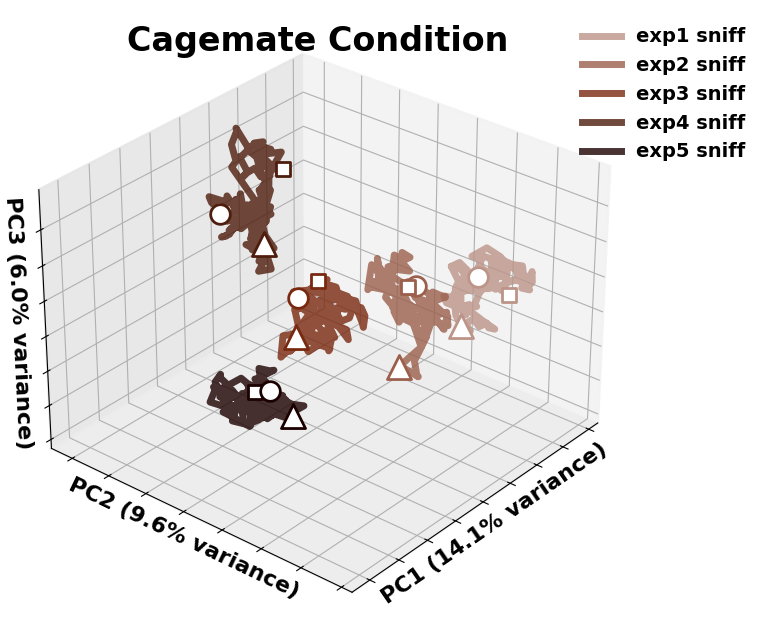

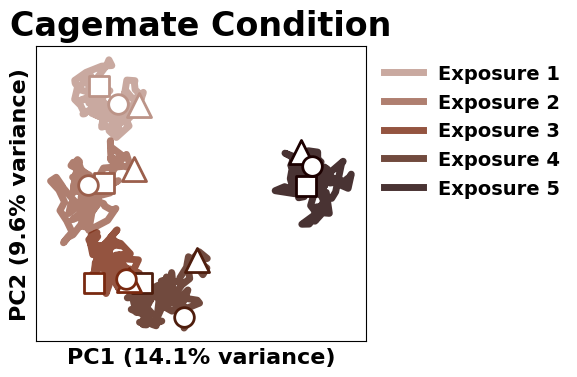

C:\Users\megha\AppData\Local\Temp\ipykernel_27136\3656311523.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


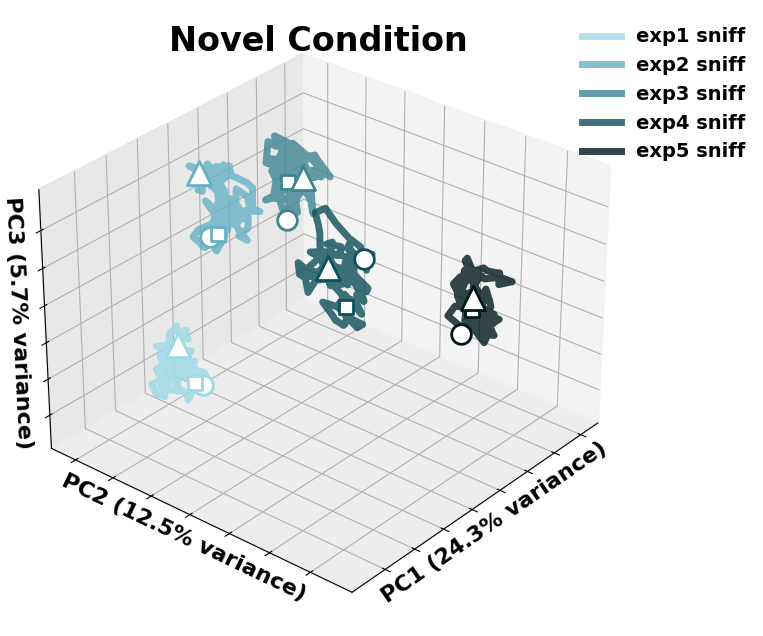

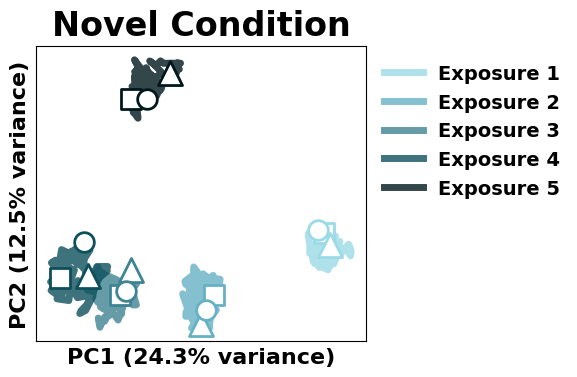

PCA Result with:
Events: exp1 sniff, exp2 sniff, exp3 sniff, exp4 sniff, exp5 sniff
Timebins per event: 120.0
Total neurons: 131
Number of recordings: 9
Number of Pcs needed to explain 90% of variance 58
PCA Result with:
Events: exp1 sniff, exp2 sniff, exp3 sniff, exp4 sniff, exp5 sniff
Timebins per event: 120.0
Total neurons: 130
Number of recordings: 9
Number of Pcs needed to explain 90% of variance 49


In [ ]:
import importlib
importlib.reload(population_analysis)
cagemate_pca_results = population_analysis.avg_trajectories_pca(cagemate_collection, 3, 3, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'],min_neurons=5, plot = False)
novel_pca_results = population_analysis.avg_trajectories_pca(novel_collection, 3, 3, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'],min_neurons=5, plot = False)

cagemate_expsniffcolors = [hex_2_rgb('#bc9488'),
              hex_2_rgb('#9b5f4c'),
              hex_2_rgb('#792910'),
              hex_2_rgb("#4e1d0d"),
              hex_2_rgb("#1C0000")]
novel_expsniffcolors = [hex_2_rgb("#9BDAE7"),
              hex_2_rgb("#66B1C4"),
              hex_2_rgb("#3E8492"),
              hex_2_rgb("#0D4F5B"),
              hex_2_rgb("#00181C")]
plot_pca_results_3d(cagemate_pca_results, "Cagemate Condition", cagemate_expsniffcolors, azim = 40, elev = 30)
plot_pca_results_2d(cagemate_pca_results, "Cagemate Condition", colors = cagemate_expsniffcolors, legend_spot = (1, 1), legend_labels = ['Exposure 1', 'Exposure 2', 'Exposure 3', 'Exposure 4', 'Exposure 5'], save = True)
plot_pca_results_3d(novel_pca_results, "Novel Condition", novel_expsniffcolors, azim = 40, elev = 30)
plot_pca_results_2d(novel_pca_results, "Novel Condition", colors = novel_expsniffcolors, legend_spot = (1, 1), legend_labels = ['Exposure 1', 'Exposure 2', 'Exposure 3', 'Exposure 4', 'Exposure 5'], save = True)
print(cagemate_pca_results)
print(novel_pca_results)


Excluding 33_nov_p1_merged.rec with 1 neurons


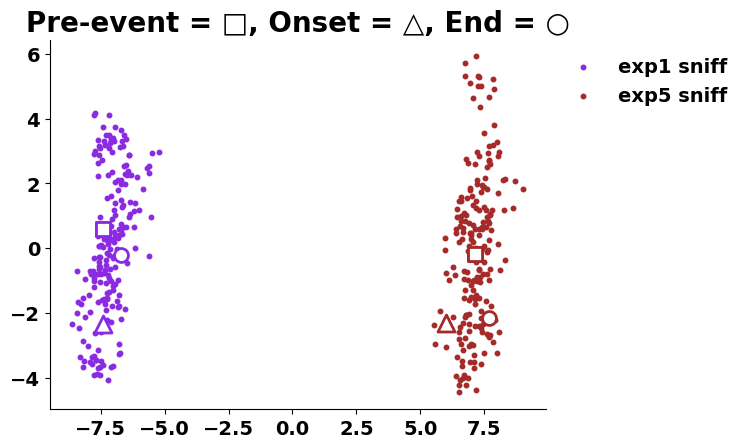

              Recording  Number of Neurons  Number of exp1 sniff events  \
0  41_nov_p1_merged.rec                 25                           32   
1  11_nov_p1_merged.rec                 20                           24   
2  12_nov_p1_merged.rec                 15                           25   
3  44_nov_p1_merged.rec                 14                           31   
4  32_nov_p1_merged.rec                 13                           28   
5  22_nov_p1_merged.rec                 12                           29   
6  13_nov_p1_merged.rec                 11                           15   
7  21_nov_p1_merged.rec                 10                           30   
8  24_nov_p1_merged.rec                 10                            9   

   Number of exp5 sniff events  
0                           21  
1                           25  
2                           19  
3                           28  
4                           25  
5                           27  
6                 

In [26]:
population_analysis.avg_trajectories_pca(novel_collection, 5, 5, events = ['exp1 sniff', 'exp5 sniff'],min_neurons=5)

Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons


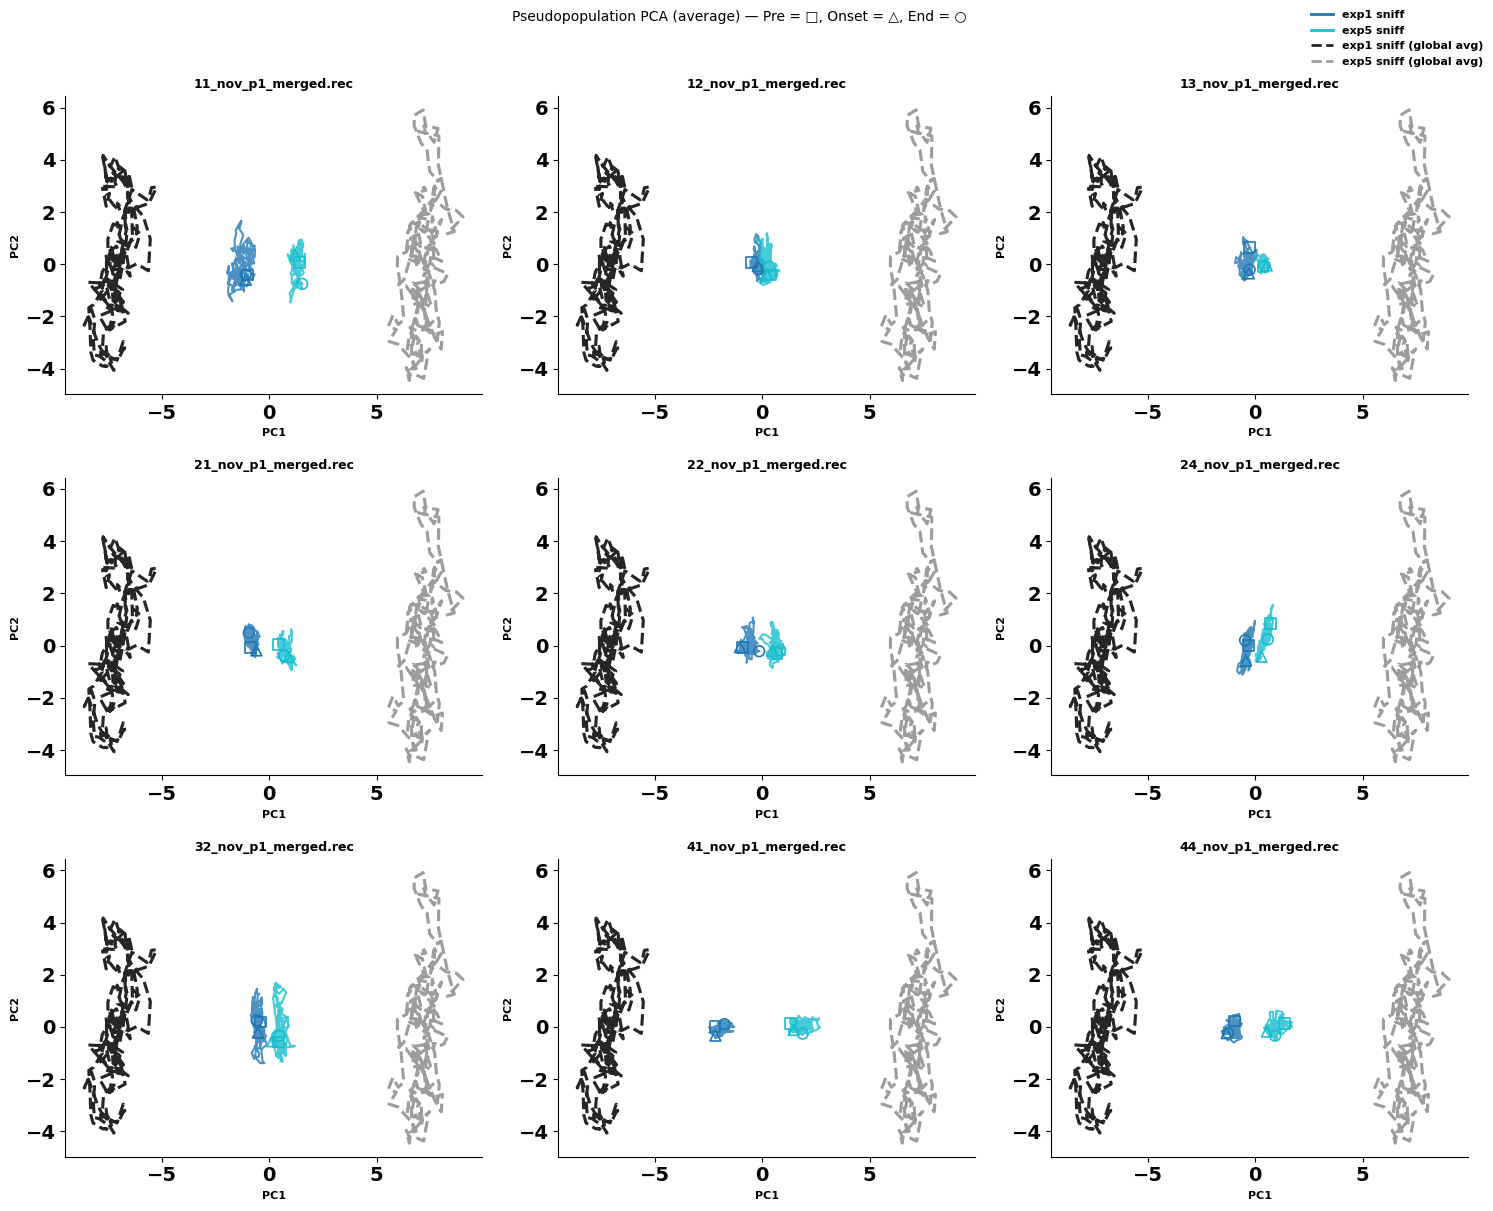

              Recording  Number of Neurons  Number of exp1 sniff events  \
0  41_nov_p1_merged.rec                 25                           32   
1  11_nov_p1_merged.rec                 20                           24   
2  12_nov_p1_merged.rec                 15                           25   
3  44_nov_p1_merged.rec                 14                           31   
4  32_nov_p1_merged.rec                 13                           28   
5  22_nov_p1_merged.rec                 12                           29   
6  13_nov_p1_merged.rec                 11                           15   
7  21_nov_p1_merged.rec                 10                           30   
8  24_nov_p1_merged.rec                 10                            9   

   Number of exp5 sniff events  
0                           21  
1                           25  
2                           19  
3                           28  
4                           25  
5                           27  
6                 

In [27]:
from importlib import reload
reload(population_analysis)
population_analysis.pseudopopulation_pca(novel_collection, 5, 5, events = ['exp1 sniff', 'exp5 sniff'],min_neurons=5, mode='average')

Excluding 33_nov_p1_merged.rec with 1 neurons


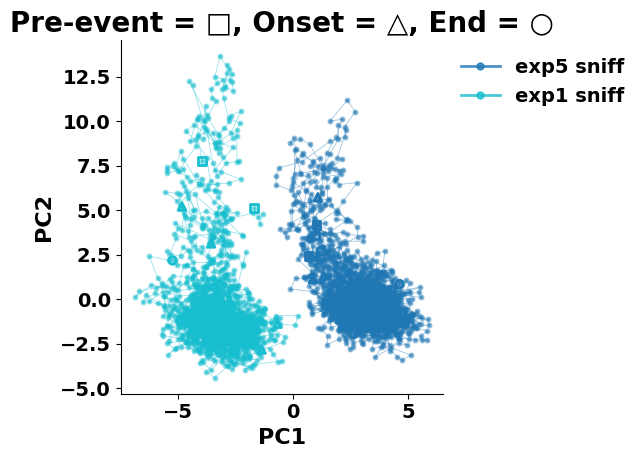

In [28]:
novel_pca_results = population_analysis.trial_trajectories_pca(novel_collection, 5, 5, events = ['exp1 sniff', 'exp5 sniff'],min_neurons=5, plot = True)

# expsniffcolors = [hex_2_rgb('#bc9488'),
#               hex_2_rgb('#9b5f4c'),
#               hex_2_rgb('#792910'),
#               hex_2_rgb('#3c1508'),
#               hex_2_rgb('#15616F')]

# plot_pca_results_3d(novel_pca_results, "Novel Condition", expsniffcolors, azim = 40, elev = 30)
# plot_pca_results_2d(novel_pca_results, "Novel Condition", colors = expsniffcolors, legend_spot = (1, 1), legend_labels = ['Exposure 1', 'Exposure 2', 'Exposure 3', 'Exposure 4', 'Exposure 5'], save = True)
# print(cagemate_pca_results)
# print(novel_pca_results)

Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons


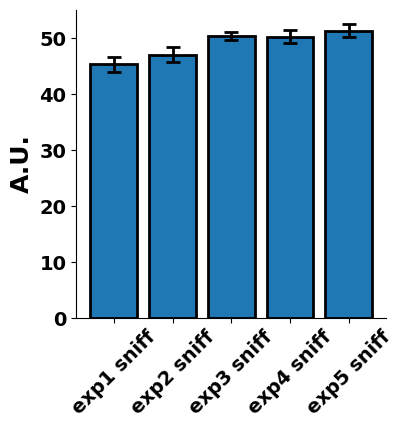

Excluding 33_nov_p1_merged.rec with 1 neurons


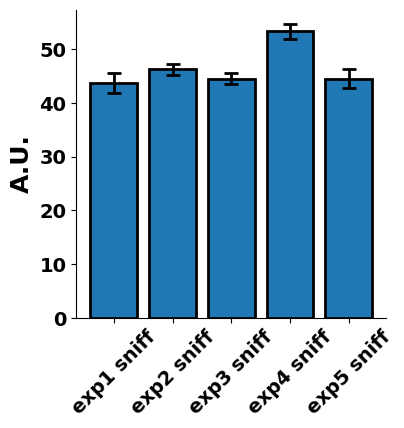

In [20]:
events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff']
alignment_not_scaled = population_analysis.procrustes_alignment(cagemate_collection,
                                         events = events,
                                         pre_window = 2,
                                         event_length = 3,
                                         post_window = 0,
                                         min_neurons = 5)
means = np.mean(np.array(alignment_not_scaled), axis = 0)
sems = sem(np.array(alignment_not_scaled), axis = 0)
plt.figure(figsize= (4,4)) 
x = [0.5,1,1.5,2, 2.5]          
plt.bar(x, means, yerr = sems,
            edgecolor = ['black', 'black', 'black', 'black'],
            capsize = 5, linewidth = 2,
            error_kw={'elinewidth': 2, 'capthick': 2}, 
            width = .4)
plt.xticks(x, labels=events, rotation = 45)
plt.ylabel('A.U.', fontsize = 18)
plt.show()
alignment_novel = population_analysis.procrustes_alignment(novel_collection,
                                         events = events,
                                         pre_window = 2,
                                         event_length = 3,
                                         post_window = 0,
                                         min_neurons = 5)
means = np.mean(np.array(alignment_novel), axis = 0)
sems = sem(np.array(alignment_novel), axis = 0)
plt.figure(figsize= (4,4)) 
x = [0.5,1,1.5,2, 2.5]          
plt.bar(x, means, yerr = sems,
            edgecolor = ['black', 'black', 'black', 'black'],
            capsize = 5, linewidth = 2,
            error_kw={'elinewidth': 2, 'capthick': 2}, 
            width = .4)
plt.xticks(x, labels=events, rotation = 45)
plt.ylabel('A.U.', fontsize = 18)
plt.show()

Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons


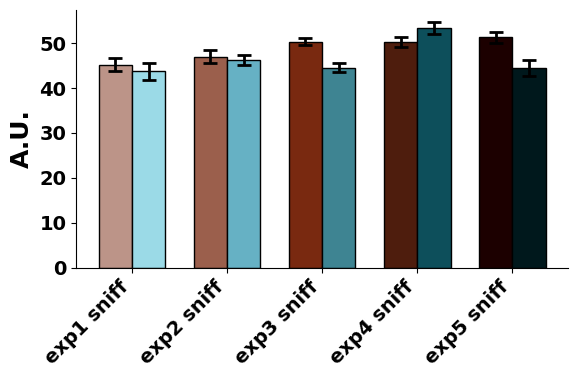

In [21]:
events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff']
cagemate_expsniffcolors = [hex_2_rgb('#bc9488'), hex_2_rgb('#9b5f4c'), hex_2_rgb('#792910'),
                            hex_2_rgb("#4e1d0d"), hex_2_rgb("#1C0000")]                                                                                                                 
novel_expsniffcolors    = [hex_2_rgb("#9BDAE7"), hex_2_rgb("#66B1C4"), hex_2_rgb("#3E8492"),
                            hex_2_rgb("#0D4F5B"), hex_2_rgb("#00181C")]                                                                                                                 
                                                                                                                                                                                    
alignment_not_scaled = population_analysis.procrustes_alignment(cagemate_collection, events=events,
                            pre_window=2, event_length=3, post_window=0, min_neurons=5)
cagemate_means = np.mean(np.array(alignment_not_scaled), axis=0)
cagemate_sems  = sem(np.array(alignment_not_scaled), axis=0)

alignment_novel = population_analysis.procrustes_alignment(novel_collection, events=events,
                            pre_window=2, event_length=3, post_window=0, min_neurons=5)
novel_means = np.mean(np.array(alignment_novel), axis=0)
novel_sems  = sem(np.array(alignment_novel), axis=0)

x = np.arange(len(events))
width = 0.35
bar_kw = dict(edgecolor='black', linewidth=1, capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(len(events)):
    ax.bar(x[i] - width/2, cagemate_means[i], width=width, yerr=cagemate_sems[i],
            color=cagemate_expsniffcolors[i], **bar_kw)
    ax.bar(x[i] + width/2, novel_means[i],    width=width, yerr=novel_sems[i],
            color=novel_expsniffcolors[i],    **bar_kw)

ax.set_xticks(x)
ax.set_xticklabels(events, rotation=45, ha='right')
ax.set_ylabel('A.U.', fontsize=18)
plt.tight_layout()
plt.show()


## Dimensionality

42


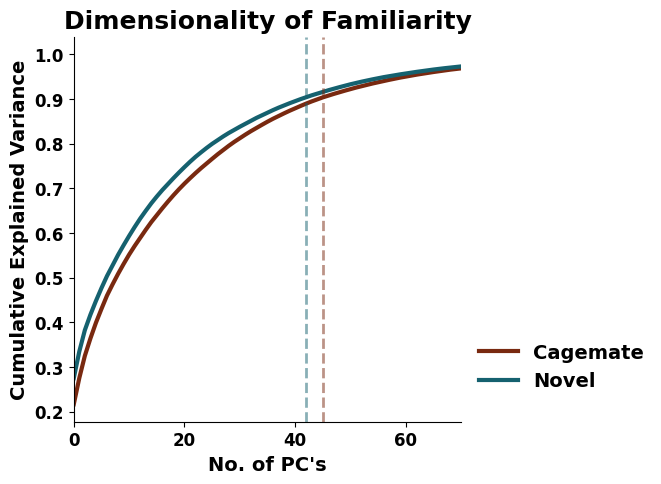

In [39]:
plt.figure(figsize=(5, 5))
plt.plot(cagemate_pca_results.cumulative_variance, label='Cagemate', color = '#792910', linewidth = 3)
plt.plot(novel_pca_results.cumulative_variance, label='Novel', color = '#15616F', linewidth = 3)
threshold_x1 = None
threshold_x2 = None

for i in range(100):
    if cagemate_pca_results.cumulative_variance[i] > .90 and threshold_x1 is None:
        threshold_x1 = i
    if novel_pca_results.cumulative_variance[i] > .90 and threshold_x2 is None:
        threshold_x2 = i
    if threshold_x1 is not None and threshold_x2 is not None:
        break
print(threshold_x2)
# Add vertical dashed lines if thresholds are found
if threshold_x1 is not None:
    plt.axvline(x=threshold_x1, color='#792910', linestyle='--', alpha=0.5, linewidth = 2)
if threshold_x2 is not None:
    plt.axvline(x=threshold_x2, color='#15616F', linestyle='--', alpha=0.5, linewidth = 2)
plt.xlim(0,70)
plt.legend(frameon=False, fontsize = 14, bbox_to_anchor = (1,0.25))
plt.xlabel("No. of PC's", fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.ylabel('Cumulative Explained Variance', fontsize = 14)
plt.title("Dimensionality of Familiarity", fontsize = 18)
plt.show()


Paired t-test on participation ratio:
  n (matched subjects)   : 9
  mean PR_A              : 21.978 ± 0.358
  mean PR_B              : 11.400 ± 0.266
  mean difference (A-B)  : 10.579
  t = 38.022,  p = 0.0000  ***


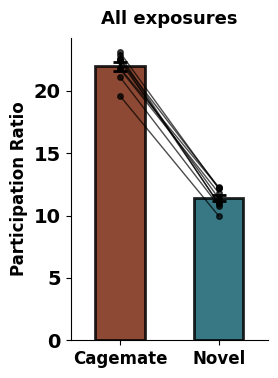

In [11]:
def paired_pr_test(df_a, df_b):
    from scipy.stats import ttest_rel

    a = df_a[['participation_ratio']].copy()
    b = df_b[['participation_ratio']].copy()

    # extract subject ID from index (everything before first underscore)
    a['subject'] = a.index.str.split('_').str[0]
    b['subject'] = b.index.str.split('_').str[0]

    merged = pd.merge(
        a.reset_index(), b.reset_index(),
        on='subject', how='inner',
        suffixes=('_A', '_B')
    )

    dropped_a = set(a['subject']) - set(merged['subject'])
    dropped_b = set(b['subject']) - set(merged['subject'])
    if dropped_a:
        print(f"Warning: subjects in A with no match: {dropped_a}")
    if dropped_b:
        print(f"Warning: subjects in B with no match: {dropped_b}")

    merged['difference'] = merged['participation_ratio_A'] - merged['participation_ratio_B']
    t, p = ttest_rel(merged['participation_ratio_A'], merged['participation_ratio_B'])

    def stars(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return "n.s."

    print(f"\nPaired t-test on participation ratio:")
    print(f"  n (matched subjects)   : {len(merged)}")
    print(f"  mean PR_A              : {merged['participation_ratio_A'].mean():.3f} ± {merged['participation_ratio_A'].sem():.3f}")
    print(f"  mean PR_B              : {merged['participation_ratio_B'].mean():.3f} ± {merged['participation_ratio_B'].sem():.3f}")
    print(f"  mean difference (A-B)  : {merged['difference'].mean():.3f}")
    print(f"  t = {t:.3f},  p = {p:.4f}  {stars(p)}")

    return merged, t, p


def plot_pr_comparison(df_a, df_b, tick_labels, colors,
                       ylabel='Participation Ratio', title='Dimensionality comparison'):

    a = df_a[['participation_ratio']].copy()
    b = df_b[['participation_ratio']].copy()
    a['subject'] = a.index.str.split('_').str[0]
    b['subject'] = b.index.str.split('_').str[0]

    merged = pd.merge(
        a.reset_index(), b.reset_index(),
        on='subject', how='inner',
        suffixes=('_A', '_B')
    )

    means = [merged['participation_ratio_A'].mean(), merged['participation_ratio_B'].mean()]
    sems  = [merged['participation_ratio_A'].sem(),  merged['participation_ratio_B'].sem()]

    fig, ax = plt.subplots(figsize=(3, 4))

    ax.bar([0, 1], means, yerr=sems, color=colors, width=0.5,
           capsize=5, error_kw={'elinewidth': 2, 'capthick': 2},
           alpha=0.85, zorder=2, linewidth = 2, edgecolor = 'black')

    for _, row in merged.iterrows():
        ax.plot([0, 1],
                [row['participation_ratio_A'], row['participation_ratio_B']],
                color='black', linewidth=1, alpha=0.7,
                marker='o', markersize=4, zorder=3)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(tick_labels, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlim(-0.5, 1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
    
pr_cagemate = population_analysis.participation_ratio(cagemate_collection, 3, 3, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'],min_neurons=5, LOO = True)
pr_novel = population_analysis.participation_ratio(novel_collection, 3, 3, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'],min_neurons=5, LOO = True)
merged_pr, t_stat, p_value = paired_pr_test(pr_cagemate, pr_novel)
plot_pr_comparison(pr_cagemate, pr_novel, tick_labels=['Cagemate', 'Novel'], colors=['#792910', '#15616F'], title='All exposures')


Paired t-test on participation ratio:
  n (matched subjects)   : 9
  mean PR_A              : 23.524 ± 0.390
  mean PR_B              : 9.803 ± 0.252
  mean difference (A-B)  : 13.720
  t = 35.843,  p = 0.0000  ***


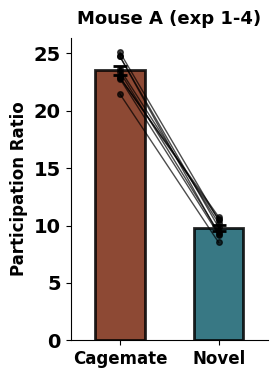

In [204]:
pr_cagemate = population_analysis.participation_ratio(cagemate_collection, 3, 3, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff'],min_neurons=5, LOO = True)
pr_novel = population_analysis.participation_ratio(novel_collection, 3, 3, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff'],min_neurons=5, LOO = True)
merged_pr, t_stat, p_value = paired_pr_test(pr_cagemate, pr_novel)
plot_pr_comparison(pr_cagemate, pr_novel, tick_labels=['Cagemate', 'Novel'], colors=['#792910', '#15616F'], title='Mouse A (exp 1-4)')


Paired t-test on participation ratio:
  n (matched subjects)   : 9
  mean PR_A              : 10.667 ± 0.240
  mean PR_B              : 5.727 ± 0.170
  mean difference (A-B)  : 4.940
  t = 19.413,  p = 0.0000  ***


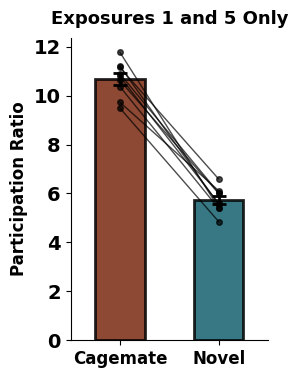

In [37]:
pr_cagemate = population_analysis.participation_ratio(cagemate_collection, 3, 3, events = ['exp1 sniff', 'exp5 sniff'],min_neurons=5, LOO = True)
pr_novel = population_analysis.participation_ratio(novel_collection, 3, 3, events = ['exp1 sniff', 'exp5 sniff'],min_neurons=5, LOO = True)
merged_pr, t_stat, p_value = paired_pr_test(pr_cagemate, pr_novel)
plot_pr_comparison(pr_cagemate, pr_novel, tick_labels=['Cagemate', 'Novel'], colors=['#792910', '#15616F'], title='Exposures 1 and 5 Only')


Paired t-test on participation ratio:
  n (matched subjects)   : 9
  mean PR_A              : 13.923 ± 0.241
  mean PR_B              : 10.089 ± 0.209
  mean difference (A-B)  : 3.834
  t = 13.318,  p = 0.0000  ***


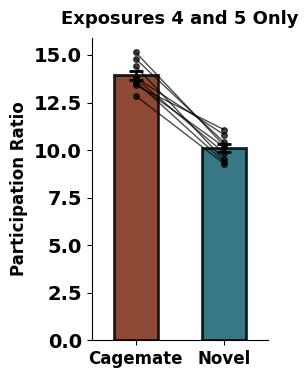

In [36]:
pr_cagemate = population_analysis.participation_ratio(cagemate_collection, 3, 3, events = ['exp4 sniff', 'exp5 sniff'],min_neurons=5, LOO = True)
pr_novel = population_analysis.participation_ratio(novel_collection, 3, 3, events = ['exp4 sniff', 'exp5 sniff'],min_neurons=5, LOO = True)
merged_pr, t_stat, p_value = paired_pr_test(pr_cagemate, pr_novel)
plot_pr_comparison(pr_cagemate, pr_novel, tick_labels=['Cagemate', 'Novel'], colors=['#792910', '#15616F'], title='Exposures 4 and 5 Only')


Paired t-test on participation ratio:
  n (matched subjects)   : 9
  mean PR_A              : 13.251 ± 0.256
  mean PR_B              : 5.829 ± 0.142
  mean difference (A-B)  : 7.422
  t = 33.230,  p = 0.0000  ***


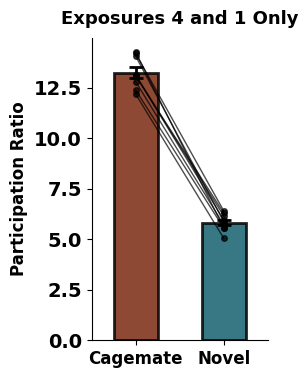

In [13]:
pr_cagemate = population_analysis.participation_ratio(cagemate_collection, 3, 3, events = ['exp4 sniff', 'exp1 sniff'],min_neurons=5, LOO = True)
pr_novel = population_analysis.participation_ratio(novel_collection, 3, 3, events = ['exp4 sniff', 'exp1 sniff'],min_neurons=5, LOO = True)
merged_pr, t_stat, p_value = paired_pr_test(pr_cagemate, pr_novel)
plot_pr_comparison(pr_cagemate, pr_novel, tick_labels=['Cagemate', 'Novel'], colors=['#792910', '#15616F'], title='Exposures 4 and 1 Only')


Paired t-test on participation ratio:
  n (matched subjects)   : 9
  mean PR_A              : 17.185 ± 0.234
  mean PR_B              : 19.064 ± 0.233
  mean difference (A-B)  : -1.879
  t = -7.811,  p = 0.0001  ***


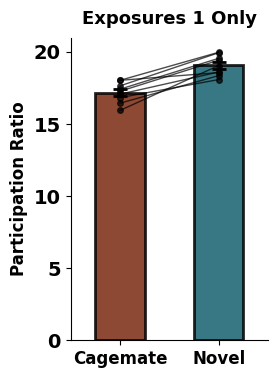

In [202]:
pr_cagemate = population_analysis.participation_ratio(cagemate_collection, 3, 3, events = ['exp1 sniff'],min_neurons=5, LOO = True)
pr_novel = population_analysis.participation_ratio(novel_collection, 3, 3, events = ['exp1 sniff'],min_neurons=5, LOO = True)
merged_pr, t_stat, p_value = paired_pr_test(pr_cagemate, pr_novel)
plot_pr_comparison(pr_cagemate, pr_novel, tick_labels=['Cagemate', 'Novel'], colors=['#792910', '#15616F'], title='Exposures 1 Only')


Paired t-test on participation ratio:
  n (matched subjects)   : 9
  mean PR_A              : 18.355 ± 0.191
  mean PR_B              : 18.288 ± 0.171
  mean difference (A-B)  : 0.067
  t = 0.405,  p = 0.6964  n.s.


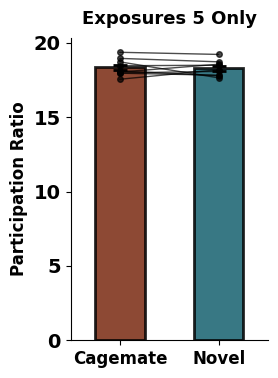

In [203]:
pr_cagemate = population_analysis.participation_ratio(cagemate_collection, 3, 3, events = ['exp5 sniff'],min_neurons=5, LOO = True)
pr_novel = population_analysis.participation_ratio(novel_collection, 3, 3, events = ['exp5 sniff'],min_neurons=5, LOO = True)
merged_pr, t_stat, p_value = paired_pr_test(pr_cagemate, pr_novel)
plot_pr_comparison(pr_cagemate, pr_novel, tick_labels=['Cagemate', 'Novel'], colors=['#792910', '#15616F'], title='Exposures 5 Only')

In [34]:
pre_window = 3
event_length = 5
cagemate_pca_results = population_analysis.avg_trajectories_pca(cagemate_collection, event_length=event_length, pre_window = pre_window, events = ['exp4 sniff', 'exp5 sniff'],min_neurons=5, plot = False)
novel_pca_results = population_analysis.avg_trajectories_pca(novel_collection, event_length=event_length, pre_window = pre_window, events = ['exp4 sniff', 'exp5 sniff'],min_neurons=5, plot = False)
plot_pca_results_2d(cagemate_pca_results, "Cagemate Condition", colors = [expsniffcolors[3],expsniffcolors[4]], legend_spot = (0.75, 1))
plot_pca_results_2d(novel_pca_results, "Novel Condition", colors = [expsniffcolors[3],expsniffcolors[4]], legend_spot = (0.75, 1))
plt.figure(figsize=(5, 5))
plt.plot(cagemate_pca_results.cumulative_variance, label='Cagemate', color = '#CDBE8A', linewidth = 3)
plt.plot(novel_pca_results.cumulative_variance, label='Novel', color = '#DF8C8C', linewidth = 3)
threshold_x1 = None
threshold_x2 = None

for i in range(35):
    if cagemate_pca_results.cumulative_variance[i] > .90 and threshold_x1 is None:
        threshold_x1 = i
    if novel_pca_results.cumulative_variance[i] > .90 and threshold_x2 is None:
        threshold_x2 = i
    if threshold_x1 is not None and threshold_x2 is not None:
        break

# Add vertical dashed lines if thresholds are found
if threshold_x1 is not None:
    plt.axvline(x=threshold_x1, color='#CDBE8A', linestyle='--', alpha=0.5, linewidth = 2)
if threshold_x2 is not None:
    plt.axvline(x=threshold_x2, color='#DF8C8C', linestyle='--', alpha=0.5, linewidth = 2)
plt.xlim(0,40)
plt.legend(frameon=False, fontsize = 14, bbox_to_anchor = (1,0.25))
plt.xlabel("No. of PC's", fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.ylabel('Cumulative Explained Variance', fontsize = 14)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title("Dimensionality of Familiarity", fontsize = 18)
plt.show()

Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons


NameError: name 'expsniffcolors' is not defined

In [41]:
novel_pcs = []
cagemate_pcs = []
events = ['exp1 sniff', 'exp5 sniff']
for recording in cagemate_collection.recordings:
    for event in events:
        try:
            rec_pca_result = population_analysis.avg_trajectories_pca(recording, event_length =5, pre_window=5, events=events, min_neurons=5, plot = False)
            cagemate_pcs.append(np.where(rec_pca_result.cumulative_variance > .90)[0][0])
            
        except AttributeError:
            pass
for recording in novel_collection.recordings:
    for event in events:
        try:
            rec_pca_result = population_analysis.avg_trajectories_pca(recording, event_length =5, pre_window=5, events=events, min_neurons=5, plot = False)
            novel_pcs.append(np.where(rec_pca_result.cumulative_variance > .90)[0][0])
            
        except AttributeError:
            pass
print('Novel', np.mean(novel_pcs))
print('Cagemate', np.mean(cagemate_pcs))

Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Novel 7.666666666666667
Cagemate 9.444444444444445


Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons


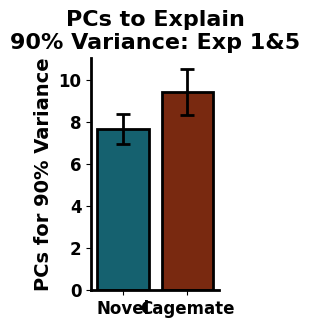

In [42]:
novel_pcs = []
cagemate_pcs = []
events = ['exp1 sniff', 'exp5 sniff']

for recording in cagemate_collection.recordings:
    try:
        rec_pca_result = population_analysis.avg_trajectories_pca(recording, event_length=5, pre_window=5, events=events, min_neurons=5, plot=False)
        cagemate_pcs.append(np.where(rec_pca_result.cumulative_variance > .90)[0][0])
    except AttributeError:
        pass

for recording in novel_collection.recordings:
    try:
        rec_pca_result = population_analysis.avg_trajectories_pca(recording, event_length=5, pre_window=5, events=events, min_neurons=5, plot=False)
        novel_pcs.append(np.where(rec_pca_result.cumulative_variance > .90)[0][0])
    except AttributeError:
        pass

# plot
fig, ax = plt.subplots(figsize=(2.3, 3.5))
means = [np.mean(novel_pcs), np.mean(cagemate_pcs)]
sems = [stats.sem(novel_pcs), stats.sem(cagemate_pcs)]

ax.bar(['Novel', 'Cagemate'], means, yerr=sems, color=[hex_2_rgb('#15616F'), hex_2_rgb('#792910')],
       capsize=5, linewidth=2, error_kw={'elinewidth': 2, 'capthick': 2})
ax.set_ylabel('PCs for 90% Variance', fontsize=14)
ax.set_title('PCs to Explain\n90% Variance: Exp 1&5', fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

In [43]:
novel_pcs = []
cagemate_pcs = []
events = ['exp1 sniff', 'exp5 sniff']
for recording in cagemate_collection.recordings:
    for event in events:
        try:
            rec_pca_result = population_analysis.avg_trajectories_pca(recording, event_length =5, pre_window=5, events=[event], min_neurons=5, plot = False)
            cagemate_pcs.append(np.where(rec_pca_result.cumulative_variance > .90)[0][0])
            
        except AttributeError:
            pass
for recording in novel_collection.recordings:
    for event in events:
        try:
            rec_pca_result = population_analysis.avg_trajectories_pca(recording, event_length =5, pre_window=5, events=[event], min_neurons=5, plot = False)
            novel_pcs.append(np.where(rec_pca_result.cumulative_variance > .90)[0][0])
            
        except AttributeError:
            pass
print('Novel', np.mean(novel_pcs))
print('Cagemate', np.mean(cagemate_pcs))

Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Novel 9.722222222222221
Cagemate 9.833333333333334


Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons


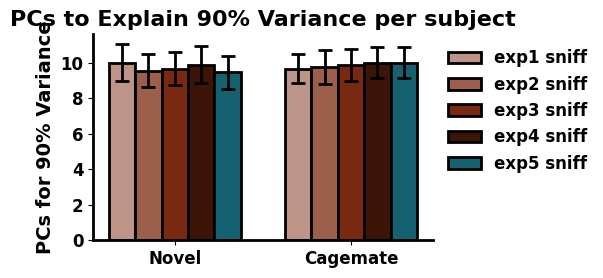

In [44]:
novel_pcs = {f'exp{i} sniff': [] for i in range(1, 6)}
cagemate_pcs = {f'exp{i} sniff': [] for i in range(1, 6)}

events = [f'exp{i} sniff' for i in range(1, 6)]

for recording in cagemate_collection.recordings:
    for event in events:
        try:
            rec_pca_result = population_analysis.avg_trajectories_pca(recording, event_length=5, pre_window=5, events=[event], min_neurons=5, plot=False)
            cagemate_pcs[event].append(np.where(rec_pca_result.cumulative_variance > .90)[0][0])
        except AttributeError:
            pass

for recording in novel_collection.recordings:
    for event in events:
        try:
            rec_pca_result = population_analysis.avg_trajectories_pca(recording, event_length=5, pre_window=5, events=[event], min_neurons=5, plot=False)
            novel_pcs[event].append(np.where(rec_pca_result.cumulative_variance > .90)[0][0])
        except AttributeError:
            pass

expsniffcolors = [hex_2_rgb('#bc9488'),
              hex_2_rgb('#9b5f4c'),
              hex_2_rgb('#792910'),
              hex_2_rgb('#3c1508'),
              hex_2_rgb('#15616F')]

x = np.arange(2)  # Novel, Cagemate
width = 0.15
groups = {'Novel': novel_pcs, 'Cagemate': cagemate_pcs}
group_data = [novel_pcs, cagemate_pcs]

fig, ax = plt.subplots(figsize=(6, 3))

for i, event in enumerate(events):
    means = [np.mean(group[event]) for group in group_data]
    sems = [stats.sem(group[event]) for group in group_data]
    offset = (i - 2) * width
    ax.bar(x + offset, means, width, yerr=sems, label=event,
           color=expsniffcolors[i], capsize=5, linewidth=2,
           error_kw={'elinewidth': 2, 'capthick': 2})

ax.set_xticks(x)
ax.set_xticklabels(['Novel', 'Cagemate'], fontsize=14)
ax.set_ylabel('PCs for 90% Variance', fontsize=14)
ax.set_title('PCs to Explain 90% Variance per subject', fontsize=16)
legend_handles = [Patch(facecolor=expsniffcolors[i], label=event) for i, event in enumerate(events)]
ax.legend(handles=legend_handles, frameon=False, fontsize=12, bbox_to_anchor=(1, 1))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

## Trajectory Distances

In [47]:
from matplotlib.colors import LinearSegmentedColormap
def create_comparison_matrix(df):
    # Get unique experiments
    experiments = sorted(list(set([exp for col in df.columns for exp in col.split('_')])))
    n = len(experiments)
    
    # Create empty matrix
    matrix = np.zeros((n, n))
    
    # Fill matrix
    for i, exp1 in enumerate(experiments):
        for j, exp2 in enumerate(experiments):
            if i == j:
                matrix[i,j] = 1
            else:
                col1 = f"{exp1}_{exp2}"
                col2 = f"{exp2}_{exp1}"
                if col1 in df.columns:
                    matrix[i,j] = df[col1].mean()
                elif col2 in df.columns:
                    matrix[i,j] = df[col2].mean()
    experiments = [experiment.replace(' sniff', '') for experiment in experiments]

    return pd.DataFrame(matrix, index=experiments, columns=experiments)

def plot_comparison_heatmap(df, title, color, diagonal_color, vmin):
    # Create comparison matrix
    matrix = create_comparison_matrix(df)
    
    # Create figure
    plt.figure(figsize=(5, 4))
    n_bins = 100  # Number of color gradients
    cmap = LinearSegmentedColormap.from_list('custom', color, N=n_bins)
    # Create heatmap
    sns.heatmap(matrix, 
                annot=True, 
                cmap=cmap,
                fmt='.0f',
                square=True,
                cbar_kws={'label': 'AU Distance'},
                vmin = vmin)
    for i in range(len(matrix)):
        plt.plot(i + 0.5, i + 0.5, 'o', color=diagonal_color, markersize=25, zorder =100)
    
    plt.title(title, fontsize = 16)
    plt.tight_layout()
    return plt



In [32]:
novel_geo_dist = population_analysis.average_trajectory_distances(novel_collection, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'], percent_var = 90, event_length=3, pre_window=1, post_window=0, min_neurons = 5, weighted= True)
novel_geo_dist
avg_vals_df = novel_geo_dist.mean()
avg_vals_df

Excluding 33_nov_p1_merged.rec with 1 neurons


exp1 sniff_exp2 sniff    52.119018
exp1 sniff_exp3 sniff    73.385051
exp1 sniff_exp4 sniff    85.578938
exp1 sniff_exp5 sniff    68.569095
exp2 sniff_exp3 sniff    46.610838
exp2 sniff_exp4 sniff    55.653944
exp2 sniff_exp5 sniff    55.542830
exp3 sniff_exp4 sniff    39.198456
exp3 sniff_exp5 sniff    51.823102
exp4 sniff_exp5 sniff    56.209424
dtype: float64

In [33]:
avg_vals_df

exp1 sniff_exp2 sniff    52.119018
exp1 sniff_exp3 sniff    73.385051
exp1 sniff_exp4 sniff    85.578938
exp1 sniff_exp5 sniff    68.569095
exp2 sniff_exp3 sniff    46.610838
exp2 sniff_exp4 sniff    55.653944
exp2 sniff_exp5 sniff    55.542830
exp3 sniff_exp4 sniff    39.198456
exp3 sniff_exp5 sniff    51.823102
exp4 sniff_exp5 sniff    56.209424
dtype: float64

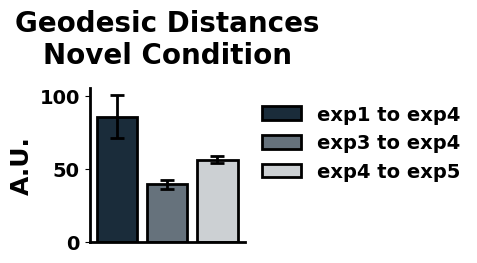

In [34]:
avg_vals = np.array(avg_vals_df.values.tolist())
avg_vals = avg_vals[[2, 7, 9]]
avg_sems = novel_geo_dist.sem()

avg_sems = np.array(avg_sems.values.tolist())
avg_sems = avg_sems[[2,7,9]]

color_id_dict = {'exp1 to exp4': hex_2_rgb('#1a2c3a'),  
                'exp3 to exp4': hex_2_rgb('#66727c'),
                'exp4 to exp5': hex_2_rgb('#ccd0d3')
                }
hatches = ['','','']  
plt.figure(figsize= (2,2))           
plt.bar(color_id_dict.keys(), avg_vals, yerr = avg_sems,
            color = color_id_dict.values(), hatch = hatches,
            edgecolor = ['black', 'black', 'black'],
            capsize = 5, linewidth = 2, error_kw={'elinewidth': 2, 'capthick': 2})
plt.xticks([],rotation=45)
legend_handles = [Patch(facecolor=color, label=label) for label, color in color_id_dict.items()]
plt.legend(handles=legend_handles,
           bbox_to_anchor=(1,1),
           frameon= False, fontsize = 14)
plt.ylabel('A.U.', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
#plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(50))
#plt.ylim(0,300)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
hatches = ['//','','','', '']
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Geodesic Distances\nNovel Condition', fontsize = 20, y =1.1)
plt.show()

In [35]:
avg_vals = np.array(avg_vals_df.values.tolist())
#avg_vals = avg_vals[[2, 3, 9]]
avg_sems = geo_dist.sem()

avg_sems = np.array(avg_sems.values.tolist())
#avg_sems = avg_sems[[2,3,9]]
color_id_dict = {'exp1 to exp4': hex_2_rgb('#1a2c3a'),  
                'exp1 to exp5': hex_2_rgb('#66727c'),
                'exp4 to exp5': hex_2_rgb('#ccd0d3')
                }
all_color_id_dict = {'exp1 to exp2': hex_2_rgb('#1a2c3a'),
                'exp1 to exp3': hex_2_rgb('#66727c'),
                'exp1 to exp4': hex_2_rgb('#9b5f4c'),
                'exp1 to exp5': hex_2_rgb('#792910'),
                'exp2 to exp3': hex_2_rgb('#3c1508'),
                'exp2 to exp4': hex_2_rgb('#15616F'),
                'exp2 to exp5': hex_2_rgb('#1a2c3a'),
                'exp3 to exp4': hex_2_rgb('#66727c'),
                'exp3 to exp5': hex_2_rgb('#9b5f4c'),
                'exp4 to exp5': hex_2_rgb('#792910')
                }
#hatches = ['','','']  
plt.figure(figsize= (5,5))           
plt.bar(all_color_id_dict.keys(), avg_vals, yerr = avg_sems,
            color = all_color_id_dict.values(),
            #edgecolor = ['black', 'black', 'black'],
            capsize = 5, linewidth = 2, error_kw={'elinewidth': 2, 'capthick': 2})
plt.xticks([],rotation=45)
legend_handles = [Patch(facecolor=color, label=label) for label, color in all_color_id_dict.items()]
plt.legend(handles=legend_handles,
           bbox_to_anchor=(1,1),
           frameon= False, fontsize = 14)
plt.ylabel('A.U.', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
#plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(700))
#plt.ylim(0,300)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
hatches = ['//','','','', '']
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Geodesic Distances\nCagemate Condition', fontsize = 20, y =1.1)
plt.show()

NameError: name 'geo_dist' is not defined

In [36]:
import itertools
from statsmodels.stats.multitest import multipletests

labels = ['1_2', '1_3', '1_4', '1_5', '2_3', '2_4', '2_5', '3_4', '3_5', '4_5']
col_indices = list(range(10))

comparisons = list(itertools.combinations(range(10), 2))

t_stats, p_values, comp_labels = [], [], []

for i, j in comparisons:
    t, p = stats.ttest_rel(novel_geo_dist.values[:, i], novel_geo_dist.values[:, j])
    t_stats.append(t)
    p_values.append(p)
    comp_labels.append(f'{labels[i]} vs {labels[j]}')

reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')

stats_df = pd.DataFrame({
    'Comparison': comp_labels,
    't_statistic': t_stats,
    'p_value': p_values,
    'p_adjusted': p_adjusted,
    'significant': reject
})
stats_df

,Comparison,t_statistic,p_value,p_adjusted,significant
0,1_2 vs 1_3,-3.036205,0.016156,0.107305,False
1,1_2 vs 1_4,-3.827597,0.005035,0.106441,False
2,1_2 vs 1_5,-1.357612,0.211640,0.366300,False
3,1_2 vs 2_3,0.708097,0.498993,0.623741,False
4,1_2 vs 2_4,-0.384855,0.710375,0.799171,False
5,1_2 vs 2_5,-0.353936,0.732534,0.804001,False
6,1_2 vs 3_4,1.437375,0.188549,0.339388,False
7,1_2 vs 3_5,0.032183,0.975115,0.989378,False
8,1_2 vs 4_5,-0.392690,0.704804,0.799171,False
9,1_3 vs 1_4,-3.130805,0.013998,0.107305,False


In [37]:
import itertools

labels = ['1_2', '1_3', '1_4', '1_5', '2_3', '2_4', '2_5', '3_4', '3_5', '4_5']
col_indices = {label: i for i, label in enumerate(labels)}

# define the two groups
with_5 = ['1_5', '2_5', '3_5', '4_5', '1_2', '1_3', '1_4']
without_5 = [ '2_3', '2_4', '3_4']

comparisons = list(itertools.product(with_5, without_5))

t_stats, p_values, comp_labels = [], [], []

for label_5, label_no5 in comparisons:
    i = col_indices[label_5]
    j = col_indices[label_no5]
    t, p = stats.ttest_rel(novel_geo_dist.values[:, i], novel_geo_dist.values[:, j])
    t_stats.append(t)
    p_values.append(p)
    comp_labels.append(f'{label_5} vs {label_no5}')

reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')

stats_df = pd.DataFrame({
    'Comparison': comp_labels,
    't_statistic': t_stats,
    'p_value': p_values,
    'p_adjusted': p_adjusted,
    'significant': reject
})
stats_df

,Comparison,t_statistic,p_value,p_adjusted,significant
0,1_5 vs 2_3,1.544557,0.161033,0.281808,False
1,1_5 vs 2_4,0.979338,0.356097,0.467377,False
2,1_5 vs 3_4,1.740581,0.119938,0.228973,False
3,2_5 vs 2_3,1.277629,0.237206,0.355809,False
4,2_5 vs 2_4,-0.013735,0.989378,0.989378,False
5,2_5 vs 3_4,1.941162,0.088188,0.205772,False
6,3_5 vs 2_3,1.129208,0.291530,0.408142,False
7,3_5 vs 2_4,-0.543629,0.601513,0.701765,False
8,3_5 vs 3_4,2.050730,0.074424,0.195362,False
9,4_5 vs 2_3,2.417037,0.042044,0.126132,False


In [39]:
geo_dist = population_analysis.average_trajectory_distances(cagemate_collection, percent_var = 90, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'], event_length=3, pre_window=1, post_window=0,  min_neurons = 5)
avg_vals_df = geo_dist.mean()
avg_vals = avg_vals_df.values.tolist()
avg_sems = geo_dist.sem()
avg_sems = avg_sems.values.tolist()
geo_dist

Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons


,exp1 sniff_exp2 sniff,exp1 sniff_exp3 sniff,exp1 sniff_exp4 sniff,exp1 sniff_exp5 sniff,exp2 sniff_exp3 sniff,exp2 sniff_exp4 sniff,exp2 sniff_exp5 sniff,exp3 sniff_exp4 sniff,exp3 sniff_exp5 sniff,exp4 sniff_exp5 sniff
11_cage_p1_merged.rec,30.907499,34.711609,33.300836,58.902569,38.487438,33.817032,55.169751,37.473856,70.172202,58.111324
12_cage_p1_merged.rec,56.628641,44.033503,49.693597,42.486551,52.142235,47.862360,62.165450,41.854695,45.490656,49.955267
13_cage_p1_merged.rec,31.526955,32.762534,29.376634,51.583154,32.746238,36.298264,49.432179,38.114555,49.936772,53.119585
21_cage_p1_merged.rec,66.737207,70.064020,65.586297,58.596478,58.694076,72.903468,90.748454,59.268363,85.788679,68.193897
22_cage_p1_merged.rec,25.340144,36.942956,61.633065,50.150245,32.619119,58.390931,46.891071,43.958457,42.844065,42.991575
24_cage_p1_merged.rec,45.535693,52.898428,46.503655,42.787326,29.902116,30.888427,47.526096,25.967668,48.104725,45.551256
32_cage_p1_merged.rec,33.027129,52.437943,38.670122,39.553677,51.073197,33.488644,34.224128,41.863548,47.638775,30.905235
41_cage_p1_merged.rec,27.519187,33.913650,49.126560,64.184163,38.590951,55.884626,72.155203,49.056440,52.576065,36.548067
44_cage_p1_merged.rec,30.253673,41.660160,48.271674,55.507108,39.700603,40.862257,55.016903,53.744677,64.798549,54.256911


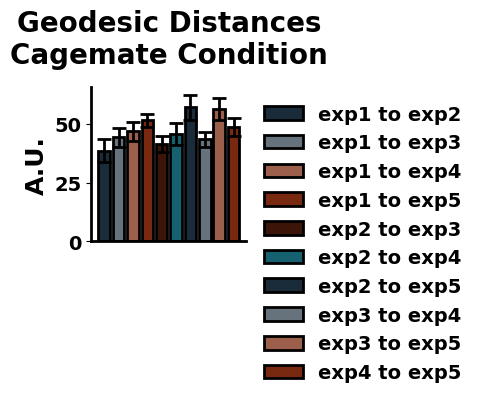

In [40]:
avg_vals = np.array(avg_vals_df.values.tolist())
#avg_vals = avg_vals[[2, 3, 9]]
avg_sems = geo_dist.sem()

avg_sems = np.array(avg_sems.values.tolist())
#avg_sems = avg_sems[[2,3,9]]
color_id_dict = {'exp1 to exp4': hex_2_rgb('#1a2c3a'),  
                'exp1 to exp5': hex_2_rgb('#66727c'),
                'exp4 to exp5': hex_2_rgb('#ccd0d3')
                }
all_color_id_dict = {'exp1 to exp2': hex_2_rgb('#1a2c3a'),
                'exp1 to exp3': hex_2_rgb('#66727c'),
                'exp1 to exp4': hex_2_rgb('#9b5f4c'),
                'exp1 to exp5': hex_2_rgb('#792910'),
                'exp2 to exp3': hex_2_rgb('#3c1508'),
                'exp2 to exp4': hex_2_rgb('#15616F'),
                'exp2 to exp5': hex_2_rgb('#1a2c3a'),
                'exp3 to exp4': hex_2_rgb('#66727c'),
                'exp3 to exp5': hex_2_rgb('#9b5f4c'),
                'exp4 to exp5': hex_2_rgb('#792910')
                }
#hatches = ['','','']  
plt.figure(figsize= (2,2))           
plt.bar(all_color_id_dict.keys(), avg_vals, yerr = avg_sems,
            color = all_color_id_dict.values(),
            #edgecolor = ['black', 'black', 'black'],
            capsize = 5, linewidth = 2, error_kw={'elinewidth': 2, 'capthick': 2})
plt.xticks([],rotation=45)
legend_handles = [Patch(facecolor=color, label=label) for label, color in all_color_id_dict.items()]
plt.legend(handles=legend_handles,
           bbox_to_anchor=(1,1),
           frameon= False, fontsize = 14)
plt.ylabel('A.U.', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
#plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(700))
#plt.ylim(0,300)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
hatches = ['//','','','', '']
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Geodesic Distances\nCagemate Condition', fontsize = 20, y =1.1)
plt.show()

In [41]:
geo_dist

,exp1 sniff_exp2 sniff,exp1 sniff_exp3 sniff,exp1 sniff_exp4 sniff,exp1 sniff_exp5 sniff,exp2 sniff_exp3 sniff,exp2 sniff_exp4 sniff,exp2 sniff_exp5 sniff,exp3 sniff_exp4 sniff,exp3 sniff_exp5 sniff,exp4 sniff_exp5 sniff
11_cage_p1_merged.rec,30.907499,34.711609,33.300836,58.902569,38.487438,33.817032,55.169751,37.473856,70.172202,58.111324
12_cage_p1_merged.rec,56.628641,44.033503,49.693597,42.486551,52.142235,47.862360,62.165450,41.854695,45.490656,49.955267
13_cage_p1_merged.rec,31.526955,32.762534,29.376634,51.583154,32.746238,36.298264,49.432179,38.114555,49.936772,53.119585
21_cage_p1_merged.rec,66.737207,70.064020,65.586297,58.596478,58.694076,72.903468,90.748454,59.268363,85.788679,68.193897
22_cage_p1_merged.rec,25.340144,36.942956,61.633065,50.150245,32.619119,58.390931,46.891071,43.958457,42.844065,42.991575
24_cage_p1_merged.rec,45.535693,52.898428,46.503655,42.787326,29.902116,30.888427,47.526096,25.967668,48.104725,45.551256
32_cage_p1_merged.rec,33.027129,52.437943,38.670122,39.553677,51.073197,33.488644,34.224128,41.863548,47.638775,30.905235
41_cage_p1_merged.rec,27.519187,33.913650,49.126560,64.184163,38.590951,55.884626,72.155203,49.056440,52.576065,36.548067
44_cage_p1_merged.rec,30.253673,41.660160,48.271674,55.507108,39.700603,40.862257,55.016903,53.744677,64.798549,54.256911


In [44]:
import itertools

labels = ['1_2', '1_3', '1_4', '1_5', '2_3', '2_4', '2_5', '3_4', '3_5', '4_5']
col_indices = {label: i for i, label in enumerate(labels)}

# define the two groups
with_5 = ['1_5', '2_5', '3_5', '4_5']
without_5 = ['1_2', '1_3', '1_4', '2_3', '2_4', '3_4']

comparisons = list(itertools.product(with_5, without_5))

t_stats, p_values, comp_labels = [], [], []

for label_5, label_no5 in comparisons:
    i = col_indices[label_5]
    j = col_indices[label_no5]
    t, p = stats.ttest_rel(geo_dist.values[:, i], geo_dist.values[:, j])
    t_stats.append(t)
    p_values.append(p)
    comp_labels.append(f'{label_5} vs {label_no5}')

reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')

stats_df = pd.DataFrame({
    'Comparison': comp_labels,
    't_statistic': t_stats,
    'p_value': p_values,
    'p_adjusted': p_adjusted,
    'significant': reject
})
stats_df

,Comparison,t_statistic,p_value,p_adjusted,significant
0,1_5 vs 1_2,2.150847,0.063691,0.109185,False
1,1_5 vs 1_3,1.303642,0.228617,0.274341,False
2,1_5 vs 1_4,1.018287,0.338345,0.386680,False
3,1_5 vs 2_3,2.200728,0.058927,0.109185,False
4,1_5 vs 2_4,1.389935,0.202001,0.269335,False
5,1_5 vs 3_4,2.750401,0.025043,0.075130,False
6,2_5 vs 1_2,3.990433,0.004003,0.043211,True
7,2_5 vs 1_3,2.336869,0.047648,0.103959,False
8,2_5 vs 1_4,2.176459,0.061199,0.109185,False
9,2_5 vs 2_3,3.200486,0.012603,0.043211,True


In [45]:
import itertools

labels = ['1_2', '1_3', '1_4', '1_5', '2_3', '2_4', '2_5', '3_4', '3_5', '4_5']
col_indices = {label: i for i, label in enumerate(labels)}

# define the two groups
with_5 = ['2_5', '3_5', '4_5']
without_5 = ['2_3', '2_4', '3_4']

comparisons = list(itertools.product(with_5, without_5))

t_stats, p_values, comp_labels = [], [], []

for label_5, label_no5 in comparisons:
    i = col_indices[label_5]
    j = col_indices[label_no5]
    t, p = stats.ttest_rel(geo_dist.values[:, i], geo_dist.values[:, j])
    t_stats.append(t)
    p_values.append(p)
    comp_labels.append(f'{label_5} vs {label_no5}')

reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')

stats_df = pd.DataFrame({
    'Comparison': comp_labels,
    't_statistic': t_stats,
    'p_value': p_values,
    'p_adjusted': p_adjusted,
    'significant': reject
})
stats_df

,Comparison,t_statistic,p_value,p_adjusted,significant
0,2_5 vs 2_3,3.200486,0.012603,0.022686,True
1,2_5 vs 2_4,3.330827,0.010372,0.022686,True
2,2_5 vs 3_4,3.244792,0.011793,0.022686,True
3,3_5 vs 2_3,3.393066,0.009457,0.022686,True
4,3_5 vs 2_4,2.066249,0.072651,0.108977,False
5,3_5 vs 3_4,3.316470,0.010596,0.022686,True
6,4_5 vs 2_3,1.660127,0.135470,0.174175,False
7,4_5 vs 2_4,0.646688,0.535943,0.535943,False
8,4_5 vs 3_4,1.316465,0.224481,0.252541,False


<module 'matplotlib.pyplot' from 'c:\\Users\\megha\\anaconda3\\envs\\ephys_env\\lib\\site-packages\\matplotlib\\pyplot.py'>

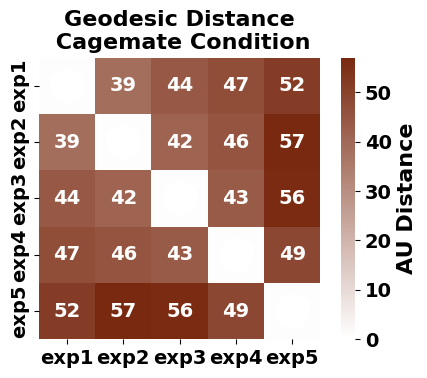

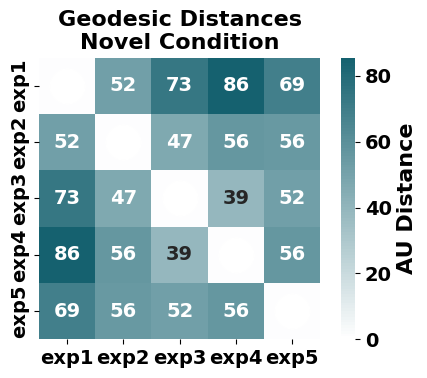

In [48]:
plot_comparison_heatmap(geo_dist, title = "Geodesic Distance\n Cagemate Condition", color = ['white', '#792910'], diagonal_color='white', vmin = 0)
plot_comparison_heatmap(novel_geo_dist, title = "Geodesic Distances\nNovel Condition", color = ['white', '#15616F'], diagonal_color='white', vmin = 0)

In [95]:

dimensionality = []
for recording in novel_collection.recordings:
    total_var = 0
    novel_pca_result = population_analysis.avg_trajectories_pca(recording, events = ['exp1 sniff', 'exp5 sniff'], event_length=5, pre_window = 3, min_neurons=5, plot = False)
    try:
        for i in range(len(novel_pca_result.explained_variance)):
            total_var = total_var + novel_pca_result.explained_variance[i]
            if total_var > .9:
                dimensionality.append(i)
                break
    except AttributeError:
        continue
            

print(np.mean(np.array(dimensionality)))

Excluding 33_nov_p1_merged.rec with 1 neurons
7.666666666666667


In [96]:
dimensionality = []
for recording in cagemate_collection.recordings:
    cagemate_pc_dict = population_analysis.avg_trajectories_pca(recording, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'], event_length=3, pre_window = 1, min_neurons=5, plot = False)
    total_var = 0
    if cagemate_pc_dict:
        for i in range(len(cagemate_pc_dict.explained_variance)):
            total_var = total_var + cagemate_pc_dict.explained_variance[i]
            if total_var > .9:
                dimensionality.append(i)
                break
            

print(np.mean(np.array(dimensionality)))

Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
9.555555555555555


In [97]:
dimensionality = []
for recording in novel_collection.recordings:
    novel_pc_dict = population_analysis.avg_trajectories_pca(recording, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'], event_length=3, pre_window = 1, min_neurons=5, plot = False)
    total_var = 0
    if novel_pc_dict:
        for i in range(len(novel_pc_dict.explained_variance)):
            total_var = total_var + novel_pc_dict.explained_variance[i]
            if total_var > .9:
                dimensionality.append(i)
                break
            

print(np.mean(np.array(dimensionality)))

Excluding 33_nov_p1_merged.rec with 1 neurons
8.333333333333334


## Trajectory Lengths

In [53]:
cage_length = population_analysis.avg_traj_len(cagemate_collection, percent_var = 90, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'], event_length=3, pre_window=1, post_window=0,  min_neurons = 5)
novel_length = population_analysis.avg_traj_len(novel_collection, percent_var = 90, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'], event_length=3, pre_window=1, post_window=0,  min_neurons = 5)
cage_length

Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons


,exp1 sniff,exp2 sniff,exp3 sniff,exp4 sniff,exp5 sniff
recording,,,,,
11_cage_p1_merged.rec,7.493800,11.137856,11.510393,10.765552,14.369743
12_cage_p1_merged.rec,11.937203,18.560462,13.163638,13.180740,15.111318
13_cage_p1_merged.rec,6.952044,11.631692,11.075659,9.350686,5.228305
21_cage_p1_merged.rec,15.543584,14.916671,16.006802,17.047623,13.696811
22_cage_p1_merged.rec,9.058705,9.053290,10.515513,10.999295,13.310821
24_cage_p1_merged.rec,7.124452,7.716864,10.510165,8.751901,7.835139
32_cage_p1_merged.rec,10.174249,9.362478,13.291755,9.680767,8.227959
41_cage_p1_merged.rec,8.394621,7.089670,9.372871,9.389635,11.021709
44_cage_p1_merged.rec,8.959647,8.298585,15.139220,16.404130,12.701428


Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons


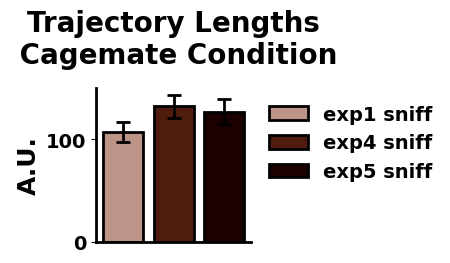

,Comparison,t_statistic,p_value,p_adjusted,significant
0,exp1 sniff_exp4,-3.004300,0.016960,0.050881,False
1,exp1 sniff_exp5,-1.832232,0.104280,0.208560,False
2,exp4 sniff_exp5,0.522862,0.615238,0.615238,False


In [ ]:
from scipy.spatial.distance import euclidean
from statsmodels.stats.multitest import multipletests
def trajectory_length(pca_matrix, key):
    trajectory_lengths = []
    event_order = []
    unique_values, counts = np.unique(key, return_counts=True)
    event_len = counts[0]
    for j in range(0, len(key), event_len):
        trajectory_length = 0
        for i in range(event_len-1):
            trajectory_length = trajectory_length + euclidean(
                pca_matrix[j+i, :],
                pca_matrix[j+i+1, :])
        trajectory_lengths.append(trajectory_length)
        event_order.append(key[j])
    return [trajectory_lengths, event_order]

trajectory_lengths = []
orders= []
for recording in cagemate_collection.recordings:
    pc_result = population_analysis.avg_trajectories_pca(recording, event_length = 3, pre_window = 1,
                                                 events = ['exp1 sniff',
                                                           'exp2 sniff',
                                                            'exp3 sniff',
                                                           'exp4 sniff',
                                                           'exp5 sniff'], min_neurons=5, plot = False)
    if pc_result:
        [traj_len, event_order] = trajectory_length(pc_result.transformed_data, pc_result.labels)
        trajectory_lengths.append(traj_len)
        orders.append(event_order)
trajectory_lengths = np.array(trajectory_lengths)



means = np.mean(trajectory_lengths, axis = 0) #across recordings
sems = sem(trajectory_lengths, axis = 0)
means_for_plotting = means[[0,3,4]]
sems_for_plotting = sems[[0,3,4]]

t_exp1_exp4, p_exp1_exp4 = stats.ttest_rel(trajectory_lengths[:,0], trajectory_lengths[:,3])
t_exp1_exp5, p_exp1_exp5 = stats.ttest_rel(trajectory_lengths[:,0], trajectory_lengths[:,4])
t_exp4_exp5, p_exp4_exp5 = stats.ttest_rel(trajectory_lengths[:,3], trajectory_lengths[:,4])
p_values = [p_exp1_exp4, p_exp1_exp5, p_exp4_exp5]
reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
stats_df = pd.DataFrame({
   'Comparison': ['exp1 sniff_exp4', 'exp1 sniff_exp5', 'exp4 sniff_exp5'],
   't_statistic': [t_exp1_exp4, t_exp1_exp5, t_exp4_exp5],
   'p_value': p_values,
   'p_adjusted': p_adjusted,
   'significant': reject
})

# Adjust p-values using Holm-Bonferroni
p_values = [p_exp1_exp4, p_exp1_exp5, p_exp4_exp5]
reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
color_id_dict = {'exp1 sniff': hex_2_rgb('#bc9488'), 
                'exp4 sniff': hex_2_rgb("#4e1d0d"),
                  'exp5 sniff':  hex_2_rgb('#1C0000')}
# cagemate_expsniffcolors = [hex_2_rgb('#bc9488'),
#               hex_2_rgb('#9b5f4c'),
#               hex_2_rgb('#792910'),
#               hex_2_rgb("#4e1d0d"),
#               hex_2_rgb("#1C0000")]
hatches = ['','','']  
x = [0.5,1,1.5]
plt.figure(figsize= (2,2))           
plt.bar(x, means_for_plotting, yerr = sems_for_plotting,
            color = color_id_dict.values(), hatch = hatches,
            edgecolor = ['black', 'black', 'black'],
            capsize = 5, linewidth = 2,
            error_kw={'elinewidth': 2, 'capthick': 2}, 
            width = .4)
plt.xticks([],rotation=45)
legend_handles = [Patch(facecolor=color, label=label) for label, color in color_id_dict.items()]
plt.legend(handles=legend_handles,
           bbox_to_anchor=(1,1),
           frameon= False, fontsize = 14)
plt.ylabel('A.U.', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(300))
# plt.ylim(500,1500)
hatches = ['//','','','', '']
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Trajectory Lengths\n Cagemate Condition', fontsize = 20, y = 1.1)
plt.show()

stats_df


(9, 5)


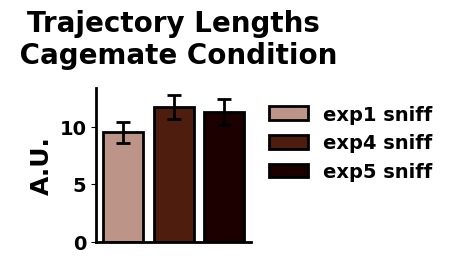

,Comparison,t_statistic,p_value,p_adjusted,significant
0,exp1 sniff_exp4,-3.001767,0.017026,0.051077,False
1,exp1 sniff_exp5,-1.682379,0.130997,0.261994,False
2,exp4 sniff_exp5,0.465791,0.653783,0.653783,False


In [58]:
trajectory_lengths = np.array(cage_length)
means = np.mean(trajectory_lengths, axis = 0) #across recordings
sems = sem(trajectory_lengths, axis = 0)
means_for_plotting = means[[0,3,4]] #exp1, exp4, exp5
sems_for_plotting = sems[[0,3,4]]

t_exp1_exp4, p_exp1_exp4 = stats.ttest_rel(trajectory_lengths[:,0], trajectory_lengths[:,3])
t_exp1_exp5, p_exp1_exp5 = stats.ttest_rel(trajectory_lengths[:,0], trajectory_lengths[:,4])
t_exp4_exp5, p_exp4_exp5 = stats.ttest_rel(trajectory_lengths[:,3], trajectory_lengths[:,4])
p_values = [p_exp1_exp4, p_exp1_exp5, p_exp4_exp5]
reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
stats_df = pd.DataFrame({
   'Comparison': ['exp1 sniff_exp4', 'exp1 sniff_exp5', 'exp4 sniff_exp5'],
   't_statistic': [t_exp1_exp4, t_exp1_exp5, t_exp4_exp5],
   'p_value': p_values,
   'p_adjusted': p_adjusted,
   'significant': reject
})

# Adjust p-values using Holm-Bonferroni
p_values = [p_exp1_exp4, p_exp1_exp5, p_exp4_exp5]
reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
color_id_dict = {'exp1 sniff': hex_2_rgb('#bc9488'), 
                'exp4 sniff': hex_2_rgb("#4e1d0d"),
                  'exp5 sniff':  hex_2_rgb('#1C0000')}
# cagemate_expsniffcolors = [hex_2_rgb('#bc9488'),
#               hex_2_rgb('#9b5f4c'),
#               hex_2_rgb('#792910'),
#               hex_2_rgb("#4e1d0d"),
#               hex_2_rgb("#1C0000")]
hatches = ['','','']  
x = [0.5,1,1.5]
plt.figure(figsize= (2,2))           
plt.bar(x, means_for_plotting, yerr = sems_for_plotting,
            color = color_id_dict.values(), hatch = hatches,
            edgecolor = ['black', 'black', 'black'],
            capsize = 5, linewidth = 2,
            error_kw={'elinewidth': 2, 'capthick': 2}, 
            width = .4)
plt.xticks([],rotation=45)
legend_handles = [Patch(facecolor=color, label=label) for label, color in color_id_dict.items()]
plt.legend(handles=legend_handles,
           bbox_to_anchor=(1,1),
           frameon= False, fontsize = 14)
plt.ylabel('A.U.', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(300))
# plt.ylim(500,1500)
hatches = ['//','','','', '']
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Trajectory Lengths\n Cagemate Condition', fontsize = 20, y = 1.1)
plt.show()

stats_df


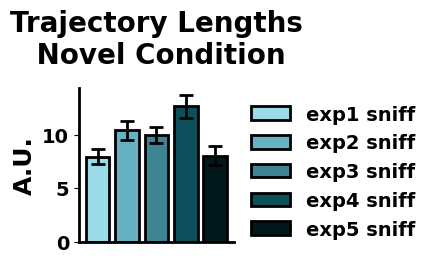

,Comparison,t_statistic,p_value,p_adjusted,significant
0,exp1 sniff_exp4,-3.748378,0.005637,0.016912,True
1,exp1 sniff_exp5,-0.141651,0.890858,0.890858,False
2,exp4 sniff_exp5,3.666212,0.006344,0.016912,True


In [59]:
trajectory_lengths = np.array(novel_length)



means = np.mean(trajectory_lengths, axis = 0)
sems = sem(trajectory_lengths, axis = 0)

t_exp1_exp4, p_exp1_exp4 = stats.ttest_rel(trajectory_lengths[:,0], trajectory_lengths[:,3])
t_exp1_exp5, p_exp1_exp5 = stats.ttest_rel(trajectory_lengths[:,0], trajectory_lengths[:,4])
t_exp4_exp5, p_exp4_exp5 = stats.ttest_rel(trajectory_lengths[:,3], trajectory_lengths[:,4])
p_values = [p_exp1_exp4, p_exp1_exp5, p_exp4_exp5]
reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
stats_df = pd.DataFrame({
   'Comparison': ['exp1 sniff_exp4', 'exp1 sniff_exp5', 'exp4 sniff_exp5'],
   't_statistic': [t_exp1_exp4, t_exp1_exp5, t_exp4_exp5],
   'p_value': p_values,
   'p_adjusted': p_adjusted,
   'significant': reject
})

# Adjust p-values using Holm-Bonferroni
p_values = [p_exp1_exp4, p_exp1_exp5, p_exp4_exp5]
reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
color_id_dict = {'exp1 sniff': hex_2_rgb("#9BDAE7"), 
                 'exp2 sniff' :hex_2_rgb("#66B1C4"),
                 'exp3 sniff': hex_2_rgb("#3E8492"),
                'exp4 sniff': hex_2_rgb("#0D4F5B"),
                  'exp5 sniff':  hex_2_rgb("#00181C")}

# novel_expsniffcolors = [hex_2_rgb("#9BDAE7"),
#               hex_2_rgb("#66B1C4"),
#               hex_2_rgb("#3E8492"),
#               hex_2_rgb("#0D4F5B"),
#               hex_2_rgb("#00181C")]
hatches = ['','','', '', '']  
x = [0, 0.5,1,1.5, 2]
plt.figure(figsize= (2,2))           
plt.bar(x, means, yerr = sems,
            color = color_id_dict.values(),
            edgecolor = ['black'],
            capsize = 5, linewidth = 2,
            error_kw={'elinewidth': 2, 'capthick': 2}, 
            width = .4)
plt.xticks([],rotation=45)
legend_handles = [Patch(facecolor=color, label=label) for label, color in color_id_dict.items()]
plt.legend(handles=legend_handles,
           bbox_to_anchor=(1,1),
           frameon= False, fontsize = 14)
plt.ylabel('A.U.', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(20))
# plt.ylim(40,100)
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Trajectory Lengths\n Novel Condition', fontsize = 20, y = 1.1)
plt.show()

stats_df

In [99]:
cagemate_expsniffcolors = [hex_2_rgb('#bc9488'),
              hex_2_rgb('#9b5f4c'),
              hex_2_rgb('#792910'),
              hex_2_rgb("#4e1d0d"),
              hex_2_rgb("#1C0000")]
novel_expsniffcolors = [hex_2_rgb("#9BDAE7"),
              hex_2_rgb("#66B1C4"),
              hex_2_rgb("#3E8492"),
              hex_2_rgb("#0D4F5B"),
              hex_2_rgb("#00181C")]

Excluding 33_nov_p1_merged.rec with 1 neurons


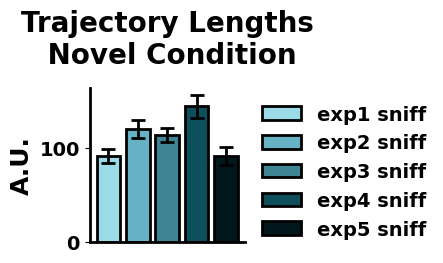

,Comparison,t_statistic,p_value,p_adjusted,significant
0,exp1 sniff_exp4,-3.651167,0.006483,0.019450,True
1,exp1 sniff_exp5,-0.062805,0.951462,0.951462,False
2,exp4 sniff_exp5,3.645134,0.006540,0.019450,True


In [100]:
def trajectory_length(pca_matrix, key):
    trajectory_lengths = []
    event_order = []
    unique_values, counts = np.unique(key, return_counts=True)
    event_len = counts[0]
    for j in range(0, len(key), event_len):
        trajectory_length = 0
        for i in range(event_len-1):
            trajectory_length = trajectory_length + euclidean(
                pca_matrix[j+i, :],
                pca_matrix[j+i+1, :])
        trajectory_lengths.append(trajectory_length)
        event_order.append(key[j])
    return [trajectory_lengths, event_order]

trajectory_lengths = []
orders= []
for recording in novel_collection.recordings:
    pc_result = population_analysis.avg_trajectories_pca(recording, event_length = 3, pre_window = 1,
                                                 events = ['exp1 sniff',
                                                           'exp2 sniff',
                                                            'exp3 sniff',
                                                           'exp4 sniff',
                                                           'exp5 sniff'], min_neurons=5, plot = False)
    if pc_result:
        [traj_len, event_order] = trajectory_length(pc_result.transformed_data, pc_result.labels)
        trajectory_lengths.append(traj_len)
        orders.append(event_order)
trajectory_lengths = np.array(trajectory_lengths)



means = np.mean(trajectory_lengths, axis = 0)
sems = sem(trajectory_lengths, axis = 0)

t_exp1_exp4, p_exp1_exp4 = stats.ttest_rel(trajectory_lengths[:,0], trajectory_lengths[:,3])
t_exp1_exp5, p_exp1_exp5 = stats.ttest_rel(trajectory_lengths[:,0], trajectory_lengths[:,4])
t_exp4_exp5, p_exp4_exp5 = stats.ttest_rel(trajectory_lengths[:,3], trajectory_lengths[:,4])
p_values = [p_exp1_exp4, p_exp1_exp5, p_exp4_exp5]
reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
stats_df = pd.DataFrame({
   'Comparison': ['exp1 sniff_exp4', 'exp1 sniff_exp5', 'exp4 sniff_exp5'],
   't_statistic': [t_exp1_exp4, t_exp1_exp5, t_exp4_exp5],
   'p_value': p_values,
   'p_adjusted': p_adjusted,
   'significant': reject
})

# Adjust p-values using Holm-Bonferroni
p_values = [p_exp1_exp4, p_exp1_exp5, p_exp4_exp5]
reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
color_id_dict = {'exp1 sniff': hex_2_rgb("#9BDAE7"), 
                 'exp2 sniff' :hex_2_rgb("#66B1C4"),
                 'exp3 sniff': hex_2_rgb("#3E8492"),
                'exp4 sniff': hex_2_rgb("#0D4F5B"),
                  'exp5 sniff':  hex_2_rgb("#00181C")}

# novel_expsniffcolors = [hex_2_rgb("#9BDAE7"),
#               hex_2_rgb("#66B1C4"),
#               hex_2_rgb("#3E8492"),
#               hex_2_rgb("#0D4F5B"),
#               hex_2_rgb("#00181C")]
hatches = ['','','', '', '']  
x = [0, 0.5,1,1.5, 2]
plt.figure(figsize= (2,2))           
plt.bar(x, means, yerr = sems,
            color = color_id_dict.values(),
            edgecolor = ['black'],
            capsize = 5, linewidth = 2,
            error_kw={'elinewidth': 2, 'capthick': 2}, 
            width = .4)
plt.xticks([],rotation=45)
legend_handles = [Patch(facecolor=color, label=label) for label, color in color_id_dict.items()]
plt.legend(handles=legend_handles,
           bbox_to_anchor=(1,1),
           frameon= False, fontsize = 14)
plt.ylabel('A.U.', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(20))
# plt.ylim(40,100)
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Trajectory Lengths\n Novel Condition', fontsize = 20, y = 1.1)
plt.show()

stats_df

In [119]:
from sklearn.decomposition import PCA
pcaresult_exp1 = population_analysis.avg_trajectories_pca(cagemate_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp1 sniff'], plot = False)
pcaresult_exp2 = population_analysis.avg_trajectories_pca(cagemate_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp2 sniff'], plot = False)
pcaresult_exp4 = population_analysis.avg_trajectories_pca(cagemate_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp4 sniff'], plot = False)
pcaresult_exp5 = population_analysis.avg_trajectories_pca(cagemate_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp5 sniff'], plot = False)

# total variance in the raw data
total_var_exp1 = np.var(pcaresult_exp1.raw_data, axis=0).sum()
total_var_exp2 = np.var(pcaresult_exp2.raw_data, axis=0).sum()
total_var_exp4 = np.var(pcaresult_exp4.raw_data, axis=0).sum()
total_var_exp5 = np.var(pcaresult_exp5.raw_data, axis=0).sum()

#project into exp1 PCA space
pcaresult_exp1.raw_data.shape
pca_exp1 = PCA()
pca_exp1.fit(pcaresult_exp1.raw_data)

exp4_in_exp1 = pca_exp1.transform(pcaresult_exp4.raw_data)
exp5_in_exp1 = pca_exp1.transform(pcaresult_exp5.raw_data)
exp2_in_exp1 = pca_exp1.transform(population_analysis.avg_trajectories_pca(cagemate_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp2 sniff'], plot = False).raw_data)


# variance captured by each PC in the novel data
var_per_pc_4in1 = np.var(exp4_in_exp1, axis=0)
var_per_pc_5in1 = np.var(exp5_in_exp1, axis=0)
var_per_pc_2in1 = np.var(exp2_in_exp1, axis=0)

# explained variance ratio for novel data projected onto cagemate PCs
evr_exp4_on_exp1_axes = var_per_pc_4in1 / total_var_exp4
evr_exp5_on_exp1_axes = var_per_pc_5in1 / total_var_exp5
evr_exp2_on_exp1_axes = var_per_pc_2in1 / total_var_exp2

print("EXP1 EVR (from fit):", pcaresult_exp1.explained_variance[:5])
print("EXP4 EVR (on EXP1 axes):", evr_exp4_on_exp1_axes[:5])
print("EXP5 EVR (on EXP1 axes):", evr_exp5_on_exp1_axes[:5])
print("EXP2 EVR (on EXP1 axes):", evr_exp2_on_exp1_axes[:5])
print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')

#project into exp4 PCA space
pca_exp4 = PCA()
pca_exp4.fit(pcaresult_exp4.raw_data)

exp1_in_exp4 = pca_exp4.transform(pcaresult_exp1.raw_data)
exp5_in_exp4 = pca_exp4.transform(pcaresult_exp5.raw_data)
exp3_in_exp4 = pca_exp4.transform(population_analysis.avg_trajectories_pca(cagemate_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp3 sniff'], plot = False).raw_data)

# variance captured by each PC in the novel data
var_per_pc_1in4 = np.var(exp1_in_exp4, axis=0)
var_per_pc_5in4 = np.var(exp5_in_exp4, axis=0)
var_per_pc_3in4 = np.var(exp3_in_exp4, axis=0)


# explained variance ratio for novel data projected onto cagemate PCs
evr_exp1_on_exp4_axes = var_per_pc_1in4 / total_var_exp1
evr_exp5_on_exp4_axes = var_per_pc_5in4 / total_var_exp5
evr_exp3_on_exp4_axes = var_per_pc_3in4 / total_var_exp4

print("EXP4 EVR (from fit):", pcaresult_exp4.explained_variance[:5])
print("EXP1 EVR (on EXP4 axes):", evr_exp1_on_exp4_axes[:5])
print("EXP5 EVR (on EXP4 axes):", evr_exp5_on_exp4_axes[:5])
print("EXP3 EVR (on EXP4 axes):", evr_exp3_on_exp4_axes[:5])
print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')

#project into exp5 PCA space
pca_exp5 = PCA()
pca_exp5.fit(pcaresult_exp5.raw_data)
exp1_in_exp5 = pca_exp5.transform(pcaresult_exp1.raw_data)
exp4_in_exp5 = pca_exp5.transform(pcaresult_exp4.raw_data)

# variance captured by each PC in the novel data
var_per_pc_1in5 = np.var(exp1_in_exp5, axis=0)
var_per_pc_4in5 = np.var(exp4_in_exp5, axis=0)  

# explained variance ratio for novel data projected onto cagemate PCs
evr_exp1_on_exp5_axes = var_per_pc_1in5 / total_var_exp1
evr_exp4_on_exp5_axes = var_per_pc_4in5 / total_var_exp4    

print("EXP5 EVR (from fit):", pcaresult_exp5.explained_variance[:5])
print("EXP1 EVR (on EXP5 axes):", evr_exp1_on_exp5_axes[:5])
print("EXP4 EVR (on EXP5 axes):", evr_exp4_on_exp5_axes[:5])


Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
EXP1 EVR (from fit): [0.13219224 0.0893691  0.07147717 0.05612403 0.05452179]
EXP4 EVR (on EXP1 axes): [0.03217725 0.05306105 0.02226212 0.03891594 0.03960843]
EXP5 EVR (on EXP1 axes): [0.02742359 0.08254446 0.02746281 0.05303819 0.07680126]
EXP2 EVR (on EXP1 axes): [0.08184373 0.03596782 0.05125299 0.07091806 0.03805465]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
EXP4 EVR (from fit): [0.11924478 0.09958082 0.06290417 0.05870709 0.05219373]
EXP1

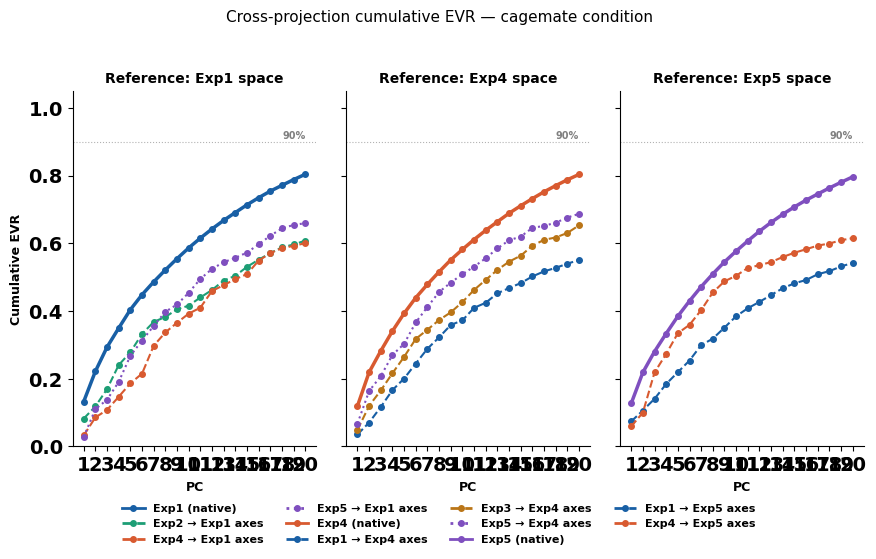

In [120]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def plot_cumulative_evr(
    evr_dict,
    n_pcs=10,
    figsize=(9, 5),
    save_path=None
):
    """
    Plot cumulative explained variance ratio for cross-projection PCA analysis.

    Parameters
    ----------
    evr_dict : dict
        Keys are (label, reference_space, linestyle, color) tuples.
        Values are 1D arrays of per-PC EVR.
        See example usage below.
    n_pcs : int
        Number of PCs to show on x-axis.
    figsize : tuple
    save_path : str or None
        If provided, saves the figure to this path.
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)
    ref_spaces = ['Exp1 space', 'Exp4 space', 'Exp5 space']

    for ax, ref in zip(axes, ref_spaces):
        for (label, space, ls, color), evr in evr_dict.items():
            if space != ref:
                continue
            cumevr = np.cumsum(evr[:n_pcs])
            pcs = np.arange(1, len(cumevr) + 1)
            lw = 2.5 if ls == '-' else 1.5
            ax.plot(pcs, cumevr, ls=ls, color=color, lw=lw, label=label,
                    marker='o', markersize=4)

        ax.set_title(f'Reference: {ref}', fontsize=10, pad=6)
        ax.set_xlabel('PC', fontsize=9)
        ax.set_xticks(np.arange(1, n_pcs + 1))
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_ylim(0, 1.05)
        ax.axhline(0.9, color='gray', lw=0.8, ls=':', alpha=0.6)
        ax.text(n_pcs, 0.91, '90%', fontsize=7, color='gray', ha='right')

    axes[0].set_ylabel('Cumulative EVR', fontsize=9)

    # Build a unified legend from all entries
    handles = []
    seen = set()
    for (label, space, ls, color), _ in evr_dict.items():
        if label not in seen:
            handles.append(
                mlines.Line2D([], [], color=color, ls=ls, lw=2,
                              marker='o', markersize=4, label=label)
            )
            seen.add(label)

    fig.legend(handles=handles, loc='lower center',
               ncol=min(len(handles), 4), fontsize=8,
               frameon=False, bbox_to_anchor=(0.5, -0.08))

    fig.suptitle('Cross-projection cumulative EVR — cagemate condition',
                 fontsize=11, y=1.01)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ── Plug in your computed arrays below ──────────────────────────────────────
# Color scheme: Exp1=blue, Exp2=teal, Exp3=amber, Exp4=coral, Exp5=purple
# Solid lines = native space; dashed = cross-projected

evr_dict = {
    # (label,              reference space, linestyle, color)
    ('Exp1 (native)',      'Exp1 space', '-',  '#185FA5'): pcaresult_exp1.explained_variance,
    ('Exp2 → Exp1 axes',   'Exp1 space', '--', '#1D9E75'): evr_exp2_on_exp1_axes,
    ('Exp4 → Exp1 axes',   'Exp1 space', '--', '#D85A30'): evr_exp4_on_exp1_axes,
    ('Exp5 → Exp1 axes',   'Exp1 space', ':',  '#7F4FBF'): evr_exp5_on_exp1_axes,

    ('Exp4 (native)',      'Exp4 space', '-',  '#D85A30'): pcaresult_exp4.explained_variance,
    ('Exp1 → Exp4 axes',   'Exp4 space', '--', '#185FA5'): evr_exp1_on_exp4_axes,
    ('Exp3 → Exp4 axes',   'Exp4 space', '--', '#BA7517'): evr_exp3_on_exp4_axes,
    ('Exp5 → Exp4 axes',   'Exp4 space', ':',  '#7F4FBF'): evr_exp5_on_exp4_axes,

    ('Exp5 (native)',      'Exp5 space', '-',  '#7F4FBF'): pcaresult_exp5.explained_variance,
    ('Exp1 → Exp5 axes',   'Exp5 space', '--', '#185FA5'): evr_exp1_on_exp5_axes,
    ('Exp4 → Exp5 axes',   'Exp5 space', '--', '#D85A30'): evr_exp4_on_exp5_axes,
}

plot_cumulative_evr(evr_dict, n_pcs=20)

Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons


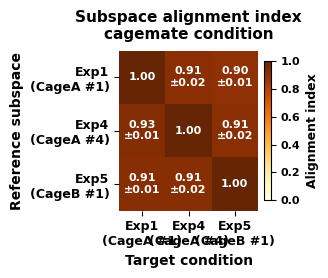

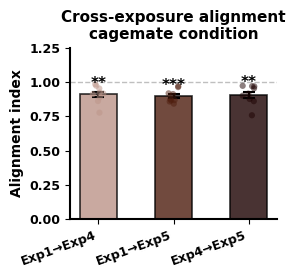

  Comparison    t_stat   p_value  p_adjusted sig
0  Exp1→Exp4 -4.301713  0.002610    0.005219   *
1  Exp1→Exp5 -6.736976  0.000147    0.000441   *
2  Exp4→Exp5 -3.918685  0.004427    0.005219   *


In [67]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ── 1. Core alignment index function (Miri et al. formulation) ──────────────
def alignment_index(D1, D2, n_pcs=None):
    """
    Compute how well the PCA subspace of D1 captures the variance in D2.

    alignment = tr(P1.T @ cov(D2) @ P1) / tr(P2.T @ cov(D2) @ P2)

    Parameters
    ----------
    D1 : array (time x neurons)  — reference condition (defines the subspace)
    D2 : array (time x neurons)  — target condition (whose variance we measure)
    n_pcs : int or None — number of PCs to use. If None, uses PCs capturing 90% variance.

    Returns
    -------
    float in [0, 1]
    """
    pca1 = PCA()
    pca1.fit(D1)

    if n_pcs is None:
        cumvar = np.cumsum(pca1.explained_variance_ratio_)
        n_pcs = np.searchsorted(cumvar, 0.90) + 1

    P1 = pca1.components_[:n_pcs].T  # (neurons x n_pcs)

    pca2 = PCA(n_components=n_pcs)
    pca2.fit(D2)
    P2 = pca2.components_[:n_pcs].T  # (neurons x n_pcs)

    cov_D2 = np.cov(D2.T)  # (neurons x neurons)

    num = np.trace(P1.T @ cov_D2 @ P1)
    den = np.trace(P2.T @ cov_D2 @ P2)

    return num / den if den > 0 else np.nan


# ── 2. Compute per-animal alignment matrices ─────────────────────────────────
events_of_interest = ['exp1 sniff', 'exp4 sniff', 'exp5 sniff']
exp_labels = ['Exp1\n(CageA #1)', 'Exp4\n(CageA #4)', 'Exp5\n(CageB #1)']
n_exps = len(events_of_interest)

all_alignment_matrices = []  # one 3x3 matrix per animal

for recording in cagemate_collection.recordings:
    # get raw data per event — shape: (timepoints, neurons)
    raw_data = {}
    valid = True
    for event in events_of_interest:
        pc_result = population_analysis.avg_trajectories_pca(
            recording,
            event_length=6, pre_window=6, post_window=0,
            min_neurons=5, events=[event], plot=False
        )
        if pc_result is None:
            valid = False
            break
        raw_data[event] = pc_result.raw_data  # (timepoints x neurons)

    if not valid:
        continue

    mat = np.full((n_exps, n_exps), np.nan)
    for i, ref_event in enumerate(events_of_interest):
        for j, tgt_event in enumerate(events_of_interest):
            if i == j:
                mat[i, j] = 1.0  # diagonal: perfect alignment with itself
            else:
                mat[i, j] = alignment_index(
                    raw_data[ref_event],
                    raw_data[tgt_event]
                )
    all_alignment_matrices.append(mat)

all_alignment_matrices = np.array(all_alignment_matrices)  # (n_animals, 3, 3)
mean_mat = np.nanmean(all_alignment_matrices, axis=0)
sem_mat  = np.nanstd(all_alignment_matrices, axis=0) / np.sqrt(
    np.sum(~np.isnan(all_alignment_matrices), axis=0))


# ── 3. Plot: heatmap of mean alignment ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(3.5, 3))

im = ax.imshow(mean_mat, vmin=0, vmax=1,
               cmap='YlOrBr', aspect='auto')

ax.set_xticks(range(n_exps))
ax.set_yticks(range(n_exps))
ax.set_xticklabels(exp_labels, fontsize=9)
ax.set_yticklabels(exp_labels, fontsize=9)
ax.set_xlabel('Target condition', fontsize=10)
ax.set_ylabel('Reference subspace', fontsize=10)
ax.set_title('Subspace alignment index\ncagemate condition', fontsize=11, pad=8)

# annotate cells with mean ± sem
for i in range(n_exps):
    for j in range(n_exps):
        val = mean_mat[i, j]
        se  = sem_mat[i, j]
        txt = f'{val:.2f}' if i == j else f'{val:.2f}\n±{se:.2f}'
        color = 'white' if val > 0.6 else 'black'
        ax.text(j, i, txt, ha='center', va='center',
                fontsize=8, color=color)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Alignment index', fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig('alignment_heatmap.pdf', dpi=150, bbox_inches='tight')
plt.show()


# ── 4. Plot: per-animal dots + mean bar for off-diagonal comparisons ──────────
# pairs: (ref_idx, tgt_idx, label)
pairs = [
    (0, 1, 'Exp1→Exp4'),
    (0, 2, 'Exp1→Exp5'),
    (1, 2, 'Exp4→Exp5'),
]

pair_data = [all_alignment_matrices[:, r, t] for r, t, _ in pairs]
pair_labels = [lbl for _, _, lbl in pairs]

# stats: pairwise t-tests against 1.0 (are they significantly < diagonal?)
# or compare pairs against each other
p_vals = []
t_stats = []
for data in pair_data:
    t, p = stats.ttest_1samp(data[~np.isnan(data)], popmean=1.0)
    t_stats.append(t)
    p_vals.append(p)

_, p_adj, _, _ = multipletests(p_vals, method='holm')

fig, ax = plt.subplots(figsize=(3, 3))
x_pos = np.arange(len(pairs))
colors = ['#bc9488', '#4e1d0d', '#1C0000']

for xi, (data, color) in enumerate(zip(pair_data, colors)):
    clean = data[~np.isnan(data)]
    # individual animals (jittered)
    jitter = np.random.uniform(-0.08, 0.08, len(clean))
    ax.scatter(xi + jitter, clean, color=color, alpha=0.5,
               s=20, zorder=3, edgecolors='none')
    # mean + sem bar
    m = np.mean(clean)
    se = np.std(clean) / np.sqrt(len(clean))
    ax.bar(xi, m, width=0.5, color=color, alpha=0.8,
           edgecolor='black', linewidth=1.2, zorder=2)
    ax.errorbar(xi, m, yerr=se, fmt='none',
                color='black', capsize=4, linewidth=1.5, capthick=1.5)

    # significance annotation
    sig = '***' if p_adj[xi] < 0.001 else '**' if p_adj[xi] < 0.01 \
          else '*' if p_adj[xi] < 0.05 else 'n.s.'
    ax.text(xi, m + se + 0.03, sig, ha='center', fontsize=11)

ax.axhline(1.0, color='gray', lw=1, ls='--', alpha=0.5, label='diagonal (self)')
ax.set_xticks(x_pos)
ax.set_xticklabels(pair_labels, fontsize=9, rotation=20, ha='right')
ax.set_ylabel('Alignment index', fontsize=10)
ax.set_ylim(0, 1.25)
ax.set_title('Cross-exposure alignment\ncagemate condition', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_linewidth(1.5)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('alignment_bars.pdf', dpi=150, bbox_inches='tight')
plt.show()

print(pd.DataFrame({
    'Comparison': pair_labels,
    't_stat': t_stats,
    'p_value': p_vals,
    'p_adjusted': p_adj,
    'sig': ['*' if p < 0.05 else 'n.s.' for p in p_adj]
}))

Excluding 33_nov_p1_merged.rec with 1 neurons


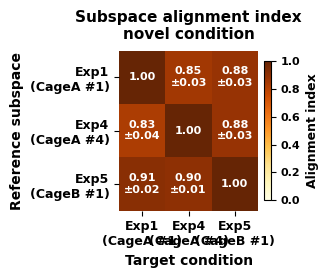

                                          Comparison    t_stat   p_value  \
0  Exp1→Exp5\n(diff agent) vs Exp1→Exp4\n(same ag...  1.761229  0.116229   
1  Exp4→Exp5\n(diff agent) vs Exp1→Exp4\n(same ag...  1.325195  0.221702   
2  Exp4→Exp5\n(diff agent) vs Exp1→Exp5\n(diff ag... -0.447264  0.666547   

   p_adjusted   sig  
0    0.348687  n.s.  
1    0.443405  n.s.  
2    0.666547  n.s.  


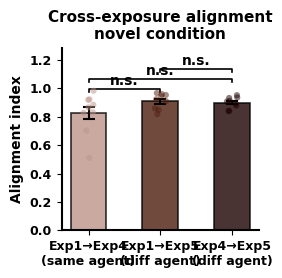

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ── 1. Core alignment index function (Miri et al. formulation) ──────────────
def alignment_index(D1, D2, n_pcs=None):
    """
    Compute how well the PCA subspace of D1 captures the variance in D2.

    alignment = tr(P1.T @ cov(D2) @ P1) / tr(P2.T @ cov(D2) @ P2)

    Parameters
    ----------
    D1 : array (time x neurons)  — reference condition (defines the subspace)
    D2 : array (time x neurons)  — target condition (whose variance we measure)
    n_pcs : int or None — number of PCs to use. If None, uses PCs capturing 90% variance.

    Returns
    -------
    float in [0, 1]
    """
    pca1 = PCA()
    pca1.fit(D1)

    if n_pcs is None:
        cumvar = np.cumsum(pca1.explained_variance_ratio_)
        n_pcs = np.searchsorted(cumvar, 0.90) + 1

    P1 = pca1.components_[:n_pcs].T  # (neurons x n_pcs)

    pca2 = PCA(n_components=n_pcs)
    pca2.fit(D2)
    P2 = pca2.components_[:n_pcs].T  # (neurons x n_pcs)

    cov_D2 = np.cov(D2.T)  # (neurons x neurons)

    num = np.trace(P1.T @ cov_D2 @ P1)
    den = np.trace(P2.T @ cov_D2 @ P2)

    return num / den if den > 0 else np.nan


# ── 2. Compute per-animal alignment matrices ─────────────────────────────────
events_of_interest = ['exp1 sniff', 'exp4 sniff', 'exp5 sniff']
exp_labels = ['Exp1\n(CageA #1)', 'Exp4\n(CageA #4)', 'Exp5\n(CageB #1)']
n_exps = len(events_of_interest)

all_alignment_matrices = []  # one 3x3 matrix per animal

for recording in novel_collection.recordings:
    # get raw data per event — shape: (timepoints, neurons)
    raw_data = {}
    valid = True
    for event in events_of_interest:
        pc_result = population_analysis.avg_trajectories_pca(
            recording,
            event_length=6, pre_window=6, post_window=0,
            min_neurons=5, events=[event], plot=False
        )
        if pc_result is None:
            valid = False
            break
        raw_data[event] = pc_result.raw_data  # (timepoints x neurons)

    if not valid:
        continue

    mat = np.full((n_exps, n_exps), np.nan)
    for i, ref_event in enumerate(events_of_interest):
        for j, tgt_event in enumerate(events_of_interest):
            if i == j:
                mat[i, j] = 1.0  # diagonal: perfect alignment with itself
            else:
                mat[i, j] = alignment_index(
                    raw_data[ref_event],
                    raw_data[tgt_event]
                )
    all_alignment_matrices.append(mat)

all_alignment_matrices = np.array(all_alignment_matrices)  # (n_animals, 3, 3)
mean_mat = np.nanmean(all_alignment_matrices, axis=0)
sem_mat  = np.nanstd(all_alignment_matrices, axis=0) / np.sqrt(
    np.sum(~np.isnan(all_alignment_matrices), axis=0))


# ── 3. Plot: heatmap of mean alignment ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(3.5, 3))

im = ax.imshow(mean_mat, vmin=0, vmax=1,
               cmap='YlOrBr', aspect='auto')

ax.set_xticks(range(n_exps))
ax.set_yticks(range(n_exps))
ax.set_xticklabels(exp_labels, fontsize=9)
ax.set_yticklabels(exp_labels, fontsize=9)
ax.set_xlabel('Target condition', fontsize=10)
ax.set_ylabel('Reference subspace', fontsize=10)
ax.set_title('Subspace alignment index\nnovel condition', fontsize=11, pad=8)

# annotate cells with mean ± sem
for i in range(n_exps):
    for j in range(n_exps):
        val = mean_mat[i, j]
        se  = sem_mat[i, j]
        txt = f'{val:.2f}' if i == j else f'{val:.2f}\n±{se:.2f}'
        color = 'white' if val > 0.6 else 'black'
        ax.text(j, i, txt, ha='center', va='center',
                fontsize=8, color=color)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Alignment index', fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig('alignment_heatmap.pdf', dpi=150, bbox_inches='tight')
plt.show()


# ── Stats: pairwise t-tests between off-diagonal comparisons ─────────────────
# each entry all_alignment_matrices[:, i, j] is a per-animal alignment value

# define which off-diagonal cells to compare
# (ref_idx, tgt_idx, label)
pairs = [
    (1, 0, 'Exp1→Exp4\n(same agent)'),
    (2, 0, 'Exp1→Exp5\n(diff agent)'),
    (2, 1, 'Exp4→Exp5\n(diff agent)'),
]
pair_data   = [all_alignment_matrices[:, r, t] for r, t, _ in pairs]
pair_labels = [lbl for _, _, lbl in pairs]

# all pairwise t-tests between the three comparisons
comparison_pairs = [
    (1, 0, f'{pair_labels[1]} vs {pair_labels[0]}'),
    (2, 0, f'{pair_labels[2]} vs {pair_labels[0]}'),
    (2, 1, f'{pair_labels[2]} vs {pair_labels[1]}'),
]

t_stats, p_vals = [], []
for i, j, _ in comparison_pairs:
    a = pair_data[i][~np.isnan(pair_data[i])]
    b = pair_data[j][~np.isnan(pair_data[j])]
    t, p = stats.ttest_rel(a, b)
    t_stats.append(t)
    p_vals.append(p)

_, p_adj, _, _ = multipletests(p_vals, method='holm')

stats_df = pd.DataFrame({
    'Comparison': [lbl for _, _, lbl in comparison_pairs],
    't_stat':     t_stats,
    'p_value':    p_vals,
    'p_adjusted': p_adj,
    'sig':        ['***' if p < 0.001 else '**' if p < 0.01 
                   else '*' if p < 0.05 else 'n.s.' for p in p_adj]
})
print(stats_df)

# ── Plot ──────────────────────────────────────────────────────────────────────
colors = ['#bc9488', '#4e1d0d', '#1C0000']

fig, ax = plt.subplots(figsize=(3, 3))
x_pos = np.arange(len(pairs))

bar_tops = []  # track bar tops for significance brackets
for xi, (data, color) in enumerate(zip(pair_data, colors)):
    clean = data[~np.isnan(data)]
    jitter = np.random.uniform(-0.08, 0.08, len(clean))
    ax.scatter(xi + jitter, clean, color=color, alpha=0.5,
               s=20, zorder=3, edgecolors='none')
    m  = np.mean(clean)
    se = np.std(clean) / np.sqrt(len(clean))
    ax.bar(xi, m, width=0.5, color=color, alpha=0.8,
           edgecolor='black', linewidth=1.2, zorder=2)
    ax.errorbar(xi, m, yerr=se, fmt='none',
                color='black', capsize=4, linewidth=1.5, capthick=1.5)
    bar_tops.append(m + se)

# draw significance brackets between bars
def draw_bracket(ax, x1, x2, y, sig_text, color='black', lw=1.2):
    h = 0.02
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, color=color)
    ax.text((x1+x2)/2, y+h+0.005, sig_text,
            ha='center', va='bottom', fontsize=10, color=color)

bracket_height = max(bar_tops) + 0.05
gap = 0.07

for k, (i, j, _) in enumerate(comparison_pairs):
    sig = stats_df.loc[k, 'sig']
    if sig != 'n.s.' or True:  # show all, including n.s.
        y = bracket_height + k * gap
        draw_bracket(ax, x_pos[i], x_pos[j], y, sig)

ax.set_xticks(x_pos)
ax.set_xticklabels(pair_labels, fontsize=8)
ax.set_ylabel('Alignment index', fontsize=10)
ax.set_ylim(0, bracket_height + len(comparison_pairs) * gap + 0.1)
ax.set_title('Cross-exposure alignment\nnovel condition', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_linewidth(1.5)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('alignment_bars.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [62]:
pca = PCA().fit(raw_data['exp1 sniff'])
cumvar = np.cumsum(pca.explained_variance_ratio_)
print(f"PCs for 90%: {np.searchsorted(cumvar, 0.90) + 1}")
print(f"EVR first 5: {pca.explained_variance_ratio_[:5].round(3)}")

PCs for 90%: 6
EVR first 5: [0.271 0.227 0.147 0.114 0.088]


In [69]:
pcaresult_exp1 = population_analysis.avg_trajectories_pca(
            recording,
            event_length=6, pre_window=6, post_window=0,
            min_neurons=5, events=['exp1 sniff'], plot=False
        )
pcaresult_exp4 = population_analysis.avg_trajectories_pca(
            recording,
            event_length=6, pre_window=6, post_window=0,
            min_neurons=5, events=['exp4 sniff'], plot=False
        )
pcaresult_exp5 = population_analysis.avg_trajectories_pca(
            recording,
            event_length=6, pre_window=6, post_window=0,
            min_neurons=5, events=['exp5 sniff'], plot=False
        )
D1 = pcaresult_exp1.raw_data - pcaresult_exp1.raw_data.mean(axis=0)
D2 = pcaresult_exp4.raw_data - pcaresult_exp4.raw_data.mean(axis=0)
D5 = pcaresult_exp5.raw_data - pcaresult_exp5.raw_data.mean(axis=0)

# column shuffle — destroys neuron identity correspondence
n_shuffles = 1000
shuffle_alignments_4 = []
shuffle_alignments_5 = []

for _ in range(n_shuffles):
    D2_shuf = D2[:, np.random.permutation(D2.shape[1])]
    D5_shuf = D5[:, np.random.permutation(D5.shape[1])]
    shuffle_alignments_4.append(alignment_index(D1, D2_shuf))
    shuffle_alignments_5.append(alignment_index(D1, D5_shuf))

real_4 = alignment_index(D1, D2)
real_5 = alignment_index(D1, D5)

print(f"Exp1 vs Exp4 — real: {real_4:.3f} | shuffle mean: {np.mean(shuffle_alignments_4):.3f} | p = {np.mean(np.array(shuffle_alignments_4) >= real_4):.4f}")
print(f"Exp1 vs Exp5 — real: {real_5:.3f} | shuffle mean: {np.mean(shuffle_alignments_5):.3f} | p = {np.mean(np.array(shuffle_alignments_5) >= real_5):.4f}")

Exp1 vs Exp4 — real: 0.922 | shuffle mean: 0.407 | p = 0.0000
Exp1 vs Exp5 — real: 0.917 | shuffle mean: 0.396 | p = 0.0000


In [ ]:
from sklearn.decomposition import PCA
pcaresult_exp1 = population_analysis.avg_trajectories_pca(cagemate_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp1 sniff'], plot = False)
pcaresult_exp2 = population_analysis.avg_trajectories_pca(cagemate_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp2 sniff'], plot = False)
pcaresult_exp4 = population_analysis.avg_trajectories_pca(cagemate_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp4 sniff'], plot = False)
pcaresult_exp5 = population_analysis.avg_trajectories_pca(cagemate_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp5 sniff'], plot = False)

# total variance in the raw data
total_var_exp1 = np.var(pcaresult_exp1.raw_data, axis=0).sum()
total_var_exp2 = np.var(pcaresult_exp2.raw_data, axis=0).sum()
total_var_exp4 = np.var(pcaresult_exp4.raw_data, axis=0).sum()
total_var_exp5 = np.var(pcaresult_exp5.raw_data, axis=0).sum()

#project into exp1 PCA space
pcaresult_exp1.raw_data.shape
pca_exp1 = PCA()
pca_exp1.fit(pcaresult_exp1.raw_data)

exp4_in_exp1 = pca_exp1.transform(pcaresult_exp4.raw_data)
exp5_in_exp1 = pca_exp1.transform(pcaresult_exp5.raw_data)
exp2_in_exp1 = pca_exp1.transform(population_analysis.avg_trajectories_pca(cagemate_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp2 sniff'], plot = False).raw_data)


# variance captured by each PC in the novel data
var_per_pc_4in1 = np.var(exp4_in_exp1, axis=0)
var_per_pc_5in1 = np.var(exp5_in_exp1, axis=0)
var_per_pc_2in1 = np.var(exp2_in_exp1, axis=0)

# explained variance ratio for novel data projected onto cagemate PCs
evr_exp4_on_exp1_axes = var_per_pc_4in1 / total_var_exp4
evr_exp5_on_exp1_axes = var_per_pc_5in1 / total_var_exp5
evr_exp2_on_exp1_axes = var_per_pc_2in1 / total_var_exp2

print("EXP1 EVR (from fit):", pcaresult_exp1.explained_variance[:5])
print("EXP4 EVR (on EXP1 axes):", evr_exp4_on_exp1_axes[:5])
print("EXP5 EVR (on EXP1 axes):", evr_exp5_on_exp1_axes[:5])
print("EXP2 EVR (on EXP1 axes):", evr_exp2_on_exp1_axes[:5])
print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')

#project into exp4 PCA space
pca_exp4 = PCA()
pca_exp4.fit(pcaresult_exp4.raw_data)

exp1_in_exp4 = pca_exp4.transform(pcaresult_exp1.raw_data)
exp5_in_exp4 = pca_exp4.transform(pcaresult_exp5.raw_data)
exp3_in_exp4 = pca_exp4.transform(population_analysis.avg_trajectories_pca(cagemate_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp3 sniff'], plot = False).raw_data)

# variance captured by each PC in the novel data
var_per_pc_1in4 = np.var(exp1_in_exp4, axis=0)
var_per_pc_5in4 = np.var(exp5_in_exp4, axis=0)
var_per_pc_3in4 = np.var(exp3_in_exp4, axis=0)


# explained variance ratio for novel data projected onto cagemate PCs
evr_exp1_on_exp4_axes = var_per_pc_1in4 / total_var_exp1
evr_exp5_on_exp4_axes = var_per_pc_5in4 / total_var_exp5
evr_exp3_on_exp4_axes = var_per_pc_3in4 / total_var_exp4

print("EXP4 EVR (from fit):", pcaresult_exp4.explained_variance[:5])
print("EXP1 EVR (on EXP4 axes):", evr_exp1_on_exp4_axes[:5])
print("EXP5 EVR (on EXP4 axes):", evr_exp5_on_exp4_axes[:5])
print("EXP3 EVR (on EXP4 axes):", evr_exp3_on_exp4_axes[:5])
print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')

#project into exp5 PCA space
pca_exp5 = PCA()
pca_exp5.fit(pcaresult_exp5.raw_data)
exp1_in_exp5 = pca_exp5.transform(pcaresult_exp1.raw_data)
exp4_in_exp5 = pca_exp5.transform(pcaresult_exp4.raw_data)

# variance captured by each PC in the novel data
var_per_pc_1in5 = np.var(exp1_in_exp5, axis=0)
var_per_pc_4in5 = np.var(exp4_in_exp5, axis=0)  

# explained variance ratio for novel data projected onto cagemate PCs
evr_exp1_on_exp5_axes = var_per_pc_1in5 / total_var_exp1
evr_exp4_on_exp5_axes = var_per_pc_4in5 / total_var_exp4    

print("EXP5 EVR (from fit):", pcaresult_exp5.explained_variance[:5])
print("EXP1 EVR (on EXP5 axes):", evr_exp1_on_exp5_axes[:5])
print("EXP4 EVR (on EXP5 axes):", evr_exp4_on_exp5_axes[:5])


In [121]:
from sklearn.decomposition import PCA
pcaresult_exp1 = population_analysis.avg_trajectories_pca(novel_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp1 sniff'], plot = False)
pcaresult_exp2 = population_analysis.avg_trajectories_pca(novel_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp2 sniff'], plot = False)
pcaresult_exp4 = population_analysis.avg_trajectories_pca(novel_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp4 sniff'], plot = False)
pcaresult_exp5 = population_analysis.avg_trajectories_pca(novel_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp5 sniff'], plot = False)

# total variance in the raw data
total_var_exp1 = np.var(pcaresult_exp1.raw_data, axis=0).sum()
total_var_exp2 = np.var(pcaresult_exp2.raw_data, axis=0).sum()
total_var_exp4 = np.var(pcaresult_exp4.raw_data, axis=0).sum()
total_var_exp5 = np.var(pcaresult_exp5.raw_data, axis=0).sum()

#project into exp1 PCA space
pcaresult_exp1.raw_data.shape
pca_exp1 = PCA()
pca_exp1.fit(pcaresult_exp1.raw_data)

exp4_in_exp1 = pca_exp1.transform(pcaresult_exp4.raw_data)
exp5_in_exp1 = pca_exp1.transform(pcaresult_exp5.raw_data)
exp2_in_exp1 = pca_exp1.transform(population_analysis.avg_trajectories_pca(novel_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp2 sniff'], plot = False).raw_data)


# variance captured by each PC in the novel data
var_per_pc_4in1 = np.var(exp4_in_exp1, axis=0)
var_per_pc_5in1 = np.var(exp5_in_exp1, axis=0)
var_per_pc_2in1 = np.var(exp2_in_exp1, axis=0)

# explained variance ratio for novel data projected onto novel PCs
evr_exp4_on_exp1_axes = var_per_pc_4in1 / total_var_exp4
evr_exp5_on_exp1_axes = var_per_pc_5in1 / total_var_exp5
evr_exp2_on_exp1_axes = var_per_pc_2in1 / total_var_exp2

print("EXP1 EVR (from fit):", pcaresult_exp1.explained_variance[:5])
print("EXP4 EVR (on EXP1 axes):", evr_exp4_on_exp1_axes[:5])
print("EXP5 EVR (on EXP1 axes):", evr_exp5_on_exp1_axes[:5])
print("EXP2 EVR (on EXP1 axes):", evr_exp2_on_exp1_axes[:5])
print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')

#project into exp4 PCA space
pca_exp4 = PCA()
pca_exp4.fit(pcaresult_exp4.raw_data)

exp1_in_exp4 = pca_exp4.transform(pcaresult_exp1.raw_data)
exp5_in_exp4 = pca_exp4.transform(pcaresult_exp5.raw_data)
exp3_in_exp4 = pca_exp4.transform(population_analysis.avg_trajectories_pca(novel_collection, event_length=4, pre_window=3, post_window=0, min_neurons = 5, events = ['exp3 sniff'], plot = False).raw_data)

# variance captured by each PC in the novel data
var_per_pc_1in4 = np.var(exp1_in_exp4, axis=0)
var_per_pc_5in4 = np.var(exp5_in_exp4, axis=0)
var_per_pc_3in4 = np.var(exp3_in_exp4, axis=0)


# explained variance ratio for novel data projected onto novel PCs
evr_exp1_on_exp4_axes = var_per_pc_1in4 / total_var_exp1
evr_exp5_on_exp4_axes = var_per_pc_5in4 / total_var_exp5
evr_exp3_on_exp4_axes = var_per_pc_3in4 / total_var_exp4

print("EXP4 EVR (from fit):", pcaresult_exp4.explained_variance[:5])
print("EXP1 EVR (on EXP4 axes):", evr_exp1_on_exp4_axes[:5])
print("EXP5 EVR (on EXP4 axes):", evr_exp5_on_exp4_axes[:5])
print("EXP3 EVR (on EXP4 axes):", evr_exp3_on_exp4_axes[:5])
print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')

#project into exp5 PCA space
pca_exp5 = PCA()
pca_exp5.fit(pcaresult_exp5.raw_data)
exp1_in_exp5 = pca_exp5.transform(pcaresult_exp1.raw_data)
exp4_in_exp5 = pca_exp5.transform(pcaresult_exp4.raw_data)

# variance captured by each PC in the novel data
var_per_pc_1in5 = np.var(exp1_in_exp5, axis=0)
var_per_pc_4in5 = np.var(exp4_in_exp5, axis=0)  

# explained variance ratio for novel data projected onto novel PCs
evr_exp1_on_exp5_axes = var_per_pc_1in5 / total_var_exp1
evr_exp4_on_exp5_axes = var_per_pc_4in5 / total_var_exp4    

print("EXP5 EVR (from fit):", pcaresult_exp5.explained_variance[:5])
print("EXP1 EVR (on EXP5 axes):", evr_exp1_on_exp5_axes[:5])
print("EXP4 EVR (on EXP5 axes):", evr_exp4_on_exp5_axes[:5])


Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
EXP1 EVR (from fit): [0.12184841 0.07991186 0.05979261 0.0528929  0.05148127]
EXP4 EVR (on EXP1 axes): [0.04452995 0.0247183  0.01923738 0.00760518 0.01081481]
EXP5 EVR (on EXP1 axes): [0.10779496 0.02411408 0.02548767 0.00872584 0.01777268]
EXP2 EVR (on EXP1 axes): [0.15119499 0.05095686 0.01840806 0.00760349 0.02958062]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Excluding 33_nov_p1_merged.rec with 1 neurons
EXP4 EVR (from fit): [0.12578377 0.09066518 0.06393717 0.06158486 0.04910028]
EXP1 EVR (on EXP4 axes): [0.05840748 0.03451432 0.02456857 0.02247156 0.01857708]
EXP5 EVR (on EXP4 axes): [0.03104295 0.05278252 0.01030929 0.02439875 0.02247815]
EXP3 EVR (on EXP4 axes): [0.01607382 0.03501951 0.01748039 0.01119999 0.02024961]
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
EXP5 EVR (from f

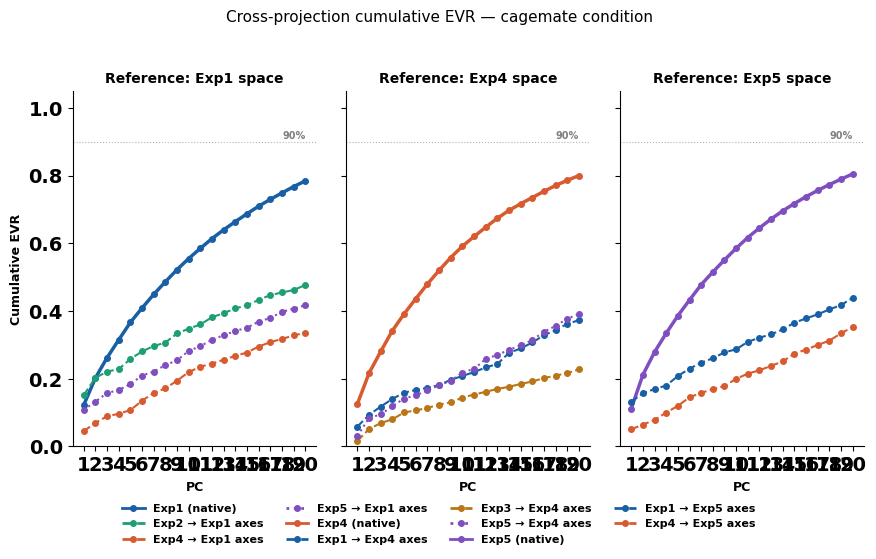

In [122]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def plot_cumulative_evr(
    evr_dict,
    n_pcs=10,
    figsize=(9, 5),
    save_path=None
):
    """
    Plot cumulative explained variance ratio for cross-projection PCA analysis.

    Parameters
    ----------
    evr_dict : dict
        Keys are (label, reference_space, linestyle, color) tuples.
        Values are 1D arrays of per-PC EVR.
        See example usage below.
    n_pcs : int
        Number of PCs to show on x-axis.
    figsize : tuple
    save_path : str or None
        If provided, saves the figure to this path.
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)
    ref_spaces = ['Exp1 space', 'Exp4 space', 'Exp5 space']

    for ax, ref in zip(axes, ref_spaces):
        for (label, space, ls, color), evr in evr_dict.items():
            if space != ref:
                continue
            cumevr = np.cumsum(evr[:n_pcs])
            pcs = np.arange(1, len(cumevr) + 1)
            lw = 2.5 if ls == '-' else 1.5
            ax.plot(pcs, cumevr, ls=ls, color=color, lw=lw, label=label,
                    marker='o', markersize=4)

        ax.set_title(f'Reference: {ref}', fontsize=10, pad=6)
        ax.set_xlabel('PC', fontsize=9)
        ax.set_xticks(np.arange(1, n_pcs + 1))
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_ylim(0, 1.05)
        ax.axhline(0.9, color='gray', lw=0.8, ls=':', alpha=0.6)
        ax.text(n_pcs, 0.91, '90%', fontsize=7, color='gray', ha='right')

    axes[0].set_ylabel('Cumulative EVR', fontsize=9)

    # Build a unified legend from all entries
    handles = []
    seen = set()
    for (label, space, ls, color), _ in evr_dict.items():
        if label not in seen:
            handles.append(
                mlines.Line2D([], [], color=color, ls=ls, lw=2,
                              marker='o', markersize=4, label=label)
            )
            seen.add(label)

    fig.legend(handles=handles, loc='lower center',
               ncol=min(len(handles), 4), fontsize=8,
               frameon=False, bbox_to_anchor=(0.5, -0.08))

    fig.suptitle('Cross-projection cumulative EVR — cagemate condition',
                 fontsize=11, y=1.01)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ── Plug in your computed arrays below ──────────────────────────────────────
# Color scheme: Exp1=blue, Exp2=teal, Exp3=amber, Exp4=coral, Exp5=purple
# Solid lines = native space; dashed = cross-projected

evr_dict = {
    # (label,              reference space, linestyle, color)
    ('Exp1 (native)',      'Exp1 space', '-',  '#185FA5'): pcaresult_exp1.explained_variance,
    ('Exp2 → Exp1 axes',   'Exp1 space', '--', '#1D9E75'): evr_exp2_on_exp1_axes,
    ('Exp4 → Exp1 axes',   'Exp1 space', '--', '#D85A30'): evr_exp4_on_exp1_axes,
    ('Exp5 → Exp1 axes',   'Exp1 space', ':',  '#7F4FBF'): evr_exp5_on_exp1_axes,

    ('Exp4 (native)',      'Exp4 space', '-',  '#D85A30'): pcaresult_exp4.explained_variance,
    ('Exp1 → Exp4 axes',   'Exp4 space', '--', '#185FA5'): evr_exp1_on_exp4_axes,
    ('Exp3 → Exp4 axes',   'Exp4 space', '--', '#BA7517'): evr_exp3_on_exp4_axes,
    ('Exp5 → Exp4 axes',   'Exp4 space', ':',  '#7F4FBF'): evr_exp5_on_exp4_axes,

    ('Exp5 (native)',      'Exp5 space', '-',  '#7F4FBF'): pcaresult_exp5.explained_variance,
    ('Exp1 → Exp5 axes',   'Exp5 space', '--', '#185FA5'): evr_exp1_on_exp5_axes,
    ('Exp4 → Exp5 axes',   'Exp5 space', '--', '#D85A30'): evr_exp4_on_exp5_axes,
}

plot_cumulative_evr(evr_dict, n_pcs=20)

# RSA

NOVEL
Skipping 33_nov_p1_merged.rec: 1 neurons < min_neurons=5


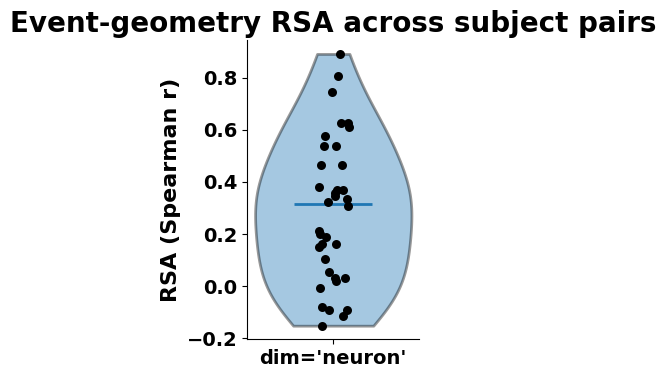

CAGEMATE
Skipping 31_cage_p1_merged.rec: 1 neurons < min_neurons=5
Skipping 33_cage_p1_merged.rec: 2 neurons < min_neurons=5


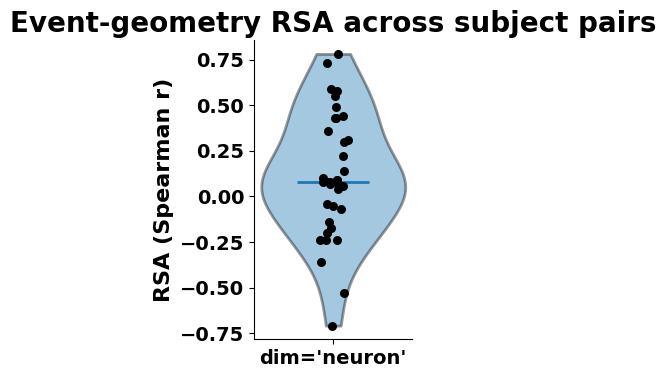

Skipping 33_nov_p1_merged.rec: 1 neurons < min_neurons=5


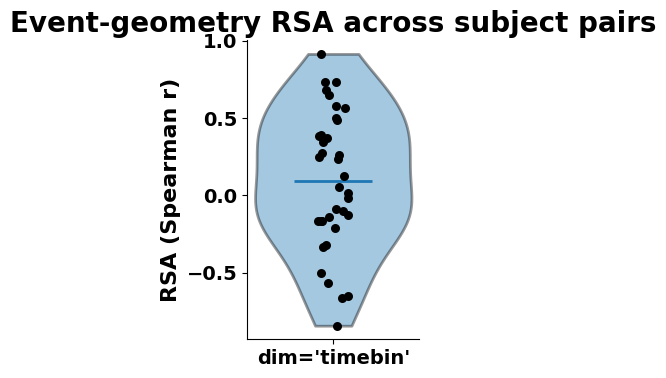

CAGEMATE
Skipping 31_cage_p1_merged.rec: 1 neurons < min_neurons=5
Skipping 33_cage_p1_merged.rec: 2 neurons < min_neurons=5


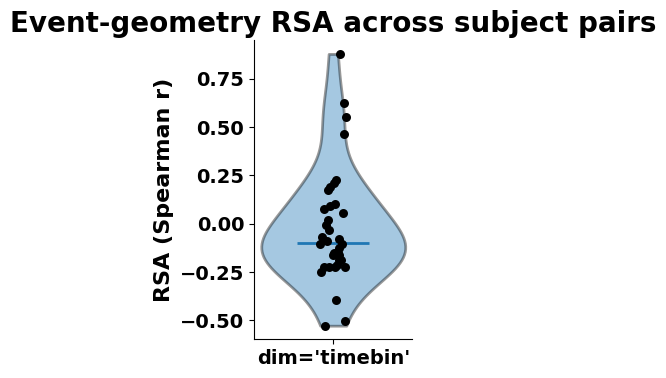

Skipping 33_nov_p1_merged.rec: 1 neurons < min_neurons=5


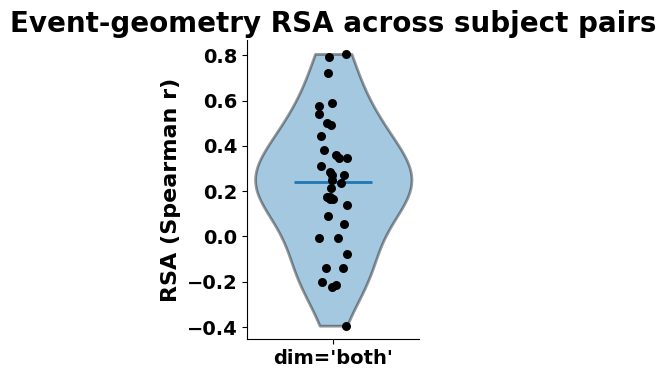

CAGEMATE
Skipping 31_cage_p1_merged.rec: 1 neurons < min_neurons=5
Skipping 33_cage_p1_merged.rec: 2 neurons < min_neurons=5


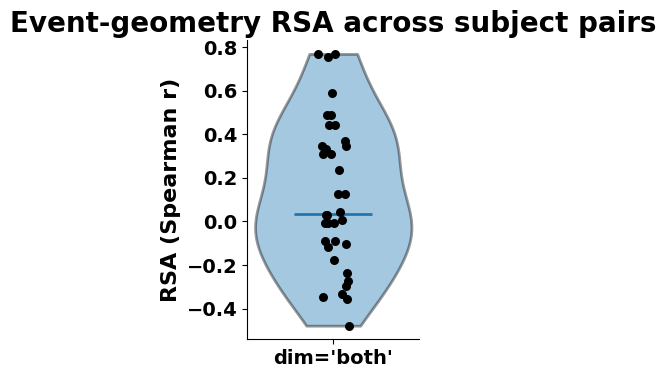

In [30]:
print("NOVEL")
from importlib import reload
reload(population_analysis)
r_n = population_analysis.rsa(novel_collection, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'], 
                       event_length = 3, pre_window = 1, plot = True, min_neurons = 5, dim = 'neuron')
print("CAGEMATE")
r_c = population_analysis.rsa(cagemate_collection, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'], 
                         event_length = 3, pre_window = 1, plot = True, min_neurons = 5, dim = 'neuron') 
dim = 'timebin'
r_n = population_analysis.rsa(novel_collection, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'], 
                       event_length = 3, pre_window = 1, plot = True, min_neurons = 5, dim = dim)
print("CAGEMATE")
r_c = population_analysis.rsa(cagemate_collection, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'], 
                         event_length = 3, pre_window = 1, plot = True, min_neurons = 5, dim = dim)
dim = 'both'
r_n = population_analysis.rsa(novel_collection, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'], 
                       event_length = 3, pre_window = 1, plot = True, min_neurons = 5, dim = dim)
print("CAGEMATE")
r_c = population_analysis.rsa(cagemate_collection, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'], 
                         event_length = 3, pre_window = 1, plot = True, min_neurons = 5, dim = dim)

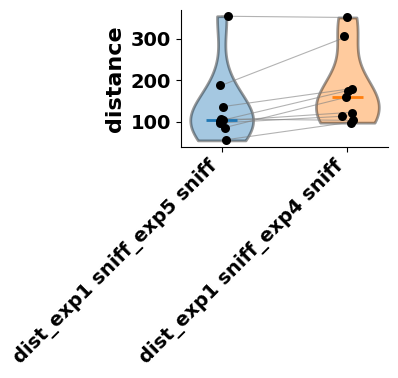

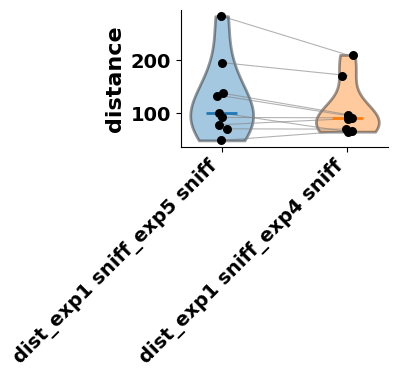

In [34]:
def plot_rsa_paired(df, col1, col2):                                                                                                                                                   
    vals1 = df[col1].values                                                                                                                                                            
    vals2 = df[col2].values                                                                                                                                                            
                                                                                                                                                                                        
    fig, ax = plt.subplots(figsize=(4, 4))                                                                                                                                             
                                                                                                                                                                                        
    for v1, v2 in zip(vals1, vals2):
        ax.plot([0, 1], [v1, v2], color="gray", linewidth=0.8, alpha=0.6, zorder=2)                                                                                                    
                                                                                                                                                                                    
    for pos, vals in zip([0, 1], [vals1, vals2]):
        parts = ax.violinplot(vals, positions=[pos], showmedians=True, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_alpha(0.4)
        jitter = np.random.uniform(-0.05, 0.05, size=len(vals))
        ax.scatter(jitter + pos, vals, color="black", s=20, zorder=3)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([col1, col2], rotation=45, ha="right")
    ax.set_ylabel("distance")
    plt.tight_layout()
    plt.show()

plot_rsa_paired(r_n, 'dist_exp1 sniff_exp5 sniff', 'dist_exp1 sniff_exp4 sniff')
plot_rsa_paired(r_c, 'dist_exp1 sniff_exp5 sniff', 'dist_exp1 sniff_exp4 sniff')

In [31]:
r_n.columns

Index(['subject', 'dist_exp1 sniff_exp2 sniff', 'dist_exp1 sniff_exp3 sniff',
       'dist_exp1 sniff_exp4 sniff', 'dist_exp1 sniff_exp5 sniff',
       'dist_exp2 sniff_exp3 sniff', 'dist_exp2 sniff_exp4 sniff',
       'dist_exp2 sniff_exp5 sniff', 'dist_exp3 sniff_exp4 sniff',
       'dist_exp3 sniff_exp5 sniff', 'dist_exp4 sniff_exp5 sniff',
       'full_rdm_vector'],
      dtype='object')

# dPCA

In [ ]:
def plot_explained_variance(explained_variance, n_components=10):
    import numpy as np
    import matplotlib.pyplot as plt

    # --- your explained variance dict looks something like this ---
    # explained_variance = {
    #     't':  [0.38, 0.11, 0.04, 0.02, ...],   # time
    #     'e':  [0.03, 0.01, 0.005, ...],          # event/stimulus
    #     'te': [0.09, 0.05, 0.02, ...],           # mixed interaction
    # }

    n_components = 10  # first 10 PCs to plot

    color_map = {
        't':  'mediumseagreen',   # time → green
        'e':  'steelblue',        # event → blue
        'te': 'darkgrey',         # mixed → grey
    }

    label_map = {
        't':  'Time',
        'e':  'Event',
        'te': 'Time × Event (mixed)',
    }

    # truncate or pad each list to n_components
    def get_values(lst, n):
        arr = np.array(lst[:n])          # take first n
        if len(arr) < n:                 # pad with zeros if shorter
            arr = np.pad(arr, (0, n - len(arr)))
        return arr

    x = np.arange(n_components)
    bar_width = 0.6

    fig, ax = plt.subplots(figsize=(10, 5))

    # plot order matters for stacking — draw bottom layers first
    # t at the base, then e on top, then te on top of that
    keys_ordered = ['t', 'e', 'te']
    bottoms = np.zeros(n_components)

    bars = {}
    for key in keys_ordered:
        if key not in explained_variance:
            continue
        vals = get_values(explained_variance[key], n_components)
        bars[key] = ax.bar(
            x,
            vals,
            bottom=bottoms,
            width=bar_width,
            color=color_map[key],
            label=label_map[key],
            edgecolor='white',
            linewidth=0.5,
        )
        bottoms += vals

    # formatting
    ax.set_xlabel('Component index', fontsize=12)
    ax.set_ylabel('Variance explained', fontsize=12)
    ax.set_title('dPCA — Variance Explained per Component', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([f'PC{i+1}' for i in range(n_components)], fontsize=9)
    ax.legend(loc='upper right', framealpha=0.9)
    ax.set_ylim(0, max(bottoms) * 1.15)   # 15% headroom above tallest bar
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))

    # optional: add total variance label on top of each bar
    for i, total in enumerate(bottoms):
        ax.text(i, total + max(bottoms) * 0.01, f'{total:.3f}',
                ha='center', va='bottom', fontsize=7, color='dimgrey')

    plt.tight_layout()
    plt.show()

In [ ]:
reload(population_analysis)
dPCAResult = population_analysis.run_dpca(novel_collection, events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'], event_length = 3, pre_window = 3, plot = True)
plot_explained_variance(dPCAResult.explained_variance, n_components=10)

In [ ]:
reload(population_analysis)
dpca_result_cagemate = population_analysis.run_dpca(cagemate_collection, events = ['exp1 sniff', 'exp2 sniff','exp3 sniff', 'exp4 sniff','exp5 sniff' ], event_length = 3, pre_window = 3, plot = True)
plot_explained_variance(dpca_result_cagemate.explained_variance, n_components=10)

# Decoders

In [3]:
import spike.spike_analysis.decoders as decoders 
events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff']


In [5]:
from matplotlib.patches import Patch
def plot_multiple_decoders(decoder_results, title, color_list, legend_titles, figsize, start=0, stop=None, ):
    bar_width = 0.2
    plt.figure(figsize=figsize)
    
    bar_position = 0  # Starting position for bars
    bar_centers = []  # Store center positions for labels
    j = 0
    
    # First, create bars without labels
    for key, results in decoder_results.results.items():
        
        total_event = decoder_results.event_length + decoder_results.post_window
        x = np.linspace(-decoder_results.pre_window, total_event, np.array(results.roc_auc).shape[0])
        
        if start is not None:
            plot_start = np.where(x >= start)[0][0]
        if stop is None:
            plot_stop = results.roc_auc.shape[0]
        if stop is not None:
            plot_stop = np.where(x <= stop)[0][-1] + 1
            
        rf_avg = np.mean(np.mean(results.roc_auc[start:stop], axis=0), axis=0)
        rf_sem = sem(np.mean(results.roc_auc[plot_start:plot_stop], axis=0))
        rf_shuffle_avg = np.mean(np.mean(results.roc_auc_shuffle[plot_start:plot_stop], axis=0), axis=0)
        rf_shuffle_sem = sem(np.mean(results.roc_auc_shuffle[plot_start:plot_stop], axis=0))
        
        # Plot bars without labels
        plt.bar(bar_position, rf_avg, bar_width, 
               yerr=rf_sem, capsize=5, color=color_list[j], 
               edgecolor='black', linewidth=2,
               error_kw={'elinewidth': 2, 'capthick': 2})
        plt.bar(bar_position + bar_width, rf_shuffle_avg, bar_width, 
               yerr=rf_shuffle_sem, capsize=5, color=color_list[j], 
               hatch='//', edgecolor='black', linewidth=2,
               error_kw={'elinewidth': 2, 'capthick': 2})
        
        # Store center position for this pair of bars
        bar_centers.append(bar_position + bar_width/2)
        
        bar_position += 0.6
        j += 1
    
    # Add centered labels under each pair of bars
    plt.xticks(bar_centers, legend_titles, fontsize=12)
    
    # Create custom legend for RF and RF Shuffle
    legend_elements = [
    #Patch(facecolor='grey', edgecolor='black', linewidth=2, label='Real'),
    Patch(facecolor='grey', edgecolor='black', linewidth=2, hatch='///', label='Shuffle')
    ]

    # Create the legend with modified properties
    leg = plt.legend(handles=legend_elements, bbox_to_anchor=(1, 1), 
                    frameon=False, fontsize=16)

# Adjust the size of the patches in the legend
    for patch in leg.get_patches():
        patch.set_height(15)  # Adjust this value to change height
        patch.set_y(0)
        patch.set_width(15) 
        patch.set_x(20)
    
    plt.ylim(0.4, 1)
    plt.ylabel('AUC', fontsize=18)
    plt.xticks(fontsize = 14)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_linewidth(2)
    plt.gca().spines['left'].set_linewidth(2)
    plt.title(title, fontsize=20, y = 1.1)
    plt.yticks(fontsize=14)
    plt.show()


## All exposures: Epochs and shuffle control exploration

In [ ]:
#RF Results
num_fold = 5
event_length = 3
pre_window = 2
post_window = 0
min_neurons = 5

cagemate_epoch_results = decoders.trial_decoder(cagemate_collection,
                                              num_fold = num_fold,
                                              events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff'],
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type='linear',
                                              plot = False)
novel_epoch_results = decoders.trial_decoder(novel_collection,
                                              num_fold = num_fold,
                                              events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff'],
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type='linear',
                                              plot = False)





Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons


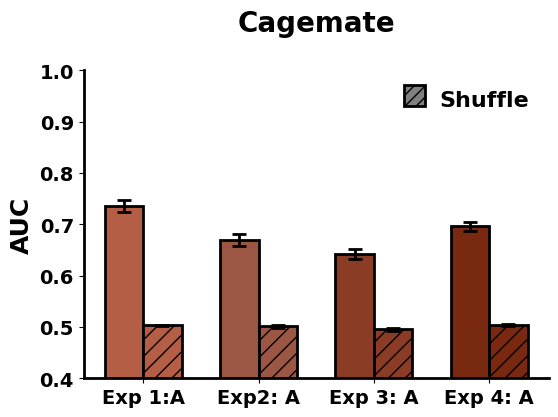

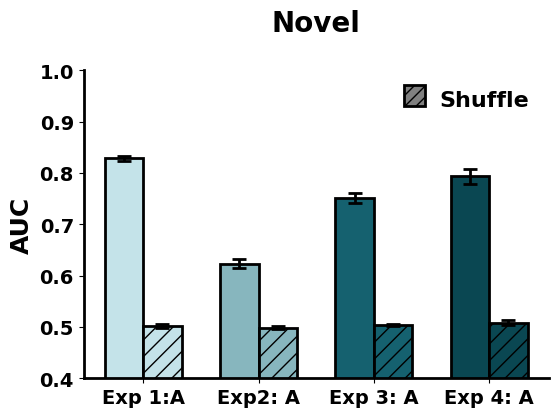

In [156]:
plot_multiple_decoders(cagemate_epoch_results, title = "Cagemate", color_list =["#B45F45", "#9B5743", "#8B3C24",'#792910'], start = 0 , stop = 3, 
                       legend_titles = ['Exp 1:A', 'Exp2: A', 'Exp 3: A', "Exp 4: A"], figsize = (6,4))
plot_multiple_decoders(novel_epoch_results, title = "Novel", color_list =["#C4E3E9","#87B6BE",'#15616F',"#0A4752"], start = 0 , stop = 3, 
                       legend_titles = ['Exp 1:A', 'Exp2: A', 'Exp 3: A', "Exp 4: A"], figsize = (6,4))

In [4]:

num_fold = 5
event_length = 3
pre_window = 2
post_window = 0
min_neurons = 5

events = ['exp1 sniff', 'exp5 sniff', 'exp4 sniff']
ccgp_results_cage_145 = decoders.trial_decoder_cross_generalization(cagemate_collection,
                                              num_fold = num_fold,
                                              events = events,
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear',
                                              LOO = True) 
ccgp_results_nov_145 = decoders.trial_decoder_cross_generalization(novel_collection,
                                              num_fold = num_fold,
                                              events = events,
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear',
                                              LOO = True) 
# print('cagemate')                                            
# ccgp_results_cage_145.plot_average()
# ccgp_results_cage_145.plot_across_time()
# print('novel')
# ccgp_results_nov_145.plot_average()
# ccgp_results_nov_145.plot_across_time()

Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons


Cross-generalization decoder | 9 folds
Variance threshold: 90%
  Trained on exp1 sniff_exp5 sniff [32 PCs]:
    → tested on exp1 sniff_exp5 sniff: avg AUC = 0.831
    → tested on exp1 sniff_exp4 sniff: avg AUC = 0.674
    → tested on exp5 sniff_exp4 sniff: avg AUC = 0.689
    → tested on exp1 sniff_exp5 sniff_shuffle: avg AUC = 0.500
  Trained on exp1 sniff_exp4 sniff [33 PCs]:
    → tested on exp1 sniff_exp4 sniff: avg AUC = 0.810
    → tested on exp1 sniff_exp5 sniff: avg AUC = 0.687
    → tested on exp4 sniff_exp5 sniff: avg AUC = 0.630
    → tested on exp1 sniff_exp4 sniff_shuffle: avg AUC = 0.499
  Trained on exp5 sniff_exp4 sniff [35 PCs]:
    → tested on exp5 sniff_exp4 sniff: avg AUC = 0.813
    → tested on exp5 sniff_exp1 sniff: avg AUC = 0.683
    → tested on exp4 sniff_exp1 sniff: avg AUC = 0.653
    → tested on exp5 sniff_exp4 sniff_shuffle: avg AUC = 0.497
Cross-generalization decoder | 9 folds
Variance threshold: 90%
  Trained on exp1 sniff_exp5 sniff [28 PCs]:
    → test

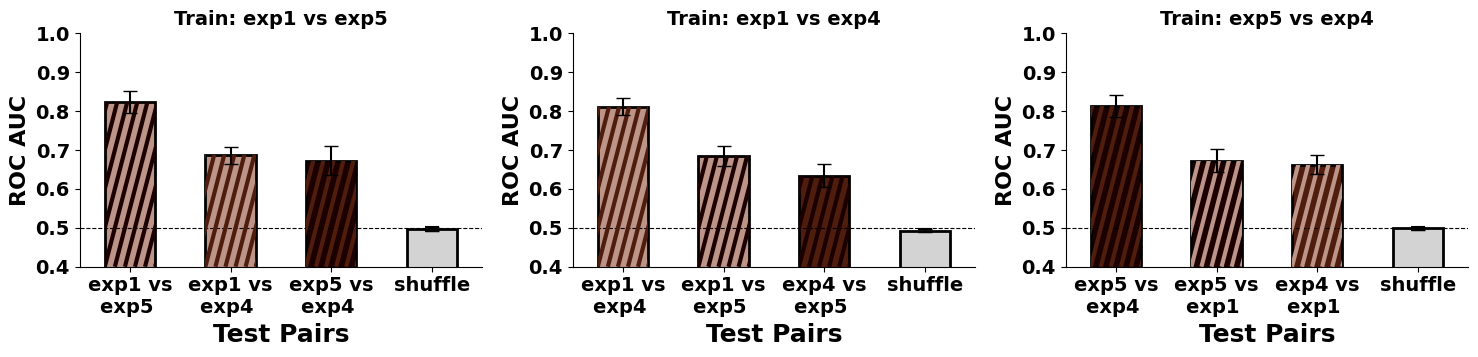

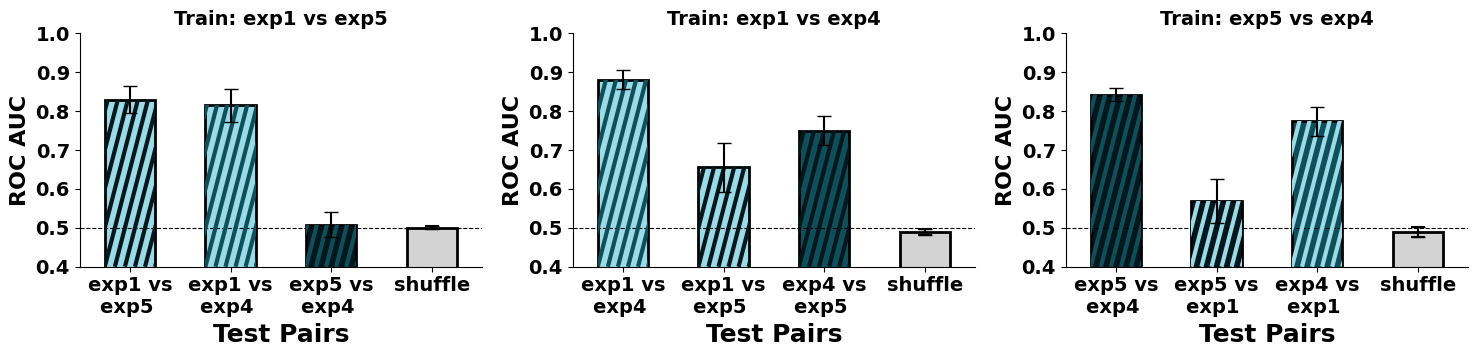

In [28]:
def plot_average(ccgp_results, color_dict, start=0, stop=None):
    """Bar plot of ROC AUC averaged over a time window.

    One subplot per training pair (3 total), three bars each — the trained pair
    (in-distribution) and the two generalization test cases. Bars are striped
    with the two colors of the tested pair. Shuffle bar is grey.

    Args:
        color_dict : dict mapping condition names to hex colors
                     e.g. {"cagemate": "#792910", "novel": "#15616F", "familiar": "#FFAF00"}
        start      : float, seconds from event onset to start averaging (default 0)
        stop       : float, seconds from event onset to stop averaging (default event_length)
    """

    def get_pair_colors(test_key, color_dict):
        for sep in [" vs ", "_vs_", " - ", "-", "_"]:
            if sep in test_key:
                parts = [p.strip() for p in test_key.split(sep, 1)]
                if len(parts) == 2:
                    return (color_dict.get(parts[0], "#888888"),
                            color_dict.get(parts[1], "#CCCCCC"))
        c = color_dict.get(test_key, "#888888")
        return c, "#CCCCCC"

    def striped_bar(ax, x, height, width, color1, color2,
                stripe_spacing=0.1, stripe_lw=3, yerr=None, capsize=5, y_min=0.4):
        import matplotlib.patches as patches

        ax.bar(x, height, width, color=color1, zorder=2)

        bar_left   = x - width / 2
        bar_height = height - y_min

        clip_rect = patches.Rectangle(
            (bar_left, y_min), width, bar_height,
            transform=ax.transData
        )
        ax.add_patch(clip_rect)
        clip_rect.set_visible(False)

        diag_extent = max(bar_height, width)
        xs = np.arange(bar_left - diag_extent, bar_left + width + diag_extent, stripe_spacing)
        for x_start in xs:
            line, = ax.plot(
                [x_start,              x_start + diag_extent],
                [y_min,                y_min + diag_extent],
                color=color2, lw=stripe_lw, zorder=3, solid_capstyle='butt'
            )
            line.set_clip_path(clip_rect)

        if yerr is not None:
            ax.errorbar(x, height, yerr=yerr,
                        fmt="none", color="black",
                        capsize=capsize, linewidth=1.5, zorder=5)

    train_keys = list(ccgp_results.roc_auc_scores.keys())
    fig, axes  = plt.subplots(1, len(train_keys),
                               figsize=(5 * len(train_keys), 4),
                               sharey=True)
    if len(train_keys) == 1:
        axes = [axes]

    for ax, train_key in zip(axes, train_keys):
        test_pairs  = ccgp_results.roc_auc_scores[train_key]
        test_keys   = list(test_pairs.keys())

        shuffle_key  = f"{train_key}_shuffle"
        display_keys = [k for k in test_keys if k != shuffle_key]
        ordered_keys = display_keys + ([shuffle_key] if shuffle_key in test_pairs else [])
        bar_labels   = display_keys + (["shuffle"]   if shuffle_key in test_pairs else [])

        means, errors = [], []
        for test_key in ordered_keys:
            nmr = test_pairs[test_key]
            x_time = np.linspace(
                -ccgp_results.pre_window,
                ccgp_results.event_length + ccgp_results.post_window,
                nmr.roc_auc.shape[0],
            )
            plot_start = np.where(x_time >= start)[0][0] if np.any(x_time >= start) else 0
            plot_stop  = (nmr.roc_auc.shape[0] if stop is None
                          else np.where(x_time <= stop)[0][-1] + 1)

            avg_per_fold = np.nanmean(nmr.roc_auc[plot_start:plot_stop], axis=0)
            means.append(np.nanmean(avg_per_fold))
            errors.append(sem(avg_per_fold, nan_policy="omit"))

        bar_width = 0.5
        for j, (test_key, mean, err, label) in enumerate(
                zip(ordered_keys, means, errors, bar_labels)):

            if test_key == shuffle_key:
                ax.bar(j, mean, bar_width, color="lightgray",
                       yerr=err, capsize=5,
                       error_kw={"elinewidth": 1.5, "capthick": 1.5},
                       zorder=2)
                ax.errorbar(j, mean, yerr=err, fmt="none", color="black",
                            capsize=5, linewidth=1.5, zorder=5)
            else:
                c1, c2 = get_pair_colors(test_key, color_dict)
                striped_bar(ax, j, mean, bar_width, c1, c2, yerr=err, y_min = 0.4)
        x_tick_labels = [label.replace('_', 'vs\n') for label in bar_labels]
        x_tick_labels = [label.replace('sniff', '') for label in x_tick_labels]
        ax.set_xticks(range(len(ordered_keys)))
        ax.set_xticklabels(x_tick_labels, rotation=0)
        ax.set_xlabel("Test Pairs", fontsize = 18)
        ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8)
        ax.set_ylim(0.4, 1.0)
        ax.set_xlim(-0.5, len(ordered_keys) - 0.5)
        ax.tick_params(axis='y', labelleft=True)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_ylabel("ROC AUC")
        ax.set_title(f"Train: {train_key.replace(' sniff','').replace('_', ' vs ')}", fontsize=14)

        # legend
        seen, patches = set(), []
        for test_key in display_keys:
            c1, c2 = get_pair_colors(test_key, color_dict)
            for sep in [" vs ", "_vs_", " - ", "-", "_"]:
                if sep in test_key:
                    parts = [p.strip() for p in test_key.split(sep, 1)]
                    for part, c in zip(parts, [c1, c2]):
                        if part not in seen:
                            patches.append(mpatches.Patch(color=c, label=part))
                            seen.add(part)
                    break
        patches.append(mpatches.Patch(color="lightgray", label="shuffle"))
        #ax.legend(handles=patches, fontsize=8, loc="upper right", framealpha=0.7)

    fig.suptitle("")
    plt.tight_layout()
    plt.show()

color_dict_cage = {
    "exp1 sniff": "#bc9488",
    "exp4 sniff":    "#4e1d0d",
    "exp5 sniff": "#1C0000"
}
color_dict_novel = {
    "exp1 sniff": "#9BDAE7",
    "exp4 sniff":    "#0D4F5B",
    "exp5 sniff": "#00181C"
}
print(ccgp_results_cage_145)
print(ccgp_results_nov_145)
plot_average(ccgp_results_cage_145, color_dict=color_dict_cage, start = 0 , stop=3)
plot_average(ccgp_results_nov_145, color_dict=color_dict_novel, start = 0 , stop=3)


Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
cagemate


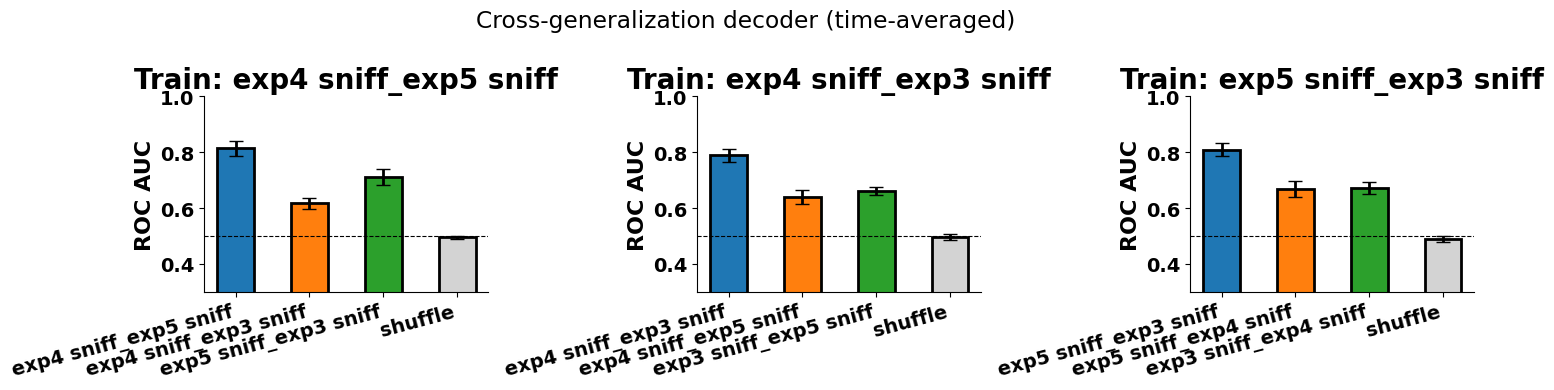

novel


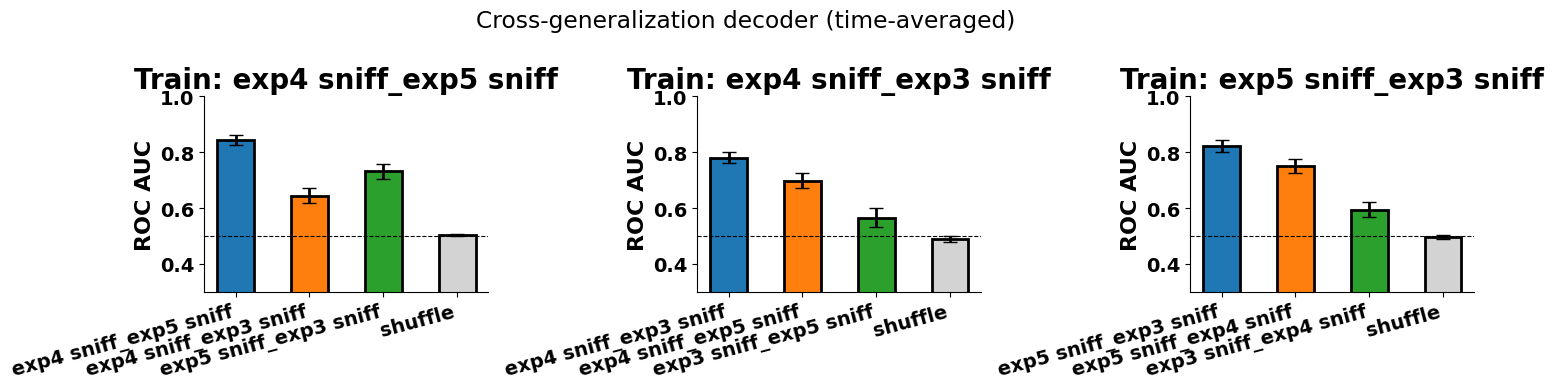

In [32]:
events = ['exp4 sniff', 'exp5 sniff', 'exp3 sniff']
ccgp_results_cage_145 = decoders.trial_decoder_cross_generalization(cagemate_collection,
                                              num_fold = num_fold,
                                              events = events,
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear',
                                              LOO = True) 
ccgp_results_nov_145 = decoders.trial_decoder_cross_generalization(novel_collection,
                                              num_fold = num_fold,
                                              events = events,
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear',
                                              LOO = True) 
print('cagemate')                                            
ccgp_results_cage_145.plot_average()
print('novel')
ccgp_results_nov_145.plot_average()

In [ ]:
#novelty is more robust than different identities of cagemates?

Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons


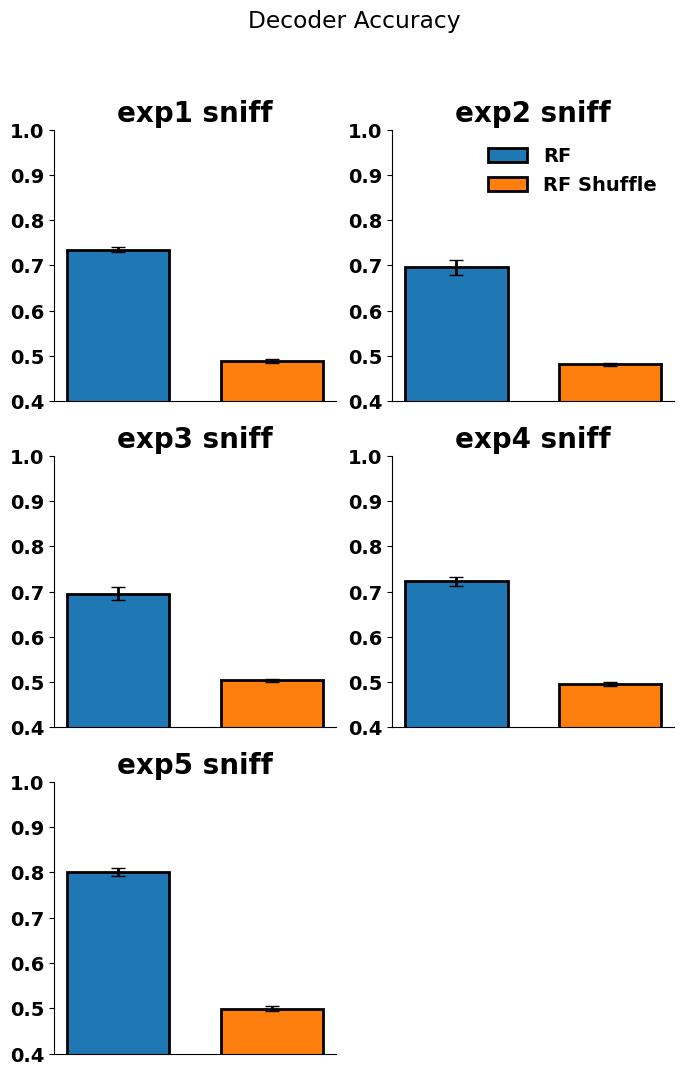

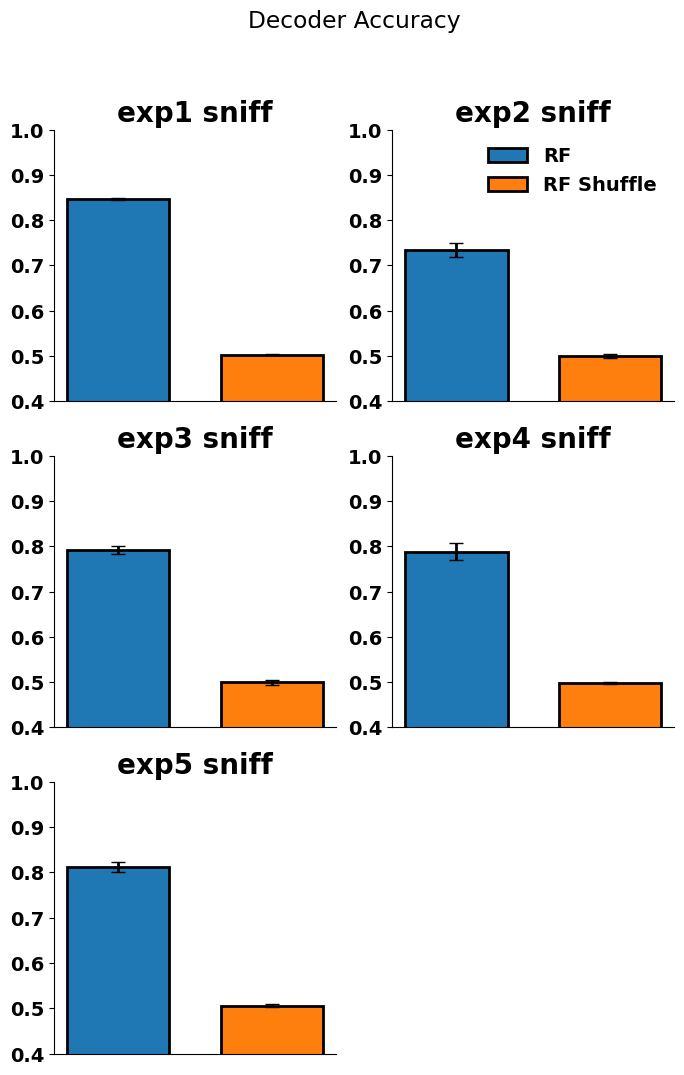

In [ ]:
#Linear Results
num_fold = 5
event_length = 3
pre_window = 2
post_window = 0
min_neurons = 5

cagemate_epoch_results = decoders.trial_decoder(cagemate_collection,
                                              num_fold = num_fold,
                                              events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'],
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear',
                                              plot = False)
novel_epoch_results = decoders.trial_decoder(novel_collection,
                                              num_fold = num_fold,
                                              events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'],
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear',
                                              plot = False)

cagemate_epoch_results.plot_average()
novel_epoch_results.plot_average()

### Full trial

In [ ]:
#RF FUll trial
num_fold = 5
event_length = 3
pre_window = 2
post_window = 0
min_neurons = 5

# cagemate_epoch_results = decoders.trial_decoder(cagemate_collection,
#                                               num_fold = num_fold,
#                                               no_PCs = 24,
#                                               events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'],
#                                               event_length = event_length,
#                                               pre_window = pre_window,
#                                               post_window = post_window,
#                                               min_neurons = min_neurons,
#                                               classifier_type = 'RF',
#                                               input = 'full_trail',
#                                               plot = False)
# novel_epoch_results = decoders.trial_decoder(novel_collection,
#                                               num_fold = num_fold,
#                                               no_PCs = 23,
#                                               events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'],
#                                               event_length = event_length,
#                                               pre_window = pre_window,
#                                               post_window = post_window,
#                                               min_neurons = min_neurons,
#                                               classifier_type = 'RF',
#                                               input= 'full_trail',
#                                               plot = False)

cagemate_epoch_results.plot_average()
novel_epoch_results.plot_average()

In [ ]:
# #RF Shuffle Results
# num_fold = 5
# event_length = 3
# pre_window = 2
# post_window = 0
# min_neurons = 5

# cagemate_epoch_results = decoders.trial_decoder_within_subject_shuffle(cagemate_collection,
#                                               num_fold = num_fold,
#                                               no_PCs = 24,
#                                               events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'],
#                                               event_length = event_length,
#                                               pre_window = pre_window,
#                                               post_window = post_window,
#                                               min_neurons = min_neurons,
#                                               perm_type = 'random',
#                                               plot = False)
# novel_epoch_results = decoders.trial_decoder_within_subject_shuffle(novel_collection,
#                                               num_fold = num_fold,
#                                               no_PCs = 23,
#                                               events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff'],
#                                               event_length = event_length,
#                                               pre_window = pre_window,
#                                               post_window = post_window,
#                                               min_neurons = min_neurons,
#                                               perm_type = 'random',
#                                               plot = False)

# cagemate_epoch_results.plot_average()
# novel_epoch_results.plot_average()

In [ ]:

num_fold = 5
event_length = 4
pre_window = 3
post_window = 0
min_neurons = 5


cagemate_1v4_results = decoders.trial_decoder(cagemate_collection,
                                              num_fold = num_fold,
                                              events = ['exp1 sniff', 'exp4 sniff'],
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear',
                                              plot = False)

cagemate_1v5_results = decoders.trial_decoder(cagemate_collection,
                                              num_fold = num_fold,
                                              events = ['exp1 sniff', 'exp5 sniff'],
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear',
                                              plot = False)

novel_1v4_results = decoders.trial_decoder(novel_collection,
                                              num_fold = num_fold,
                                              events = ['exp1 sniff', 'exp4 sniff'],
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear',
                                              plot = False)

novel_1v5_results = decoders.trial_decoder(novel_collection,
                                              num_fold = num_fold,
                                              events = ['exp1 sniff', 'exp5 sniff'],
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear',
                                              plot = False)

In [ ]:
plot_multiple_decoders([novel_1v4_results, cagemate_1v4_results, novel_1v5_results, cagemate_1v5_results], title = "Decoder Results", color_list = ['#3c1508','#3c1508','#15616F','#15616F'], start = 0 , stop = 3, legend_titles = ['Novel\n1vs4', 'Cagemate\n1vs4', 'Novel\n1vs5', 'Cagemate\n1vs5'], figsize = (6,4))
plot_multiple_decoders([cagemate_1v4_results, cagemate_1v5_results], title = "Cagemate Condition", color_list = ['#9b5f4c','#15616F'], start = 0 , stop = 3, legend_titles = ['Exposure 1vs4', 'Exposure 1vs5'], figsize = (4,4))

In [34]:
pre_window = 3
event_length = 4 
for recording in novel_collection.recordings:
    novel = np.concatenate([recording.event_dict['exp1 sniff'], recording.event_dict['exp3 sniff'], recording.event_dict['exp4 sniff'], recording.event_dict['exp2 sniff']], axis = 0)
    recording.event_dict['mouseA'] = novel
for recording in cagemate_collection.recordings:
    novel = np.concatenate([recording.event_dict['exp1 sniff'], recording.event_dict['exp3 sniff'], recording.event_dict['exp4 sniff'], recording.event_dict['exp2 sniff']], axis = 0)
    recording.event_dict['mouseA'] = novel
novel_novel_results = decoders.trial_decoder(novel_collection,
                                              num_fold = num_fold,
                                              events = ['mouseA', 'exp5 sniff'],
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear',
                                              LOO =True,
                                              plot = False)

cagemate_novel_results = decoders.trial_decoder(cagemate_collection,
                                              num_fold = num_fold,
                                              events = ['mouseA', 'exp5 sniff'],
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear',
                                              LOO = True,
                                              plot = False)
pre_window = 3
event_length = 4 





Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons


## CCGP for real

In [7]:
num_folds = 5
from importlib import reload
reload(decoders)
ccgp_object_cage = decoders.trial_decoder_cross_generalization_2x2(cagemate_collection, 
                                                events = [['exp1 sniff', 'exp2 sniff'], ['exp5 sniff', 'exp4 sniff']], 
                                                event_length = 3,
                                                pre_window = 4,
                                                min_neurons = 5,
                                                num_fold = num_folds,
                                                n_shuffles = 1,
                                                classifier_type = 'linear',
                                                LOO = True)
ccgp_object_novel = decoders.trial_decoder_cross_generalization_2x2(novel_collection, 
                                                events = [['exp1 sniff', 'exp2 sniff'], ['exp5 sniff', 'exp4 sniff']], 
                                                event_length = 3,
                                                pre_window = 4,
                                                min_neurons = 5,
                                                n_shuffles = 1,
                                                num_fold = num_folds,
                                                classifier_type = 'linear',
                                                LOO = True)
# ccgp_object_cage.plot_average()
# ccgp_object_novel.plot_average()

Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons


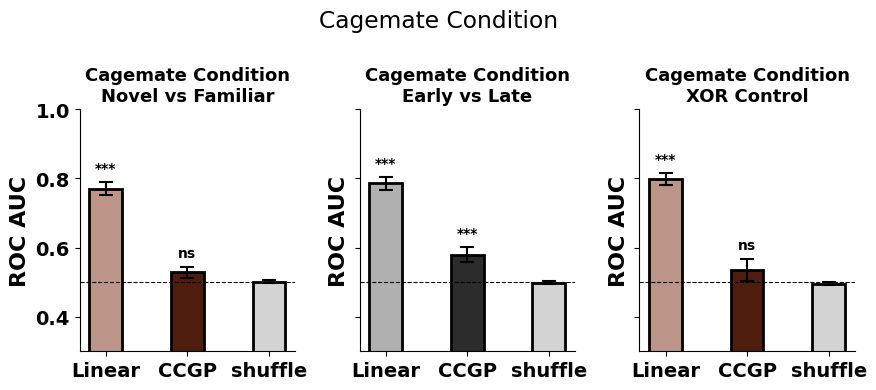

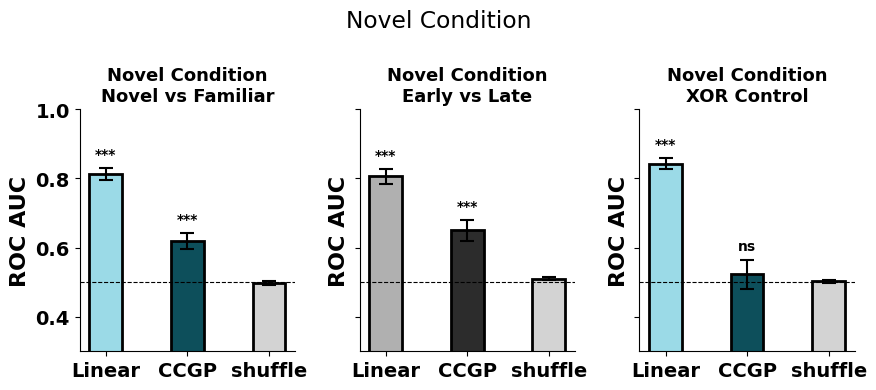

In [9]:
from scipy.stats import sem, ttest_ind                                                                                                                                                                                                                                                                                  
                                                                                                                                                                                                                                                                                                                          
def plot_average(ccgp_object, colors, start=0, stop=None, collapse=False,                                                                                                                                                                                                                                               
                titles=None, xtick_labels=None, suptitle=None):                                                                                                                                                                                                                                                                       
                                                                                                                                                                                                                                                                                                                    
    def sig_stars(p):
        if p < 0.001: return "***"
        elif p < 0.01:  return "**"
        elif p < 0.05:  return "*"
        else:           return "ns"

    def annotate_bars(ax, x_pos, means, errors, pvals):
        for xi, mean, err, p in zip(x_pos, means, errors, pvals):
            if p is not None:
                ax.text(xi, mean + err + 0.02, sig_stars(p),
                        ha="center", va="bottom", fontsize=10)

    def fold_array(nmr, start, stop, ccgp_object):
        T = nmr.roc_auc.shape[0]
        x = np.linspace(-ccgp_object.pre_window,
                        ccgp_object.event_length + ccgp_object.post_window, T)
        start_idx = np.searchsorted(x, start)
        stop_idx  = T if stop is None else np.searchsorted(x, stop)
        return np.nanmean(nmr.roc_auc[start_idx:stop_idx], axis=0)

    def mean_err(arr):
        clean = arr[~np.isnan(arr)]
        return np.nanmean(clean), sem(clean, nan_policy="omit")

    def vs_shuffle_p(arr, shuf_arr):
        a = arr[~np.isnan(arr)]
        b = shuf_arr[~np.isnan(shuf_arr)]
        _, p = ttest_ind(a, b, alternative="greater")
        return p

    train_keys  = list(ccgp_object.roc_auc_scores.keys())
    axis_groups = [train_keys[0:2], train_keys[2:4]]
    if len(train_keys) >= 6:
        axis_groups.append(train_keys[4:6])
    n_groups = len(axis_groups)

    bar_width = 0.4

    # ------------------------------------------------------------------ #
    #  COLLAPSE MODE                                                       #
    # ------------------------------------------------------------------ #
    if collapse:
        fig, axes = plt.subplots(1, n_groups, figsize=(3 * n_groups, 4), sharey=True)
        if n_groups == 1:
            axes = [axes]

        for ax_idx, (ax, group_keys, axis_colors) in enumerate(
                zip(axes, axis_groups, colors)):

            in_dist_folds   = []
            cross_gen_folds = []
            shuffle_folds   = []

            for train_key in group_keys:
                results = ccgp_object.roc_auc_scores[train_key]
                for result_type, nmr in results.items():
                    arr = fold_array(nmr, start, stop, ccgp_object)
                    if result_type == "in_dist":
                        in_dist_folds.append(arr)
                    elif result_type == "cross_gen":
                        cross_gen_folds.append(arr)
                    elif result_type == "shuffle":
                        shuffle_folds.append(arr)

            def pool(fold_list):
                return np.concatenate(fold_list) if fold_list else np.array([np.nan])

            in_arr    = pool(in_dist_folds)
            cross_arr = pool(cross_gen_folds)
            shuf_arr  = pool(shuffle_folds)

            in_mean,    in_err    = mean_err(in_arr)
            cross_mean, cross_err = mean_err(cross_arr)
            shuf_mean,  shuf_err  = mean_err(shuf_arr)

            means      = [in_mean,        cross_mean,    shuf_mean]
            errors     = [in_err,         cross_err,     shuf_err]
            pvals      = [vs_shuffle_p(in_arr, shuf_arr),
                        vs_shuffle_p(cross_arr, shuf_arr),
                        None]  # shuffle bar needs no annotation
            bar_colors = [axis_colors[0], axis_colors[1], "lightgray"]

            xlabels = xtick_labels[ax_idx] if xtick_labels is not None else ["in-dist", "cross-gen", "shuffle"]

            x_pos = np.arange(3)
            ax.bar(x_pos, means, bar_width, yerr=errors, capsize=5,
                    color=bar_colors,
                    error_kw={"elinewidth": 1.5, "capthick": 1.5})
            annotate_bars(ax, x_pos, means, errors, pvals)
            ax.set_xticks(x_pos)
            ax.set_xticklabels(xlabels, rotation=0, ha="center")
            ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8)
            ax.set_ylim(0.3, 1.0)
            ax.set_ylabel("ROC AUC")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            title = titles[ax_idx] if titles is not None else ("XOR" if ax_idx == 2 else f"Axis {ax_idx + 1}")
            ax.set_title(title, fontsize=13)

    # ------------------------------------------------------------------ #
    #  FULL MODE                                                           #
    # ------------------------------------------------------------------ #
    else:
        fig, axes_grid = plt.subplots(n_groups, 2, figsize=(10, 4 * n_groups), sharey=True)
        if n_groups == 1:
            axes_grid = axes_grid[np.newaxis, :]

        for axis_idx, (group_keys, axis_colors) in enumerate(
                zip(axis_groups, colors)):

            for subplot_idx, train_key in enumerate(group_keys):
                ax = axes_grid[axis_idx, subplot_idx]
                results = ccgp_object.roc_auc_scores[train_key]
                result_items = list(results.items())

                # get shuffle array first so we can test against it
                shuf_arr = next(
                    (fold_array(nmr, start, stop, ccgp_object)
                    for rt, nmr in result_items if rt == "shuffle"),
                    None
                )

                means, errors, pvals, bar_colors = [], [], [], []

                for j, (result_type, nmr) in enumerate(result_items):
                    arr = fold_array(nmr, start, stop, ccgp_object)
                    mean, err = mean_err(arr)
                    means.append(mean)
                    errors.append(err)

                    if result_type == "shuffle" or shuf_arr is None:
                        pvals.append(None)
                        bar_colors.append("lightgray")
                    else:
                        pvals.append(vs_shuffle_p(arr, shuf_arr))
                        bar_colors.append(axis_colors[0] if j == 0 else axis_colors[1])

                if xtick_labels is not None:
                    xlabels = list(xtick_labels[axis_idx][subplot_idx])
                    while len(xlabels) < len(result_items):
                        xlabels.append("shuffle")
                else:
                    xlabels = [rt for rt, _ in result_items]

                x_pos = np.arange(len(result_items))
                ax.bar(x_pos, means, bar_width, yerr=errors, capsize=5,
                        color=bar_colors,
                        error_kw={"elinewidth": 1.5, "capthick": 1.5})
                annotate_bars(ax, x_pos, means, errors, pvals)
                ax.set_xticks(x_pos)
                ax.set_xticklabels(xlabels, rotation=15, ha="center")
                ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8)
                ax.set_ylim(0.3, 1.0)
                ax.set_ylabel("ROC AUC")
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)

                if titles is not None:
                    title = titles[axis_idx][subplot_idx]
                else:
                    title = "XOR" if axis_idx == 2 else f"Axis {axis_idx+1}, subplot {subplot_idx+1}"
                ax.set_title(title, fontsize=12)
    if suptitle is None:
        suptitle = "2x2 Cross-generalization decoder (time-averaged)"
    plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

plot_average(ccgp_object_cage, 
             colors = [[hex_2_rgb('#bc9488'),hex_2_rgb("#4e1d0d")],
                       [hex_2_rgb("#b0b0b0"),hex_2_rgb("#2c2c2c")],
                       [hex_2_rgb('#bc9488'),hex_2_rgb("#4e1d0d")]],
                       start = 0 , stop =3, collapse = True,
             titles = ['Cagemate Condition\nNovel vs Familiar', 
                       'Cagemate Condition\nEarly vs Late', 
                       'Cagemate Condition\nXOR Control'],
             xtick_labels = [['Linear','CCGP', 'shuffle'],
                             ['Linear','CCGP', 'shuffle'],
                             ['Linear','CCGP', 'shuffle']],
             suptitle = 'Cagemate Condition')
plot_average(ccgp_object_novel, 
             colors = [[hex_2_rgb("#9BDAE7"),hex_2_rgb("#0D4F5B")],
                       [hex_2_rgb("#b0b0b0"),hex_2_rgb("#2c2c2c")],
                       [hex_2_rgb("#9BDAE7"),hex_2_rgb("#0D4F5B")]],
                       start = 0 , stop =3, collapse = True,
             titles = ['Novel Condition\nNovel vs Familiar',
                       'Novel Condition\nEarly vs Late',
                       'Novel Condition\nXOR Control'],
            xtick_labels = [['Linear','CCGP','shuffle'],
                            ['Linear','CCGP', 'shuffle'],
                            ['Linear','CCGP', 'shuffle']],
            suptitle = 'Novel Condition')

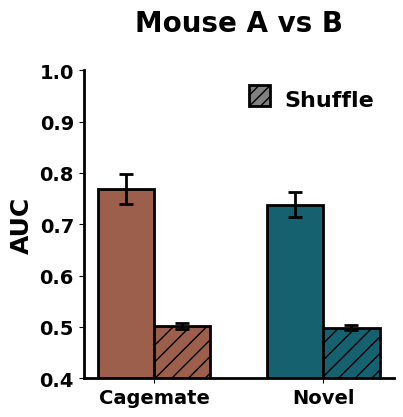

In [35]:
from matplotlib.patches import Patch
def plot_multiple_decoders(decoder_results, title, color_list, legend_titles, figsize, start=0, stop=None, ):
    bar_width = 0.2
    plt.figure(figsize=figsize)
    
    bar_position = 0  # Starting position for bars
    bar_centers = []  # Store center positions for labels
    j = 0
    
    # First, create bars without labels
    for decoder in decoder_results:
        key = list(decoder.results.keys())[0]
        results = list(decoder.results.values())[0]
        
        total_event = decoder.event_length + decoder.post_window
        x = np.linspace(-decoder.pre_window, total_event, np.array(results.roc_auc).shape[0])
        
        if start is not None:
            plot_start = np.where(x >= start)[0][0]
        if stop is None:
            plot_stop = results.roc_auc.shape[0]
        if stop is not None:
            plot_stop = np.where(x <= stop)[0][-1] + 1
            
        rf_avg = np.mean(np.mean(results.roc_auc[start:stop], axis=0), axis=0)
        rf_sem = sem(np.mean(results.roc_auc[plot_start:plot_stop], axis=0))
        rf_shuffle_avg = np.mean(np.mean(results.roc_auc_shuffle[plot_start:plot_stop], axis=0), axis=0)
        rf_shuffle_sem = sem(np.mean(results.roc_auc_shuffle[plot_start:plot_stop], axis=0))
        
        # Plot bars without labels
        plt.bar(bar_position, rf_avg, bar_width, 
               yerr=rf_sem, capsize=5, color=color_list[j], 
               edgecolor='black', linewidth=2,
               error_kw={'elinewidth': 2, 'capthick': 2})
        plt.bar(bar_position + bar_width, rf_shuffle_avg, bar_width, 
               yerr=rf_shuffle_sem, capsize=5, color=color_list[j], 
               hatch='//', edgecolor='black', linewidth=2,
               error_kw={'elinewidth': 2, 'capthick': 2})
        
        # Store center position for this pair of bars
        bar_centers.append(bar_position + bar_width/2)
        
        bar_position += 0.6
        j += 1
    
    # Add centered labels under each pair of bars
    plt.xticks(bar_centers, legend_titles, fontsize=12)
    
    # Create custom legend for RF and RF Shuffle
    legend_elements = [
    #Patch(facecolor='grey', edgecolor='black', linewidth=2, label='RF'),
    Patch(facecolor='grey', edgecolor='black', linewidth=2, hatch='///', label='Shuffle')
    ]

    # Create the legend with modified properties
    leg = plt.legend(handles=legend_elements, bbox_to_anchor=(1, 1), 
                    frameon=False, fontsize=16)

# Adjust the size of the patches in the legend
    for patch in leg.get_patches():
        patch.set_height(15)  # Adjust this value to change height
        patch.set_y(0)
        patch.set_width(15) 
        patch.set_x(20)
    
    plt.ylim(0.4, 1)
    plt.ylabel('AUC', fontsize=18)
    plt.xticks(fontsize = 14)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_linewidth(2)
    plt.gca().spines['left'].set_linewidth(2)
    plt.title(title, fontsize=20, y = 1.1)
    plt.yticks(fontsize=14)
    plt.show()

#plot_multiple_decoders([cagemate_novel_results_rf, novel_novel_results_rf], title = "Mouse A vs B: Random Forest", color_list = ['#9b5f4c','#15616F'], start = 0 , stop = 3, legend_titles = ['Cagemate', 'Novel'], figsize = (4,4))
plot_multiple_decoders([cagemate_novel_results, novel_novel_results], title = "Mouse A vs B", color_list = ['#9b5f4c','#15616F'], start = 0 , stop = 3, legend_titles = ['Cagemate', 'Novel'], figsize = (4,4))

Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons


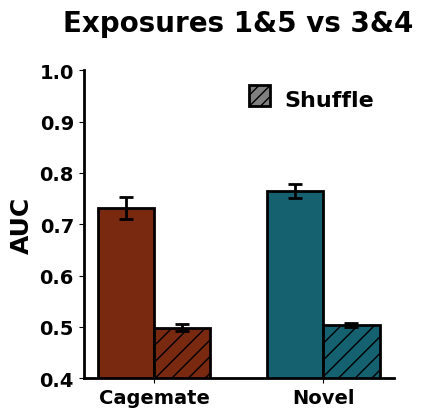

In [45]:
pre_window = 3
event_length = 4 
for recording in novel_collection.recordings:
    novel = np.concatenate([recording.event_dict['exp1 sniff'], recording.event_dict['exp5 sniff']], axis = 0)
    recording.event_dict['novel'] = novel
    not_novel = np.concatenate([recording.event_dict['exp3 sniff'], recording.event_dict['exp4 sniff']], axis = 0)
    recording.event_dict['not_novel'] = not_novel
for recording in cagemate_collection.recordings:
    novel = np.concatenate([recording.event_dict['exp1 sniff'], recording.event_dict['exp5 sniff']], axis = 0)
    recording.event_dict['novel'] = novel
    not_novel = np.concatenate([recording.event_dict['exp3 sniff'], recording.event_dict['exp4 sniff']], axis = 0)
    recording.event_dict['not_novel'] = not_novel
novel_novel_results = decoders.trial_decoder(novel_collection,
                                              num_fold = num_fold,
                                              events = ['novel', 'not_novel'],
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear',
                                              LOO =True,
                                              plot = False)

cagemate_novel_results = decoders.trial_decoder(cagemate_collection,
                                              num_fold = num_fold,
                                              events = ['novel', 'not_novel'],
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear',
                                              LOO = True,
                                              plot = False)

plot_multiple_decoders([cagemate_novel_results,novel_novel_results], title = "Exposures 1&5 vs 3&4", color_list = ['#792910','#15616F'], start = 0 , stop = 3, legend_titles = ['Cagemate', 'Novel'], figsize = (4,4))

NOVEL
Skipping 33_nov_p1_merged.rec: 1 neurons < min_neurons=3


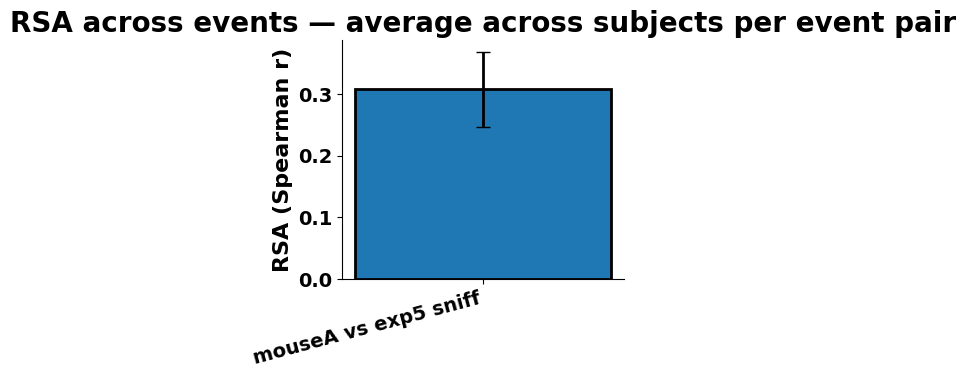

CAGEMATE
Skipping 31_cage_p1_merged.rec: 1 neurons < min_neurons=3
Skipping 33_cage_p1_merged.rec: 2 neurons < min_neurons=3


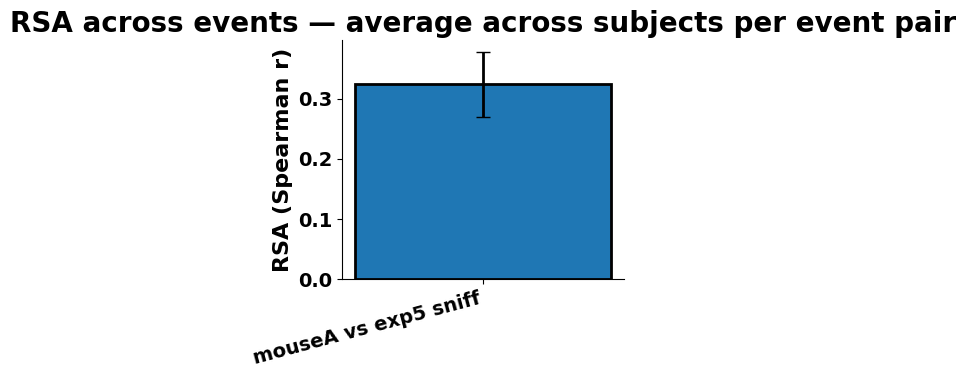

In [40]:
print("NOVEL")
r_n = population_analysis.rsa(novel_collection, events = ['mouseA', 'exp5 sniff'], 
                        across_events=True, event_length = 3, pre_window = 1, plot = True)
                        #, n_perm = 1000, correction = 'fdr_bh')
print("CAGEMATE")
r_c = population_analysis.rsa(cagemate_collection, events = ['mouseA', 'exp5 sniff'], 
                        across_events=True, event_length = 3, pre_window = 1, plot = True)
                        #, n_perm = 1000, correction = 'fdr_bh')

Skipping 31_cage_p1_merged.rec: 1 neurons < min_neurons=5
Skipping 33_cage_p1_merged.rec: 2 neurons < min_neurons=5
Skipping 33_nov_p1_merged.rec: 1 neurons < min_neurons=5


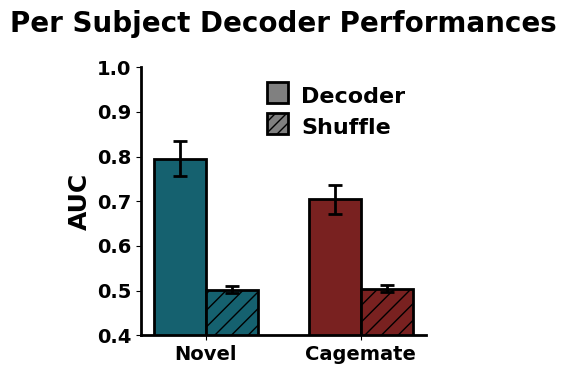

In [ ]:
from matplotlib.patches import Patch                                                                                                                                                                                                                                                         
num_fold = 5
event_length = 3
pre_window = 2
post_window = 0
min_neurons = 5
cagemate_results = decoders.trial_decoder_per_recording(cagemate_collection, num_fold = num_fold, no_PCs = 10, events = ['exp1 sniff', 'exp5 sniff'], event_length = event_length, 
                                                        pre_window = pre_window, post_window = post_window, 
                                                        min_neurons = min_neurons, classifier_type='linear')
novel_results = decoders.trial_decoder_per_recording(novel_collection, num_fold = num_fold, no_PCs = 10, events = ['exp1 sniff', 'exp5 sniff'], event_length = event_length, 
                                                        pre_window = pre_window, post_window = post_window,
                                                        min_neurons = min_neurons, classifier_type='linear')
def plot_multiple_per_recording_decoders(decoder_results, title, color_list, legend_titles, figsize, start=0, stop=None):                                                                                                                                                                    
      bar_width = 0.2
      plt.figure(figsize=figsize)                                                                                                                                                                                                                                                              
      bar_position = 0                                                                                                                                                                                                                                                                       
      bar_centers = []

      for j, decoder in enumerate(decoder_results):
          sample_res = next(iter(decoder.results.values()))
          event = sample_res.events[0]
          event_length = sample_res.event_length
          pre_window = sample_res.pre_window
          post_window = sample_res.post_window

          curves = decoder._collect_auc_across_recordings(event)
          shuffle_curves = decoder._collect_shuffle_across_recordings(event)
          if curves.size == 0:
              continue

          x = np.linspace(-pre_window, event_length + post_window, curves.shape[1])
          start_idx = np.searchsorted(x, start)
          stop_idx = curves.shape[1] if stop is None else np.searchsorted(x, stop)

          epoch_auc = np.nanmean(curves[:, start_idx:stop_idx], axis=1)
          epoch_shuf = np.nanmean(shuffle_curves[:, start_idx:stop_idx], axis=1)
          epoch_auc = epoch_auc[~np.isnan(epoch_auc)]
          epoch_shuf = epoch_shuf[~np.isnan(epoch_shuf)]
          n = len(epoch_auc)

          rf_avg = np.mean(epoch_auc)
          rf_sem = sem(epoch_auc)
          shuf_avg = np.mean(epoch_shuf)
          shuf_sem = sem(epoch_shuf)

          plt.bar(bar_position, rf_avg, bar_width,
                  yerr=rf_sem, capsize=5, color=color_list[j],
                  edgecolor='black', linewidth=2,
                  error_kw={'elinewidth': 2, 'capthick': 2})
          plt.bar(bar_position + bar_width, shuf_avg, bar_width,
                  yerr=shuf_sem, capsize=5, color=color_list[j],
                  hatch='//', edgecolor='black', linewidth=2,
                  error_kw={'elinewidth': 2, 'capthick': 2})

          bar_centers.append(bar_position + bar_width / 2)
          bar_position += 0.6
          j += 1

      plt.xticks(bar_centers, [f"{t}\n(n={len(next(iter(d.results.values())).events)})" for t, d in zip(legend_titles, decoder_results)], fontsize=12)

      # show n per bar label instead
      plt.xticks(bar_centers, legend_titles, fontsize=12)

      legend_elements = [
          Patch(facecolor='grey', edgecolor='black', linewidth=2, label='Decoder'),
          Patch(facecolor='grey', edgecolor='black', linewidth=2, hatch='///', label='Shuffle')
      ]
      leg = plt.legend(handles=legend_elements, bbox_to_anchor=(1, 1), frameon=False, fontsize=16)
      for patch in leg.get_patches():
          patch.set_height(15)
          patch.set_y(0)
          patch.set_width(15)
          patch.set_x(20)

      plt.ylim(0.4, 1)
      plt.ylabel('AUC', fontsize=18)
      plt.xticks(fontsize=14)
      plt.yticks(fontsize=14)
      plt.gca().spines['top'].set_visible(False)
      plt.gca().spines['right'].set_visible(False)
      plt.gca().spines['bottom'].set_linewidth(2)
      plt.gca().spines['left'].set_linewidth(2)
      plt.title(title, fontsize=20, y=1.1)
      plt.tight_layout()
      plt.show()

 
plot_multiple_per_recording_decoders(
    [novel_results, cagemate_results],
    title="Per Subject Decoder Performances",
    color_list=['#15616F', '#792120'],
    legend_titles=['Novel', 'Cagemate'],
    figsize=(4, 4),
    start=0, stop=3
)



## Smoothing window exploration


In [ ]:

num_fold = 5
event_length = 5
pre_window = 2
post_window = 0
min_neurons = 5
results = {}
smoothing_windows = [None, 100, 250, 350, 500, 700, 1000]
timebins = [100]
for smoothing_window in smoothing_windows:
    results[smoothing_window] = {}
    for timebin in timebins:
        cagemate_collection.analyze(smoothing_window=smoothing_window, timebin=timebin, ignore_freq=0.5)
        novel_collection.analyze(smoothing_window=smoothing_window, timebin=timebin, ignore_freq=0.5)

        events = ['exp1 sniff', 'exp5 sniff', 'exp4 sniff']
        ccgp_results_cage_145 = decoders.trial_decoder_cross_generalization(cagemate_collection,
                                                    num_fold = num_fold,
                                                    events = events,
                                                    event_length = event_length,
                                                    pre_window = pre_window,
                                                    post_window = post_window,
                                                    min_neurons = min_neurons,
                                                    classifier_type = 'linear') 
        ccgp_results_nov_145 = decoders.trial_decoder_cross_generalization(novel_collection,
                                                    num_fold = num_fold,
                                                    events = events,
                                                    event_length = event_length,
                                                    pre_window = pre_window,
                                                    post_window = post_window,
                                                    min_neurons = min_neurons,
                                                    classifier_type = 'linear')
        results[smoothing_window][timebin] = (ccgp_results_cage_145, ccgp_results_nov_145)
    
# print('cagemate')                  
# ccgp_results_cage_145.plot_average()
# ccgp_results_cage_145.plot_across_time()
# print('novel')
# ccgp_results_nov_145.plot_average()
# ccgp_results_nov_145.plot_across_time()

All set to analyze
All set to analyze
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
All set to analyze
All set to analyze
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
All set to analyze
All set to analyze
Excluding 31_cage_p1_merged.rec with 1 neurons

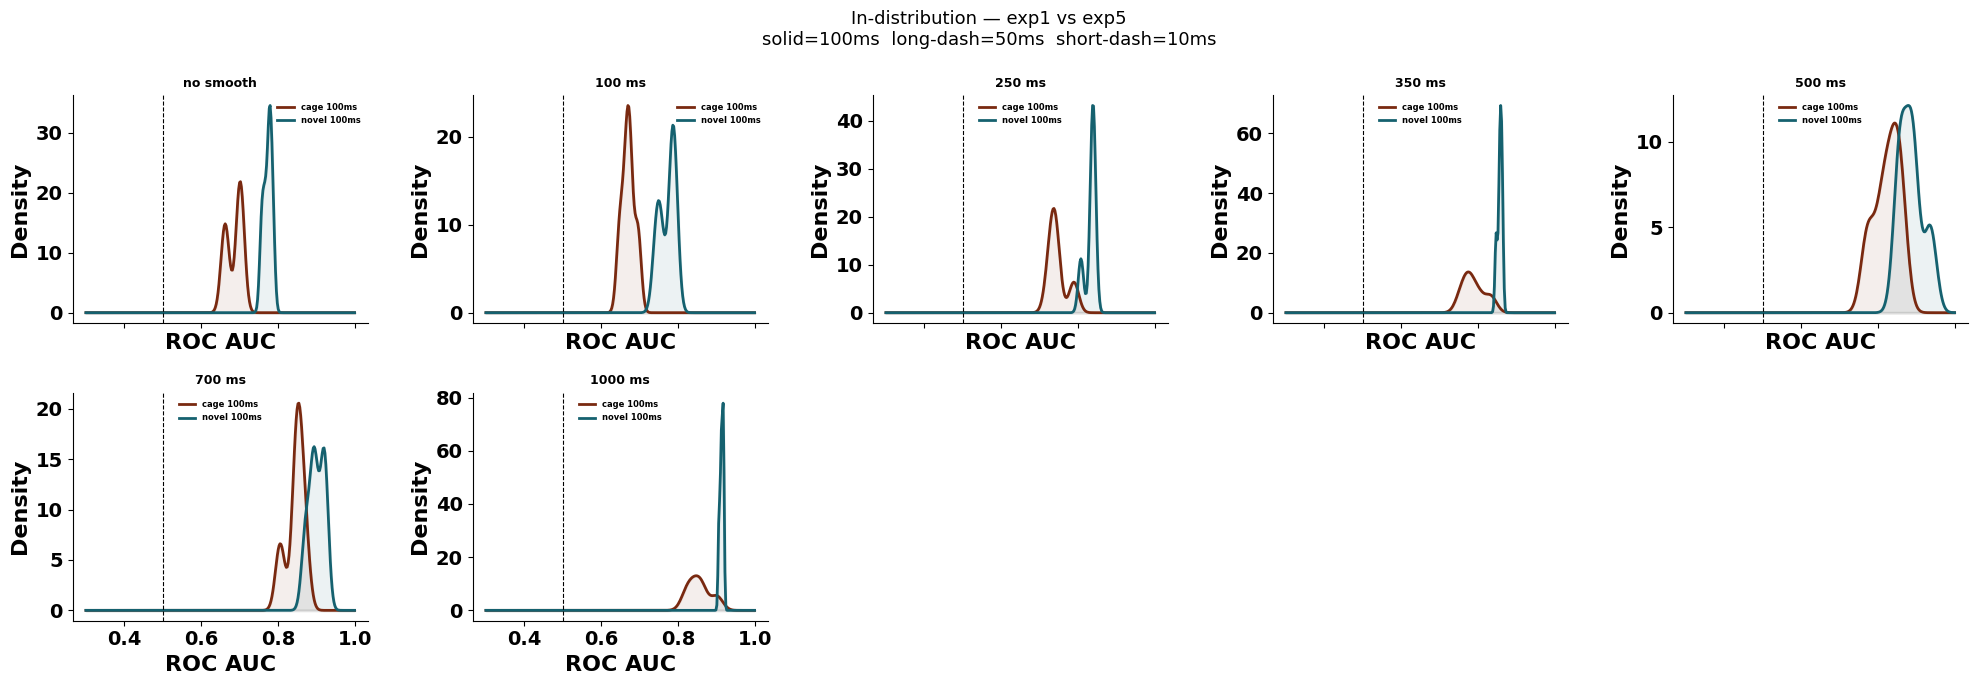

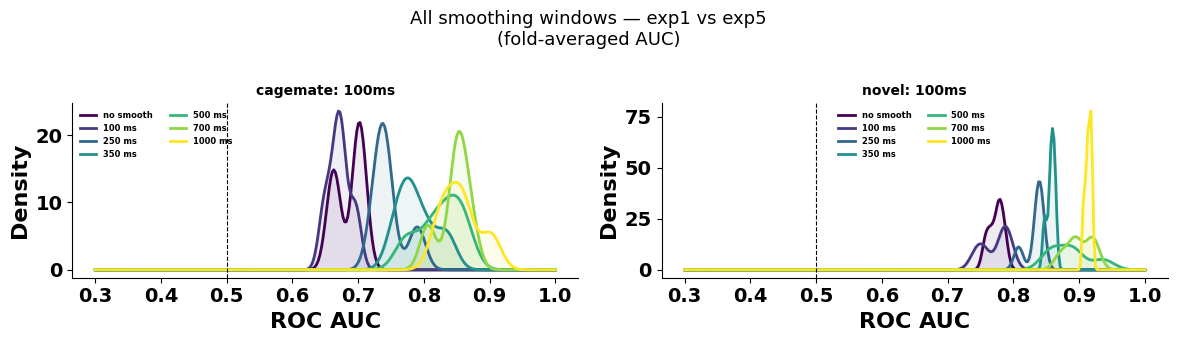

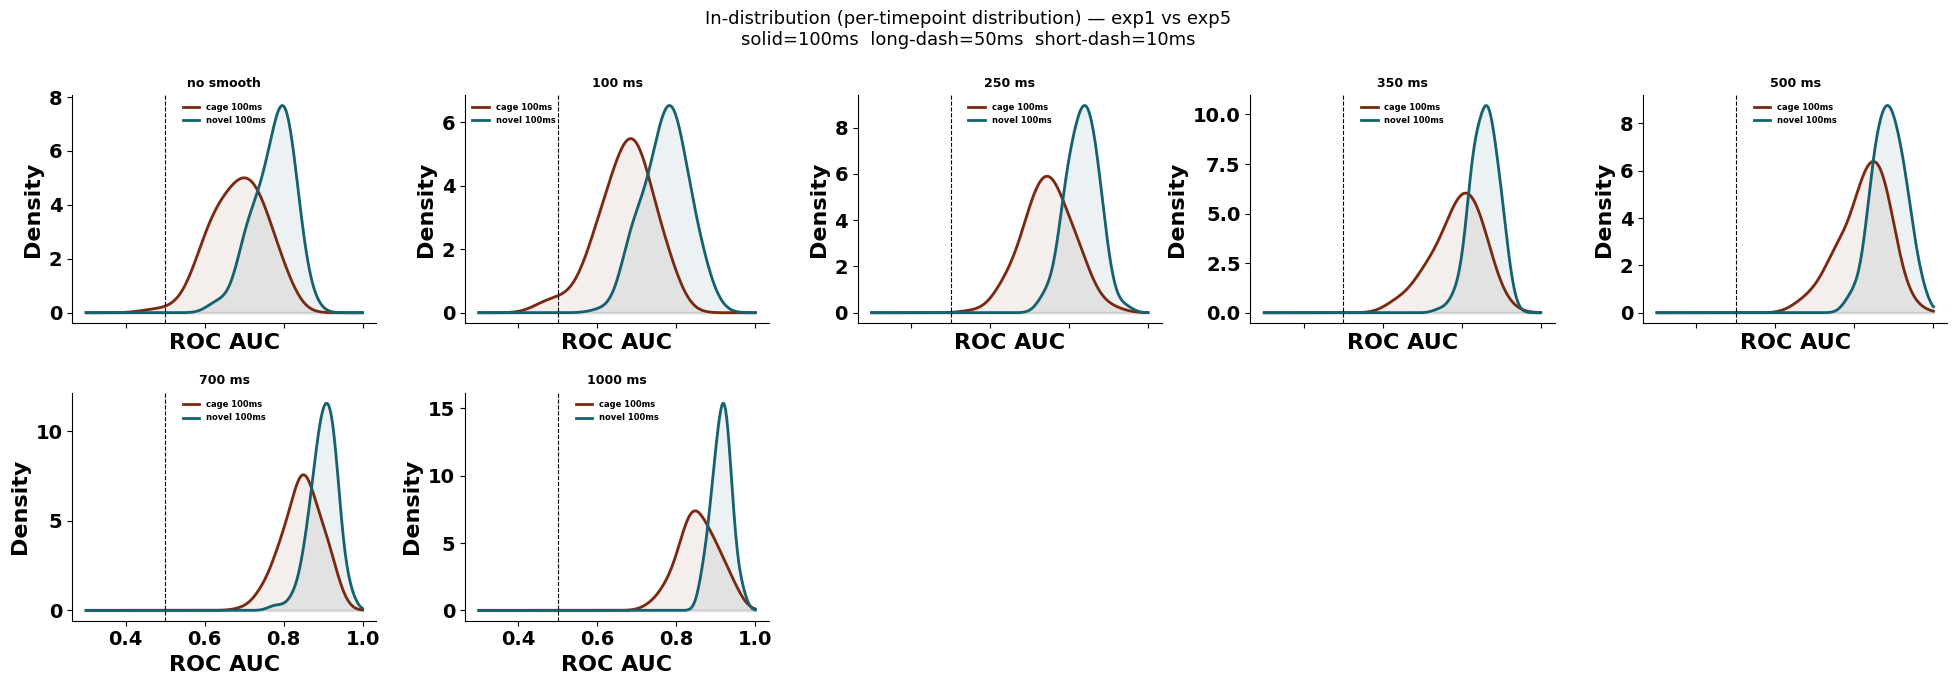

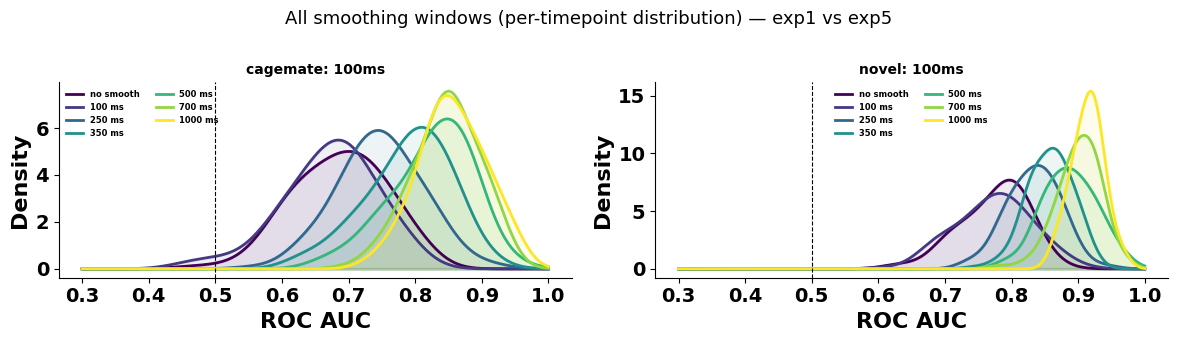

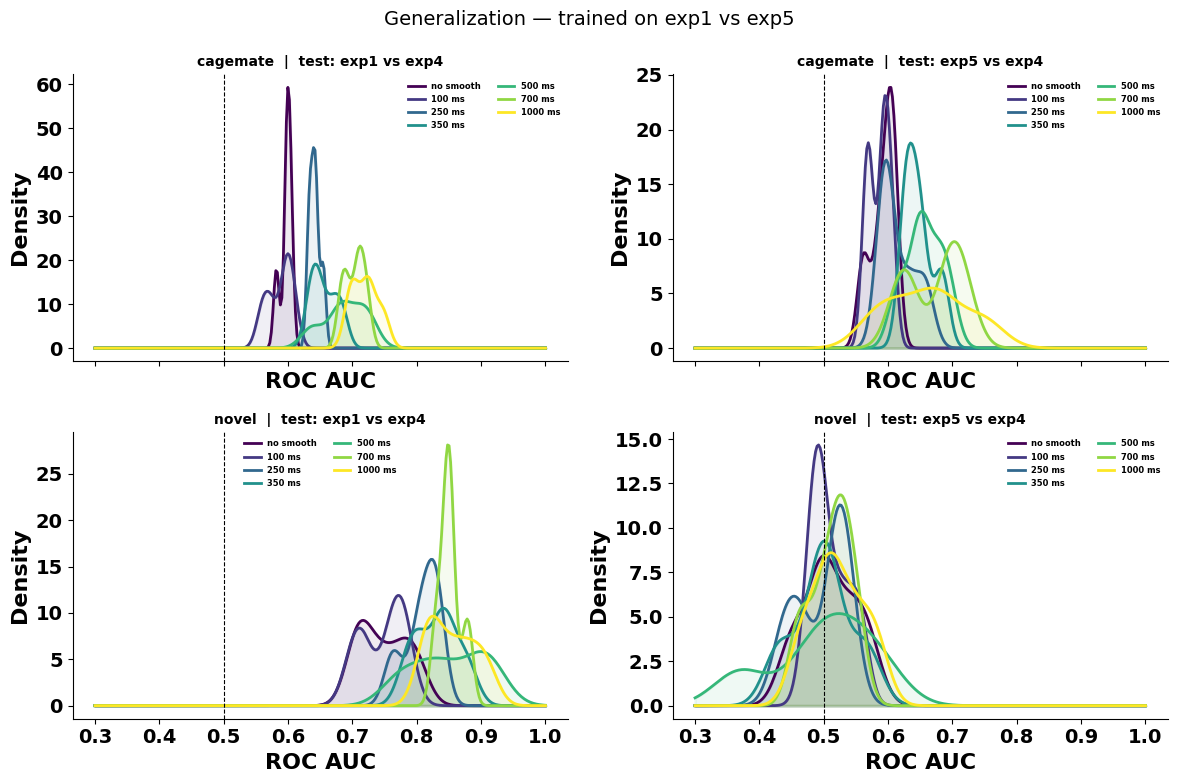

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, sem

# ── helpers ───────────────────────────────────────────────────────────────────

def get_auc_values(ccgp_result, train_key, test_key, start=0, stop=3):
    nmr = ccgp_result.roc_auc_scores[train_key][test_key]
    x_time = np.linspace(
        -ccgp_result.pre_window,
        ccgp_result.event_length + ccgp_result.post_window,
        nmr.roc_auc.shape[0],
    )
    t0 = np.where(x_time >= start)[0][0]
    t1 = np.where(x_time <= stop)[0][-1] + 1
    return np.nanmean(nmr.roc_auc[t0:t1], axis=0)

def get_auc_flat(ccgp_result, train_key, test_key, start=0, stop=3):
    nmr = ccgp_result.roc_auc_scores[train_key][test_key]
    x_time = np.linspace(
        -ccgp_result.pre_window,
        ccgp_result.event_length + ccgp_result.post_window,
        nmr.roc_auc.shape[0],
    )
    t0 = np.where(x_time >= start)[0][0]
    t1 = np.where(x_time <= stop)[0][-1] + 1
    return nmr.roc_auc[t0:t1].flatten()

def kde_plot(ax, values, color, label, bw=0.5, linestyle='-', dash_pattern=None):
    values = values[~np.isnan(values)]
    if len(values) < 2:
        return
    kde  = gaussian_kde(values, bw_method=bw)
    xs   = np.linspace(0.3, 1.0, 300)
    dens = kde(xs)
    line, = ax.plot(xs, dens, color=color, label=label, linewidth=2,
                    linestyle=linestyle)
    if dash_pattern is not None:
        line.set_dashes(dash_pattern)
    ax.fill_between(xs, dens, alpha=0.08, color=color)

def get_keys(ccgp_result, train_key):
    all_test_keys = list(ccgp_result.roc_auc_scores[train_key].keys())
    shuffle_key   = f"{train_key}_shuffle"
    real_keys     = [k for k in all_test_keys if k != shuffle_key]
    in_dist       = [k for k in real_keys if k == train_key]
    gen_keys      = [k for k in real_keys if k != train_key]
    return in_dist[0], gen_keys

def format_key(k):
    return k.replace('_', ' vs ').replace(' sniff', '')

def style_ax(ax):
    ax.axvline(0.5, color='k', linestyle='--', linewidth=0.8)
    ax.set_xlabel('ROC AUC')
    ax.set_ylabel('Density')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── constants ─────────────────────────────────────────────────────────────────

TRAIN_KEY   = 'exp1 sniff_exp5 sniff'
START, STOP = 0, 3
CAGE_COLOR  = '#792910'
NOV_COLOR   = '#15616F'

# linestyle + dash pattern per timebin
# 10ms: very short dashes, 50ms: medium dashes, 100ms: solid
TIMEBIN_STYLE = {
    #10:  ('--', (2, 4)),    # very short dashes
    #50:  ('--', (6, 3)),    # medium dashes
    100: ('-',  None),      # solid
}

timebins = [100]   # updated

sw_list   = smoothing_windows
cmap      = plt.cm.viridis
sw_colors = {sw: cmap(i / max(len(sw_list) - 1, 1))
             for i, sw in enumerate(sw_list)}

_, gen_keys = get_keys(results[sw_list[0]][timebins[0]][0], TRAIN_KEY)
gen_keys    = gen_keys[:2]

conditions = [('cagemate', 0, CAGE_COLOR), ('novel', 1, NOV_COLOR)]

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — one subplot per smoothing window
#          cage vs novel × 3 timebins
# ─────────────────────────────────────────────────────────────────────────────

n_sw  = len(sw_list)
ncols = 5
nrows = int(np.ceil(n_sw / ncols))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 4, nrows * 3.5),
                         sharex=True, sharey=False)
axes = axes.flatten()
fig.suptitle(f'In-distribution — {format_key(TRAIN_KEY)}\n'
             f'solid=100ms  long-dash=50ms  short-dash=10ms', fontsize=13)

for i, sw in enumerate(sw_list):
    ax = axes[i]
    for tb in timebins:
        ls, dp = TIMEBIN_STYLE[tb]
        try:
            cage_result, nov_result = results[sw][tb]
            in_dist_key, _          = get_keys(cage_result, TRAIN_KEY)
        except (KeyError, IndexError):
            continue
        kde_plot(ax, get_auc_values(cage_result, TRAIN_KEY, in_dist_key, START, STOP),
                 CAGE_COLOR, f'cage {tb}ms', linestyle=ls, dash_pattern=dp)
        kde_plot(ax, get_auc_values(nov_result,  TRAIN_KEY, in_dist_key, START, STOP),
                 NOV_COLOR,  f'novel {tb}ms', linestyle=ls, dash_pattern=dp)
    style_ax(ax)
    ax.set_title(f'{sw} ms' if sw is not None else 'no smooth', fontsize=9)
    ax.legend(fontsize=6, framealpha=0.7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2 — 2 cols (condition) × 3 rows (timebin)
#          all smoothing windows per subplot
#          subtitle: "{condition}: {timebin}ms"
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(len(timebins), len(conditions),
                           figsize=(12, len(timebins) * 3.5),
                           sharex=True, sharey=False, squeeze=False)
fig.suptitle(f'All smoothing windows — {format_key(TRAIN_KEY)}\n'
             f'(fold-averaged AUC)', fontsize=13)

for row, tb in enumerate(timebins):
    ls, dp = TIMEBIN_STYLE[tb]
    for col, (cond_name, result_idx, cond_color) in enumerate(conditions):
        ax = axes[row][col]
        for sw in sw_list:
            try:
                ccgp           = results[sw][tb][result_idx]
                in_dist_key, _ = get_keys(ccgp, TRAIN_KEY)
            except (KeyError, IndexError):
                continue
            label = f'{sw} ms' if sw is not None else 'no smooth'
            kde_plot(ax, get_auc_values(ccgp, TRAIN_KEY, in_dist_key, START, STOP),
                     sw_colors[sw], label, linestyle=ls, dash_pattern=dp)
        style_ax(ax)
        ax.set_title(f'{cond_name}: {tb}ms', fontsize=10)
        ax.legend(fontsize=6, framealpha=0.7, ncol=2)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1b — flat version of plot 1 (per-timepoint × folds)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 4, nrows * 3.5),
                         sharex=True, sharey=False)
axes = axes.flatten()
fig.suptitle(f'In-distribution (per-timepoint distribution) — {format_key(TRAIN_KEY)}\n'
             f'solid=100ms  long-dash=50ms  short-dash=10ms', fontsize=13)

for i, sw in enumerate(sw_list):
    ax = axes[i]
    for tb in timebins:
        ls, dp = TIMEBIN_STYLE[tb]
        try:
            cage_result, nov_result = results[sw][tb]
            in_dist_key, _          = get_keys(cage_result, TRAIN_KEY)
        except (KeyError, IndexError):
            continue
        kde_plot(ax, get_auc_flat(cage_result, TRAIN_KEY, in_dist_key, START, STOP),
                 CAGE_COLOR, f'cage {tb}ms', linestyle=ls, dash_pattern=dp)
        kde_plot(ax, get_auc_flat(nov_result,  TRAIN_KEY, in_dist_key, START, STOP),
                 NOV_COLOR,  f'novel {tb}ms', linestyle=ls, dash_pattern=dp)
    style_ax(ax)
    ax.set_title(f'{sw} ms' if sw is not None else 'no smooth', fontsize=9)
    ax.legend(fontsize=6, framealpha=0.7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 4 — flat version of plot 2: 2 cols × 3 rows, all smoothing windows
#          subtitle: "{condition}: {timebin}ms"
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(len(timebins), len(conditions),
                           figsize=(12, len(timebins) * 3.5),
                           sharex=True, sharey=False, squeeze=False)
fig.suptitle(f'All smoothing windows (per-timepoint distribution) — {format_key(TRAIN_KEY)}',
             fontsize=13)

for row, tb in enumerate(timebins):
    ls, dp = TIMEBIN_STYLE[tb]
    for col, (cond_name, result_idx, cond_color) in enumerate(conditions):
        ax = axes[row][col]
        for sw in sw_list:
            try:
                ccgp           = results[sw][tb][result_idx]
                in_dist_key, _ = get_keys(ccgp, TRAIN_KEY)
            except (KeyError, IndexError):
                continue
            label = f'{sw} ms' if sw is not None else 'no smooth'
            kde_plot(ax, get_auc_flat(ccgp, TRAIN_KEY, in_dist_key, START, STOP),
                     sw_colors[sw], label, linestyle=ls, dash_pattern=dp)
        style_ax(ax)
        ax.set_title(f'{cond_name}: {tb}ms', fontsize=10)
        ax.legend(fontsize=6, framealpha=0.7, ncol=2)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3 — unchanged, 100ms timebin only
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
fig.suptitle(f'Generalization — trained on {format_key(TRAIN_KEY)}', fontsize=14)

for row, (cond_name, result_idx, _) in enumerate(conditions):
    for col, gen_key in enumerate(gen_keys):
        ax = axes[row][col]
        for sw in sw_list:
            try:
                ccgp = results[sw][100][result_idx]
                vals = get_auc_values(ccgp, TRAIN_KEY, gen_key, START, STOP)
            except KeyError:
                continue
            kde_plot(ax, vals, sw_colors[sw],
                     f'{sw} ms' if sw is not None else 'no smooth')
        style_ax(ax)
        ax.set_title(f'{cond_name}  |  test: {format_key(gen_key)}', fontsize=10)
        ax.legend(fontsize=6, framealpha=0.7, ncol=2)

plt.tight_layout()
plt.show()

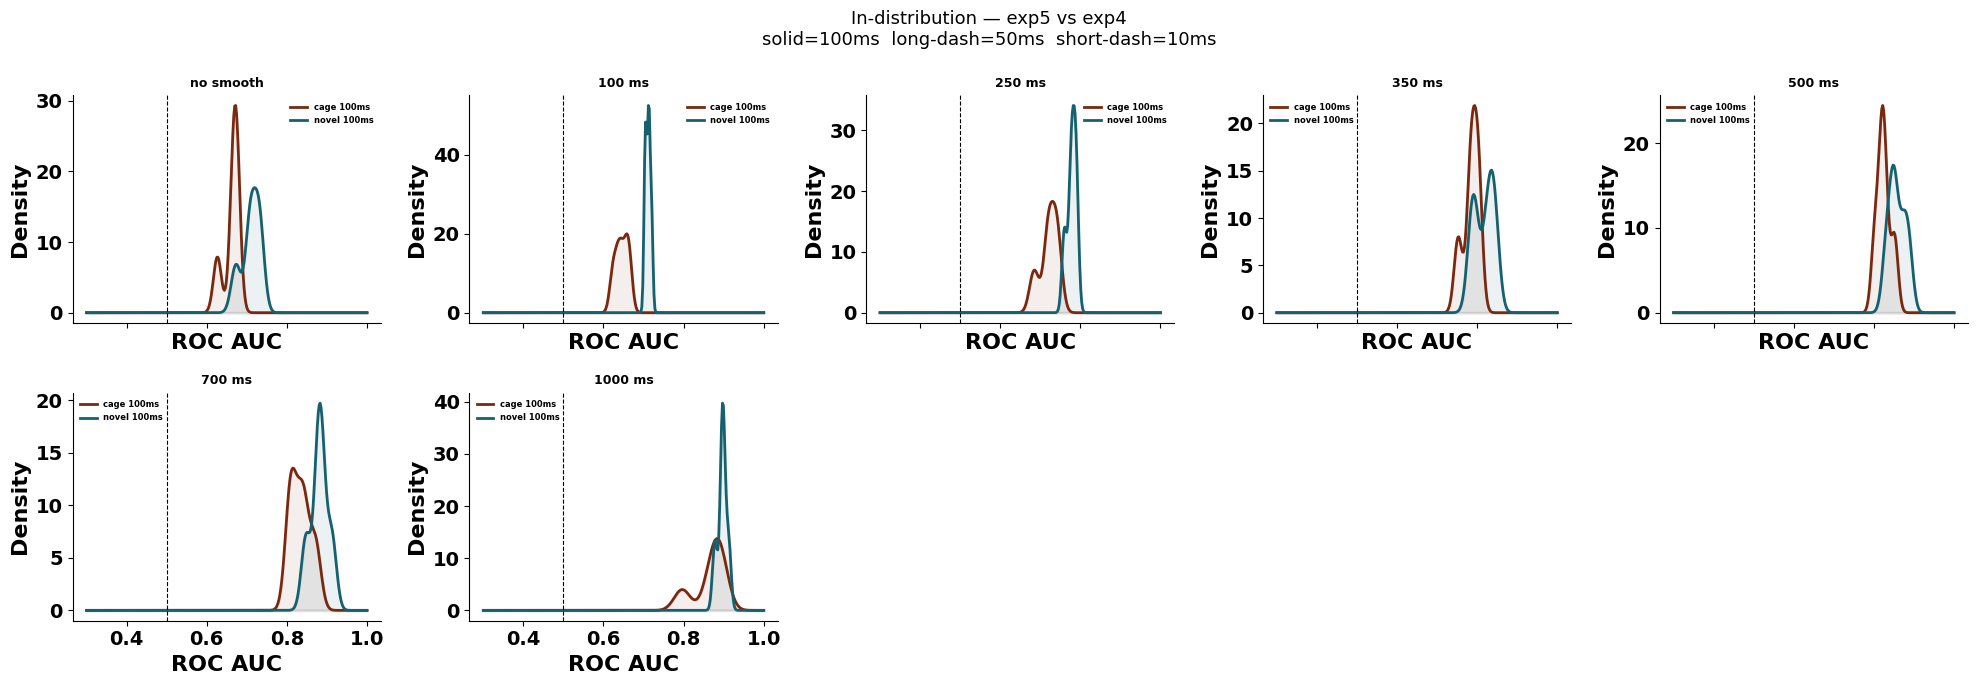

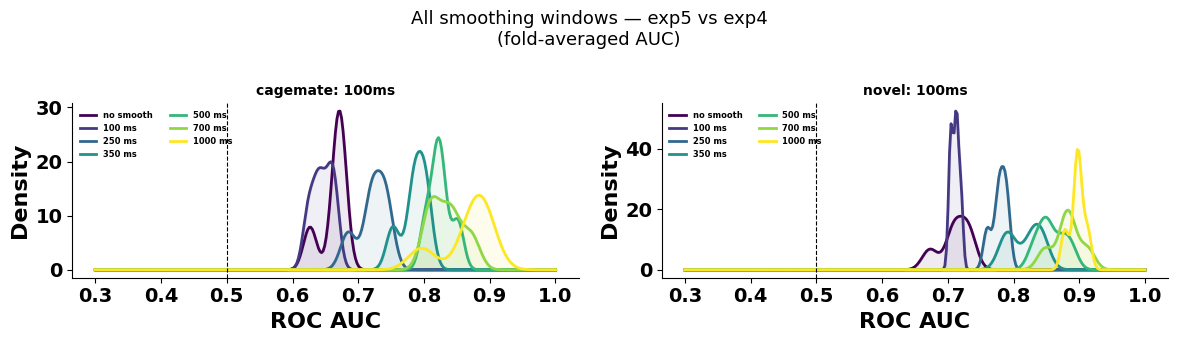

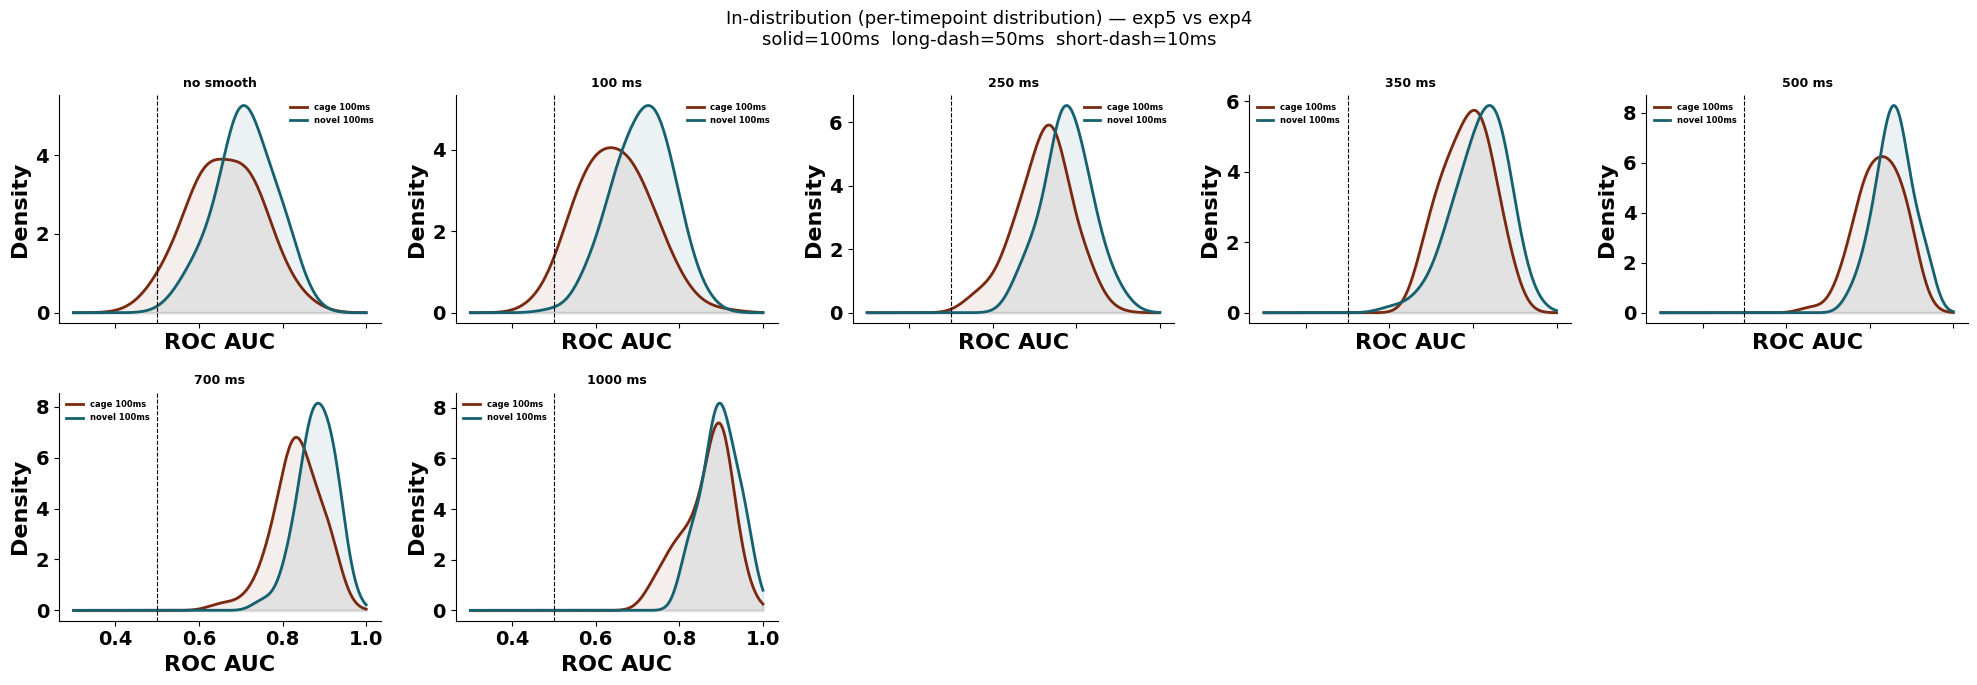

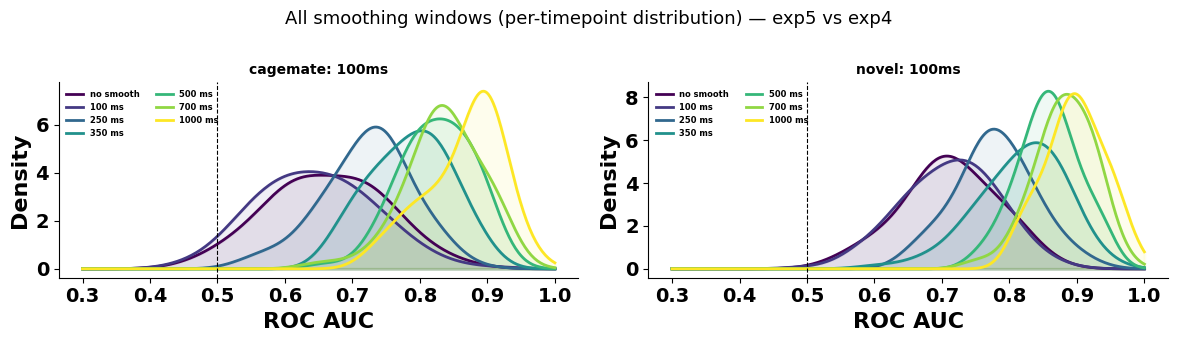

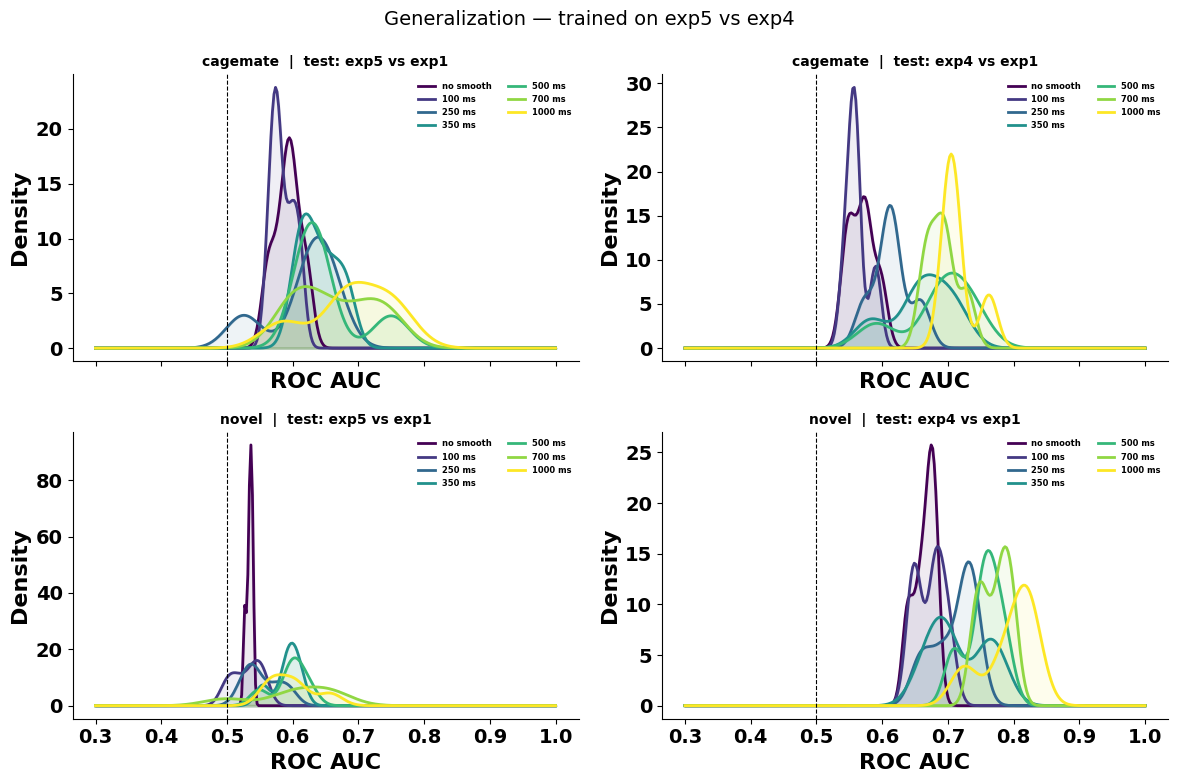

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, sem

# ── helpers ───────────────────────────────────────────────────────────────────

def get_auc_values(ccgp_result, train_key, test_key, start=0, stop=3):
    nmr = ccgp_result.roc_auc_scores[train_key][test_key]
    x_time = np.linspace(
        -ccgp_result.pre_window,
        ccgp_result.event_length + ccgp_result.post_window,
        nmr.roc_auc.shape[0],
    )
    t0 = np.where(x_time >= start)[0][0]
    t1 = np.where(x_time <= stop)[0][-1] + 1
    return np.nanmean(nmr.roc_auc[t0:t1], axis=0)

def get_auc_flat(ccgp_result, train_key, test_key, start=0, stop=3):
    nmr = ccgp_result.roc_auc_scores[train_key][test_key]
    x_time = np.linspace(
        -ccgp_result.pre_window,
        ccgp_result.event_length + ccgp_result.post_window,
        nmr.roc_auc.shape[0],
    )
    t0 = np.where(x_time >= start)[0][0]
    t1 = np.where(x_time <= stop)[0][-1] + 1
    return nmr.roc_auc[t0:t1].flatten()

def kde_plot(ax, values, color, label, bw=0.5, linestyle='-', dash_pattern=None):
    values = values[~np.isnan(values)]
    if len(values) < 2:
        return
    kde  = gaussian_kde(values, bw_method=bw)
    xs   = np.linspace(0.3, 1.0, 300)
    dens = kde(xs)
    line, = ax.plot(xs, dens, color=color, label=label, linewidth=2,
                    linestyle=linestyle)
    if dash_pattern is not None:
        line.set_dashes(dash_pattern)
    ax.fill_between(xs, dens, alpha=0.08, color=color)

def get_keys(ccgp_result, train_key):
    all_test_keys = list(ccgp_result.roc_auc_scores[train_key].keys())
    shuffle_key   = f"{train_key}_shuffle"
    real_keys     = [k for k in all_test_keys if k != shuffle_key]
    in_dist       = [k for k in real_keys if k == train_key]
    gen_keys      = [k for k in real_keys if k != train_key]
    return in_dist[0], gen_keys

def format_key(k):
    return k.replace('_', ' vs ').replace(' sniff', '')

def style_ax(ax):
    ax.axvline(0.5, color='k', linestyle='--', linewidth=0.8)
    ax.set_xlabel('ROC AUC')
    ax.set_ylabel('Density')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── constants ─────────────────────────────────────────────────────────────────

TRAIN_KEY   = 'exp5 sniff_exp4 sniff'
START, STOP = 0, 3
CAGE_COLOR  = '#792910'
NOV_COLOR   = '#15616F'

# linestyle + dash pattern per timebin
# 10ms: very short dashes, 50ms: medium dashes, 100ms: solid
TIMEBIN_STYLE = {
    #10:  ('--', (2, 4)),    # very short dashes
    #50:  ('--', (6, 3)),    # medium dashes
    100: ('-',  None),      # solid
}

timebins = [100]   # updated

sw_list   = smoothing_windows
cmap      = plt.cm.viridis
sw_colors = {sw: cmap(i / max(len(sw_list) - 1, 1))
             for i, sw in enumerate(sw_list)}

_, gen_keys = get_keys(results[sw_list[0]][timebins[0]][0], TRAIN_KEY)
gen_keys    = gen_keys[:2]

conditions = [('cagemate', 0, CAGE_COLOR), ('novel', 1, NOV_COLOR)]

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — one subplot per smoothing window
#          cage vs novel × 3 timebins
# ─────────────────────────────────────────────────────────────────────────────

n_sw  = len(sw_list)
ncols = 5
nrows = int(np.ceil(n_sw / ncols))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 4, nrows * 3.5),
                         sharex=True, sharey=False)
axes = axes.flatten()
fig.suptitle(f'In-distribution — {format_key(TRAIN_KEY)}\n'
             f'solid=100ms  long-dash=50ms  short-dash=10ms', fontsize=13)

for i, sw in enumerate(sw_list):
    ax = axes[i]
    for tb in timebins:
        ls, dp = TIMEBIN_STYLE[tb]
        try:
            cage_result, nov_result = results[sw][tb]
            in_dist_key, _          = get_keys(cage_result, TRAIN_KEY)
        except (KeyError, IndexError):
            continue
        kde_plot(ax, get_auc_values(cage_result, TRAIN_KEY, in_dist_key, START, STOP),
                 CAGE_COLOR, f'cage {tb}ms', linestyle=ls, dash_pattern=dp)
        kde_plot(ax, get_auc_values(nov_result,  TRAIN_KEY, in_dist_key, START, STOP),
                 NOV_COLOR,  f'novel {tb}ms', linestyle=ls, dash_pattern=dp)
    style_ax(ax)
    ax.set_title(f'{sw} ms' if sw is not None else 'no smooth', fontsize=9)
    ax.legend(fontsize=6, framealpha=0.7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2 — 2 cols (condition) × 3 rows (timebin)
#          all smoothing windows per subplot
#          subtitle: "{condition}: {timebin}ms"
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(len(timebins), len(conditions),
                           figsize=(12, len(timebins) * 3.5),
                           sharex=True, sharey=False, squeeze=False)
fig.suptitle(f'All smoothing windows — {format_key(TRAIN_KEY)}\n'
             f'(fold-averaged AUC)', fontsize=13)

for row, tb in enumerate(timebins):
    ls, dp = TIMEBIN_STYLE[tb]
    for col, (cond_name, result_idx, cond_color) in enumerate(conditions):
        ax = axes[row][col]
        for sw in sw_list:
            try:
                ccgp           = results[sw][tb][result_idx]
                in_dist_key, _ = get_keys(ccgp, TRAIN_KEY)
            except (KeyError, IndexError):
                continue
            label = f'{sw} ms' if sw is not None else 'no smooth'
            kde_plot(ax, get_auc_values(ccgp, TRAIN_KEY, in_dist_key, START, STOP),
                     sw_colors[sw], label, linestyle=ls, dash_pattern=dp)
        style_ax(ax)
        ax.set_title(f'{cond_name}: {tb}ms', fontsize=10)
        ax.legend(fontsize=6, framealpha=0.7, ncol=2)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1b — flat version of plot 1 (per-timepoint × folds)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 4, nrows * 3.5),
                         sharex=True, sharey=False)
axes = axes.flatten()
fig.suptitle(f'In-distribution (per-timepoint distribution) — {format_key(TRAIN_KEY)}\n'
             f'solid=100ms  long-dash=50ms  short-dash=10ms', fontsize=13)

for i, sw in enumerate(sw_list):
    ax = axes[i]
    for tb in timebins:
        ls, dp = TIMEBIN_STYLE[tb]
        try:
            cage_result, nov_result = results[sw][tb]
            in_dist_key, _          = get_keys(cage_result, TRAIN_KEY)
        except (KeyError, IndexError):
            continue
        kde_plot(ax, get_auc_flat(cage_result, TRAIN_KEY, in_dist_key, START, STOP),
                 CAGE_COLOR, f'cage {tb}ms', linestyle=ls, dash_pattern=dp)
        kde_plot(ax, get_auc_flat(nov_result,  TRAIN_KEY, in_dist_key, START, STOP),
                 NOV_COLOR,  f'novel {tb}ms', linestyle=ls, dash_pattern=dp)
    style_ax(ax)
    ax.set_title(f'{sw} ms' if sw is not None else 'no smooth', fontsize=9)
    ax.legend(fontsize=6, framealpha=0.7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 4 — flat version of plot 2: 2 cols × 3 rows, all smoothing windows
#          subtitle: "{condition}: {timebin}ms"
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(len(timebins), len(conditions),
                           figsize=(12, len(timebins) * 3.5),
                           sharex=True, sharey=False, squeeze=False)
fig.suptitle(f'All smoothing windows (per-timepoint distribution) — {format_key(TRAIN_KEY)}',
             fontsize=13)

for row, tb in enumerate(timebins):
    ls, dp = TIMEBIN_STYLE[tb]
    for col, (cond_name, result_idx, cond_color) in enumerate(conditions):
        ax = axes[row][col]
        for sw in sw_list:
            try:
                ccgp           = results[sw][tb][result_idx]
                in_dist_key, _ = get_keys(ccgp, TRAIN_KEY)
            except (KeyError, IndexError):
                continue
            label = f'{sw} ms' if sw is not None else 'no smooth'
            kde_plot(ax, get_auc_flat(ccgp, TRAIN_KEY, in_dist_key, START, STOP),
                     sw_colors[sw], label, linestyle=ls, dash_pattern=dp)
        style_ax(ax)
        ax.set_title(f'{cond_name}: {tb}ms', fontsize=10)
        ax.legend(fontsize=6, framealpha=0.7, ncol=2)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3 — unchanged, 100ms timebin only
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
fig.suptitle(f'Generalization — trained on {format_key(TRAIN_KEY)}', fontsize=14)

for row, (cond_name, result_idx, _) in enumerate(conditions):
    for col, gen_key in enumerate(gen_keys):
        ax = axes[row][col]
        for sw in sw_list:
            try:
                ccgp = results[sw][100][result_idx]
                vals = get_auc_values(ccgp, TRAIN_KEY, gen_key, START, STOP)
            except KeyError:
                continue
            kde_plot(ax, vals, sw_colors[sw],
                     f'{sw} ms' if sw is not None else 'no smooth')
        style_ax(ax)
        ax.set_title(f'{cond_name}  |  test: {format_key(gen_key)}', fontsize=10)
        ax.legend(fontsize=6, framealpha=0.7, ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
from importlib import reload
reload(decoders)
num_fold = 5
event_length = 5
pre_window = 2
post_window = 0
min_neurons = 5
cagemate_collection.analyze(smoothing_window=500, timebin=100, ignore_freq=0.5)
novel_collection.analyze(smoothing_window=500, timebin=100, ignore_freq=0.5)

events = ['exp1 sniff', 'exp5 sniff', 'exp4 sniff']
ccgp_results_cage_145 = decoders.trial_decoder_cross_generalization(cagemate_collection,
                                              num_fold = num_fold,
                                              events = events,
                                              percent_var = 99,
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear') 
ccgp_results_nov_145 = decoders.trial_decoder_cross_generalization(novel_collection,
                                              num_fold = num_fold,
                                              events = events,
                                              percent_var = 99,
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear') 
plot_average(ccgp_results_cage_145, color_dict=color_dict_cage, start = 0 , stop=3)
plot_average(ccgp_results_nov_145, color_dict=color_dict_novel, start = 0 , stop=3)

In [ ]:
from importlib import reload
reload(decoders)
num_fold = 5
event_length = 5
pre_window = 2
post_window = 0
min_neurons = 5
cagemate_collection.analyze(smoothing_window=250, timebin=100, ignore_freq=0.5)
novel_collection.analyze(smoothing_window=250, timebin=100, ignore_freq=0.5)

events = ['exp1 sniff', 'exp5 sniff', 'exp4 sniff']
ccgp_results_cage_145_90 = decoders.trial_decoder_cross_generalization(cagemate_collection,
                                              num_fold = num_fold,
                                              events = events,
                                              percent_var = 90,
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear') 
ccgp_results_nov_145_90 = decoders.trial_decoder_cross_generalization(novel_collection,
                                              num_fold = num_fold,
                                              events = events,
                                              percent_var = 90,
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear') 
plot_average(ccgp_results_cage_145_90, color_dict=color_dict_cage, start = 0 , stop=3)
plot_average(ccgp_results_nov_145_90, color_dict=color_dict_novel, start = 0 , stop=3)

In [ ]:
print(ccgp_results_nov_145_90)
print(ccgp_results_cage_145_90)
print(ccgp_results_nov_145)


In [ ]:
decoders.plot_cross_gen_weights(ccgp_results_cage_145)
decoders.plot_cross_gen_weights(ccgp_results_nov_145)

In [ ]:
num_fold = 5
event_length = 5
pre_window = 2
post_window = 0
min_neurons = 5
cagemate_collection.analyze(smoothing_window=500, timebin=100, ignore_freq=0.5)
novel_collection.analyze(smoothing_window=500, timebin=100, ignore_freq=0.5)

events = ['exp1 sniff', 'exp5 sniff', 'exp4 sniff']
ccgp_results_cage_145 = decoders.trial_decoder_cross_generalization(cagemate_collection,
                                              num_fold = num_fold,
                                              events = events,
                                              percent_var = 90,
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear') 
ccgp_results_nov_145 = decoders.trial_decoder_cross_generalization(novel_collection,
                                              num_fold = num_fold,
                                              events = events,
                                              percent_var = 90,
                                              event_length = event_length,
                                              pre_window = pre_window,
                                              post_window = post_window,
                                              min_neurons = min_neurons,
                                              classifier_type = 'linear') 
plot_average(ccgp_results_cage_145, color_dict=color_dict_cage, start = 0 , stop=3)
plot_average(ccgp_results_nov_145, color_dict=color_dict_novel, start = 0 , stop=3)

In [ ]:
print(ccgp_results_cage_145)

## Condition dict PCA

In [161]:
whole_collection = sc.SpikeCollection.load_collection(r'C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\Habituation_Dishabituation (phase 1)\spike_data\cagemate_collection')

for recording in whole_collection.recordings:
    novel = np.concatenate([recording.event_dict['exp1 sniff'], recording.event_dict['exp3 sniff'], recording.event_dict['exp4 sniff'], recording.event_dict['exp2 sniff']], axis = 0)
    recording.event_dict['mouseA'] = novel

In [162]:

for recording in novel_collection.recordings:
    whole_collection.recordings.append(recording)


In [163]:
print(len(whole_collection.recordings))

21


In [164]:
for recording in whole_collection.recordings:
    print(recording.name)

11_cage_p1_merged.rec
12_cage_p1_merged.rec
13_cage_p1_merged.rec
21_cage_p1_merged.rec
22_cage_p1_merged.rec
24_cage_p1_merged.rec
31_cage_p1_merged.rec
32_cage_p1_merged.rec
33_cage_p1_merged.rec
41_cage_p1_merged.rec
44_cage_p1_merged.rec
11_nov_p1_merged.rec
12_nov_p1_merged.rec
13_nov_p1_merged.rec
21_nov_p1_merged.rec
22_nov_p1_merged.rec
24_nov_p1_merged.rec
32_nov_p1_merged.rec
33_nov_p1_merged.rec
41_nov_p1_merged.rec
44_nov_p1_merged.rec


In [165]:
for recording in whole_collection.recordings:
    novel = np.concatenate([recording.event_dict['exp1 sniff'], recording.event_dict['exp5 sniff']], axis = 0)
    recording.event_dict['novel'] = novel
    not_novel = np.concatenate([recording.event_dict['exp3 sniff'], recording.event_dict['exp4 sniff']], axis = 0)
    recording.event_dict['not_novel'] = not_novel

In [166]:
whole_collection.analyze(timebin = 100, ignore_freq = 0.5, smoothing_window = 250)

Your event dictionary keys are different across recordings.
Please double check them:
11_cage_p1_merged.rec keys: dict_keys(['aversive', 'baseline', 'exp1 allogroom', 'exp1 aversive', 'exp1 chase', 'exp1 fight', 'exp1 positive', 'exp1 sniff', 'exp2 allogroom', 'exp2 aversive', 'exp2 chase', 'exp2 fight', 'exp2 positive', 'exp2 sniff', 'exp3 allogroom', 'exp3 aversive', 'exp3 chase', 'exp3 fight', 'exp3 positive', 'exp3 sniff', 'exp4 allogroom', 'exp4 aversive', 'exp4 chase', 'exp4 fight', 'exp4 positive', 'exp4 sniff', 'exp5 allogroom', 'exp5 aversive', 'exp5 chase', 'exp5 fight', 'exp5 positive', 'exp5 sniff', 'positive', 'mouseA', 'novel', 'not_novel'])
12_cage_p1_merged.rec keys: dict_keys(['aversive', 'baseline', 'exp1 allogroom', 'exp1 aversive', 'exp1 chase', 'exp1 fight', 'exp1 positive', 'exp1 sniff', 'exp2 allogroom', 'exp2 aversive', 'exp2 chase', 'exp2 fight', 'exp2 positive', 'exp2 sniff', 'exp3 allogroom', 'exp3 aversive', 'exp3 chase', 'exp3 fight', 'exp3 positive', 'exp3

In [167]:
condition_dict = {"cagemate": [], "novel": []}
for recording in whole_collection.recordings:
    if "cage" in recording.name:
        condition_dict["cagemate"].append(recording.name)
    if "nov" in recording.name:
        condition_dict["novel"].append(recording.name)
print(condition_dict)

{'cagemate': ['11_cage_p1_merged.rec', '12_cage_p1_merged.rec', '13_cage_p1_merged.rec', '21_cage_p1_merged.rec', '22_cage_p1_merged.rec', '24_cage_p1_merged.rec', '31_cage_p1_merged.rec', '32_cage_p1_merged.rec', '33_cage_p1_merged.rec', '41_cage_p1_merged.rec', '44_cage_p1_merged.rec'], 'novel': ['11_nov_p1_merged.rec', '12_nov_p1_merged.rec', '13_nov_p1_merged.rec', '21_nov_p1_merged.rec', '22_nov_p1_merged.rec', '24_nov_p1_merged.rec', '32_nov_p1_merged.rec', '33_nov_p1_merged.rec', '41_nov_p1_merged.rec', '44_nov_p1_merged.rec']}


In [168]:
events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff']

In [169]:
pca_result = population_analysis.condition_pca(whole_collection, event_length=4, pre_window = 3, events = events, post_window=0, min_neurons=5, condition_dict = condition_dict, plot= False)

Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons


In [170]:
pca_result

                Recording  Number of Neurons  Number of exp1 sniff events  \
0    41_nov_p1_merged.rec                 25                           32   
1   21_cage_p1_merged.rec                 25                           28   
2    11_nov_p1_merged.rec                 20                           24   
3   12_cage_p1_merged.rec                 18                           24   
4   44_cage_p1_merged.rec                 16                           11   
5    12_nov_p1_merged.rec                 15                           25   
6    44_nov_p1_merged.rec                 14                           31   
7   11_cage_p1_merged.rec                 13                           22   
8   32_cage_p1_merged.rec                 13                           20   
9   22_cage_p1_merged.rec                 13                           18   
10   32_nov_p1_merged.rec                 13                           28   
11   22_nov_p1_merged.rec                 12                           29   

Your event dictionary keys are different across recordings.
Please double check them:
11_cage_p1_merged.rec keys: dict_keys(['aversive', 'baseline', 'exp1 allogroom', 'exp1 aversive', 'exp1 chase', 'exp1 fight', 'exp1 positive', 'exp1 sniff', 'exp2 allogroom', 'exp2 aversive', 'exp2 chase', 'exp2 fight', 'exp2 positive', 'exp2 sniff', 'exp3 allogroom', 'exp3 aversive', 'exp3 chase', 'exp3 fight', 'exp3 positive', 'exp3 sniff', 'exp4 allogroom', 'exp4 aversive', 'exp4 chase', 'exp4 fight', 'exp4 positive', 'exp4 sniff', 'exp5 allogroom', 'exp5 aversive', 'exp5 chase', 'exp5 fight', 'exp5 positive', 'exp5 sniff', 'positive', 'mouseA', 'novel', 'not_novel'])
12_cage_p1_merged.rec keys: dict_keys(['aversive', 'baseline', 'exp1 allogroom', 'exp1 aversive', 'exp1 chase', 'exp1 fight', 'exp1 positive', 'exp1 sniff', 'exp2 allogroom', 'exp2 aversive', 'exp2 chase', 'exp2 fight', 'exp2 positive', 'exp2 sniff', 'exp3 allogroom', 'exp3 aversive', 'exp3 chase', 'exp3 fight', 'exp3 positive', 'exp3

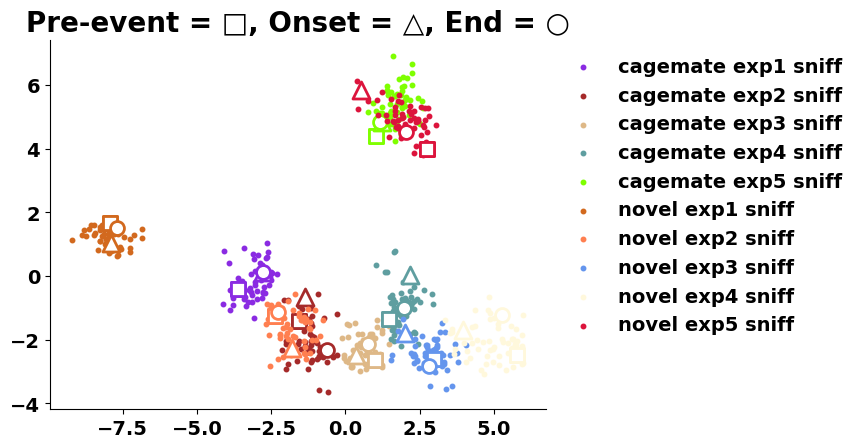

In [171]:
from importlib import reload
reload(population_analysis)
events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff']
#events = ['novel', 'not_novel']
event_length=3
pre_window = 3
post_window=0
min_neurons=5
plot= False
whole_collection.analyze(timebin = 100, smoothing_window=250, ignore_freq=0.5)
pca_result = population_analysis.condition_pca(whole_collection, condition_dict,events = events, event_length=event_length, pre_window=pre_window, min_neurons=min_neurons, plot=True)

In [172]:
print(pca_result)

PCA Result with:
Events: exp1 sniff, exp2 sniff, exp3 sniff, exp4 sniff, exp5 sniff
Timebins per event: 60.0
Total neurons: 261
Number of recordings: 18
Number of Pcs needed to explain 90% of variance 85


In [173]:
def plot_condition_results_3d(pca_result, title, colors, azim, elev, save = False):
    event_lengths = int(
            (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
        )
    
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_key = pca_result.labels
    PCA_matrix = pca_result.transformed_data
    col_counter = 0
    fig = plt.figure(figsize = (8,8))
    ax = fig.add_subplot(111, projection="3d")
    #plt.subplots_adjust(left=0.3, right=0.99, bottom=0.1, top=0.9)
    for condition in condition_dict.keys():
        for i in range(0, len(PCA_key), event_lengths):
            event_label = PCA_key[i]
            onset = int(i + pca_result.pre_window - 1)
            end = int(i + event_end - 1)
            post = int(i + event_lengths - 1)
            ax.plot3D(
                PCA_matrix[condition][i : i + event_lengths, 0],
                PCA_matrix[condition][i : i + event_lengths, 1],
                PCA_matrix[condition][i : i + event_lengths, 2],
                label=f"{condition} {event_label}",
                color=colors[col_counter],
                linewidth = 5,
                alpha = 0.8
            )
            ax.scatter(
                PCA_matrix[condition][i, 0],
                PCA_matrix[condition][i, 1],
                PCA_matrix[condition][i, 2],
                marker="s",
                s=100,
                c="w",
                edgecolors=colors[col_counter],
            )
            ax.scatter(
                PCA_matrix[condition][onset, 0],
                PCA_matrix[condition][onset, 1],
                PCA_matrix[condition][onset, 2],
                marker="^",
                s=300,
                c="w",
                edgecolors=colors[col_counter],
            )
            ax.scatter(
                PCA_matrix[condition][end, 0],
                PCA_matrix[condition][end, 1],
                PCA_matrix[condition][end, 2],
                marker="o",
                s=200,
                c="w",
                edgecolors=colors[col_counter],
            )
            if post_window != 0:
                ax.scatter(
                    PCA_matrix[condition][post, 0],
                    PCA_matrix[condition][post, 1],
                    PCA_matrix[condition][post, 2],
                    marker="D",
                    s=200,
                    c="w",
                    edgecolors=colors[col_counter],
                )
            col_counter += 1
    ax.legend(loc="upper left", bbox_to_anchor=(.9,1), frameon = False, fontsize = 14)
    # ax.set_xlim(-20, 45)
    # ax.set_ylim(-5, 25)
    # ax.set_zlim(-20, 30)
    ax.view_init(azim = azim, elev =elev)
    ax.set_title(f"{title}", fontsize = 24, y = 1)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% variance)", fontsize = 16, labelpad = -10)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% variance)", fontsize = 16, labelpad = -10)
    ax.set_zlabel(f"PC3 ({pc_var[2]*100:.1f}% variance)", fontsize = 16, labelpad = -10)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.yaxis.pane.set_alpha(0.9)
    ax.xaxis.pane.set_alpha(0.9)
    ax.zaxis.pane.set_alpha(0.9)
    plt.tight_layout()
    if save:
        plt.savefig(f'{title}.png', dpi = 600, transparent = True,bbox_inches='tight' )
    plt.show()


def plot_condition_results_2d(pca_result, title, colors, legend_spot, include_cagemate = True, xlim = None, ylim = None,save=False):
    event_lengths = int(
        (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
    )
    
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_key = pca_result.labels
    PCA_matrix = pca_result.transformed_data
    col_counter = 0
    
    # Create figure with updated size
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)
    for condition in condition_dict.keys():
        if not include_cagemate and condition == 'cagemate':
            pass
        else:
            for i in range(0, len(PCA_key), event_lengths):
                event_label = PCA_key[i]
                onset = int(i + pca_result.pre_window - 1)
                end = int(i + event_end - 1)
                post = int(i + event_lengths - 1)
                
                # Plot the continuous line with updated styling
                ax.plot(
                    PCA_matrix[condition][i:i + event_lengths, 0],
                    PCA_matrix[condition][i:i + event_lengths, 1],
                    label=event_label if condition == 'cagemate' else None,
                    color=colors[col_counter],
                    linewidth=5,
                    alpha=0.8,
                    zorder = 1
                )
                
                # Add markers with updated sizes
                ax.scatter(
                    PCA_matrix[condition][i, 0],
                    PCA_matrix[condition][i, 1],
                    marker="s",
                    s=200,
                    c="w",
                    edgecolors=colors[col_counter],
                    zorder = 2
                )
                ax.scatter(
                    PCA_matrix[condition][onset, 0],
                    PCA_matrix[condition][onset, 1],
                    marker="^",
                    s=300,
                    c="w",
                    edgecolors=colors[col_counter],
                    zorder = 3
                )
                ax.scatter(
                    PCA_matrix[condition][end, 0],
                    PCA_matrix[condition][end, 1],
                    marker="o",
                    s=200,
                    c="w",
                    edgecolors=colors[col_counter],
                    zorder = 4
                )
                if post_window != 0:
                    ax.scatter(
                        PCA_matrix[condition][post, 0],
                        PCA_matrix[condition][post, 1],
                        marker="D",
                        s=200,
                        c="w",
                        edgecolors=colors[col_counter],
                        zorder =5
                    )
                col_counter += 1
        
    # Updated legend formatting
    ax.legend(loc="upper left", bbox_to_anchor=legend_spot, frameon=False, fontsize=14)
    
    # ax.set_xlim(-20, 45)
    # ax.set_ylim(-5, 25)
    
    # Updated title and label formatting
    ax.set_title(f"{title}", fontsize=24, y=1.01)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% variance)", fontsize=16)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% variance)", fontsize=16)
    if ylim is not None:
        ax.set_ylim(ylim)
    if xlim is not None: 
        ax.set_xlim(xlim)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_xticks([])
    
    # Add tight layout
    plt.tight_layout()
    
    if save:
        plt.savefig(f'{title}.png', dpi=600, transparent=True, bbox_inches='tight')
    plt.show()

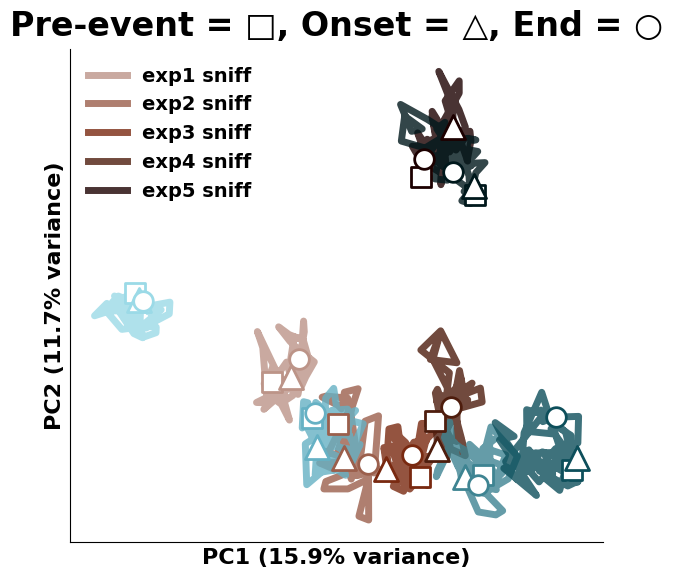

C:\Users\megha\AppData\Local\Temp\ipykernel_27136\3380868870.py:84: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


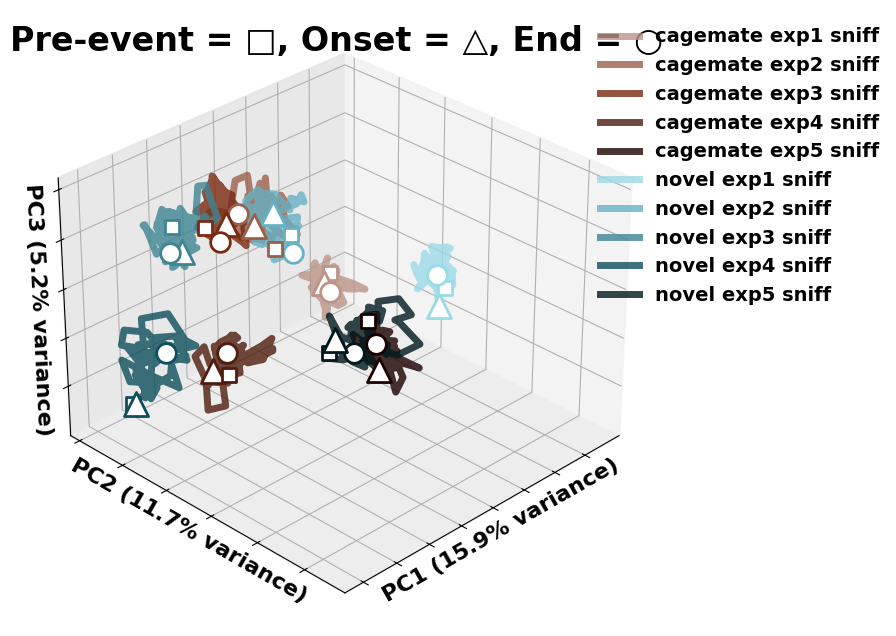

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


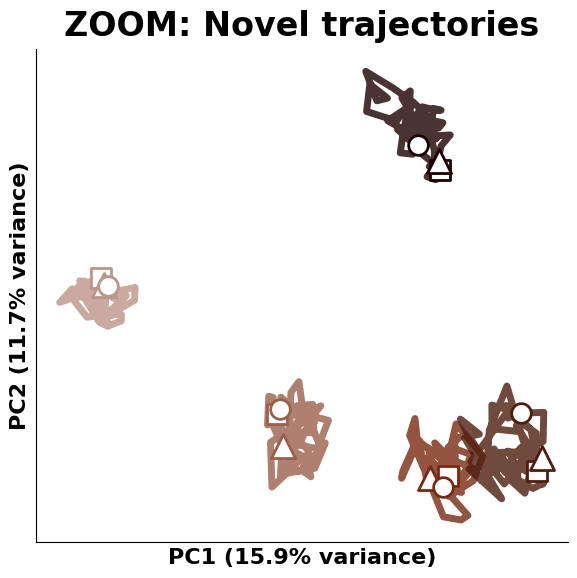

In [175]:
exp_colors = [hex_2_rgb('#bc9488'),
              hex_2_rgb('#9b5f4c'),
              hex_2_rgb('#792910'),
              hex_2_rgb("#4e1d0d"),
              hex_2_rgb("#1C0000"),
              hex_2_rgb("#9BDAE7"),
              hex_2_rgb("#66B1C4"),
              hex_2_rgb("#3E8492"),
              hex_2_rgb("#0D4F5B"),
              hex_2_rgb("#00181C")]


title = "Pre-event = □, Onset = △, End = ○" 
plot_condition_results_2d(pca_result=pca_result, title = title, colors = exp_colors, legend_spot = (0, 1))
plot_condition_results_3d(pca_result=pca_result, title = title, colors = exp_colors, azim = 45, elev = 30)
plot_condition_results_2d(pca_result=pca_result, title = 'ZOOM: Novel trajectories', colors = exp_colors, legend_spot = (0, 1),  include_cagemate = False)

In [176]:
from importlib import reload
reload(population_analysis)
events = ['exp1 sniff', 'exp2 sniff', 'exp3 sniff', 'exp4 sniff', 'exp5 sniff']
#events = ['novel', 'not_novel']
event_length=3
pre_window = 3
post_window=0
min_neurons=5
plot= False

result_list = population_analysis.LOO_PCA(whole_collection, event_length=event_length, pre_window=pre_window, post_window=post_window, events=events, min_neurons= min_neurons, condition_dict=condition_dict, plot = False)

Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons
Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1

[376.92397673 471.98662626 462.19561888 361.6656456  576.05657318
 366.32612578]
['exp1 sniff_cagemate' 'exp4 sniff_cagemate' 'exp5 sniff_cagemate'
 'exp1 sniff_novel' 'exp4 sniff_novel' 'exp5 sniff_novel']


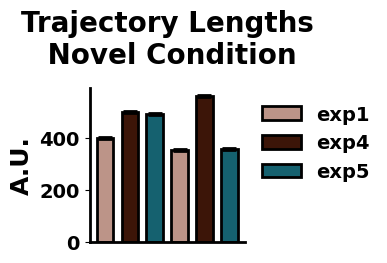

,Comparison,t_statistic,p_value,p_adjusted,significant
0,exp1_exp4,-72.031134,1.230111e-25,3.690334e-25,True
1,exp1_exp5,-44.853976,1.511026e-21,3.022051e-21,True
2,exp4_exp5,2.764754,1.195170e-02,1.195170e-02,True


In [182]:
from scipy.spatial.distance import euclidean
from statsmodels.stats.multitest import multipletests
def condition_trajectory_length(pca_dict, key):
    trajectory_lengths = []
    event_order = []
    unique_values, counts = np.unique(key, return_counts=True)
    event_len = counts[0]
   
    for condition in pca_dict.keys():
        for j in range(0, len(key), event_len):
            trajectory_length = 0
            for i in range(event_len-1):
                trajectory_length = trajectory_length + euclidean(
                    pca_dict[condition][j+i, :],
                    pca_dict[condition][j+i+1, :])
            trajectory_lengths.append(trajectory_length)
            event_order.append(f"{key[j]}_{condition}")
    return [trajectory_lengths, event_order]


trajectory_lengths = []
orders= []
for loo_result in result_list:
    [traj_len, event_order] = condition_trajectory_length(loo_result.transformed_data, loo_result.labels)
    trajectory_lengths.append(traj_len)
    orders.append(event_order)
trajectory_lengths = np.array(trajectory_lengths)
print(np.array(trajectory_lengths[1])[[0,3,4,5,8,9]])
print(np.array(orders[1])[[0,3,4,5,8,9]])

means = np.mean(trajectory_lengths, axis = 0)
sems = sem(trajectory_lengths, axis = 0)
means_for_plotting = means[[0,3,4,5,8,9]]
sems_for_plotting = sems[[0,3,4,5,8,9]]

t_exp1_exp4, p_exp1_exp4 = stats.ttest_rel(trajectory_lengths[:,0], trajectory_lengths[:,3])
t_exp1_exp5, p_exp1_exp5 = stats.ttest_rel(trajectory_lengths[:,0], trajectory_lengths[:,4])
t_exp4_exp5, p_exp4_exp5 = stats.ttest_rel(trajectory_lengths[:,3], trajectory_lengths[:,4])
p_values = [p_exp1_exp4, p_exp1_exp5, p_exp4_exp5]
reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
stats_df = pd.DataFrame({
   'Comparison': ['exp1_exp4', 'exp1_exp5', 'exp4_exp5'],
   't_statistic': [t_exp1_exp4, t_exp1_exp5, t_exp4_exp5],
   'p_value': p_values,
   'p_adjusted': p_adjusted,
   'significant': reject
})

#Adjust p-values using Holm-Bonferroni
p_values = [p_exp1_exp4, p_exp1_exp5, p_exp4_exp5]
reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
color_id_dict = {'exp1': hex_2_rgb('#bc9488'), 
                'exp4': hex_2_rgb('#3c1508'),
                  'exp5':  hex_2_rgb('#15616F'),
                  'exp1': hex_2_rgb('#bc9488'), 
                'exp4': hex_2_rgb('#3c1508'),
                  'exp5':  hex_2_rgb('#15616F')} 
  # Ensures bars don't overlap but aren't too thin
                                # Max width of 0.4 (your original), gets smaller with more bars

# Create evenly spaced x positions based on the number of data points
x = np.arange(len(means_for_plotting))
width = 4 / len(x)
plt.figure(figsize= (2,2))           
plt.bar(x, means_for_plotting, yerr = sems_for_plotting,
            color = color_id_dict.values(),
            edgecolor = 'black',
            capsize = 5, linewidth = 2,
            error_kw={'elinewidth': 2, 'capthick': 2}, 
            width = width)
plt.xticks([],rotation=45)
legend_handles = [Patch(facecolor=color, label=label) for label, color in color_id_dict.items()]
plt.legend(handles=legend_handles,
           bbox_to_anchor=(1,1),
           frameon= False, fontsize = 14)
plt.ylabel('A.U.', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(20))
#plt.ylim(40,100)
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Trajectory Lengths\n Novel Condition', fontsize = 20, y = 1.1)
plt.show()

stats_df

In [178]:

def get_indices(repeated_items_list):
    """
    Takes in an indexed key or a list of repeated items,
    creates a list of indices that correspond to each unique item.

    Args (1):
        repeated_items_list: list, list of repeated items

    Returns:
        item_indices: list of tuples, where the first element
            is the first index of an item, and the second
            element is the last index of that item
    """
    is_first = True
    item_indices = []
    for i in range(len(repeated_items_list)):
        if is_first:
            current_item = repeated_items_list[i]
            start_index = 0
            is_first = False
        else:
            if repeated_items_list[i] == current_item:
                end_index = i
                if i == (len(repeated_items_list) - 1):
                    item_indices.append([start_index, end_index])
            else:
                item_indices.append([start_index, end_index])
                start_index = i
                current_item = repeated_items_list[i]
    return item_indices
    
def event_slice(transformed_subsets, key, no_PCs, mode):
    """
    Takes in a matrix T (session x timebins x pcs) (mode = 'multisession')
    or (timebins x pcs) (mode = 'single')
    and an event key to split the matrix by event and trim it to no_PCs.

    Args (3):
        transformed_subsets: np.array, d(session X timebin X PCS)
        key: list of str, each element is an event type and
            corresponds to the timebin dimension indices of
            the transformed_subsets matrix
        no_PCs: int, number of PCs required to explain a variance threshold
        mode: {'multisession', 'single'}; multisession calculates event slices
            for many transformed subsets, single calculates event slices for a
            single session
    Returns:
        trajectories: dict, events to trajectories across
            each LOO PCA embedding
            keys: str, event types
            values: np.array, d=(session x timebins x no_PCs)
    """
    event_indices = get_indices(key)
    events = np.unique(key)
    trajectories = {}
    for i in range(len(event_indices)):
        event = events[i]
        start = event_indices[i][0]
        stop = event_indices[i][1]
        if mode == "multisession":
            event_trajectory = transformed_subsets[:, start : stop + 1, :no_PCs]
        if mode == "single":
            event_trajectory = transformed_subsets[start : stop + 1, :no_PCs]
        trajectories[event] = event_trajectory
    return trajectories


def geodesic_distances(event_trajectories, mode):
    # Get all events
    events = list(event_trajectories.keys())
    
    # Initialize empty DataFrame with events as both rows and columns
    df = pd.DataFrame(index=events, columns=events)
    
    # Fill diagonal with zeros (distance to self is 0)
    for event in events:
        df.loc[event, event] = 0
    
    # Calculate distances for each pair
    pairs = list(combinations(events, 2))
    for pair in pairs:
        event1 = pair[0]
        event2 = pair[1]  # Only calculate each pair once
        dist = distance_bw_trajectories(
            event_trajectories[event1], 
            event_trajectories[event2], 
            mode
        )
        # Fill both symmetric positions in the DataFram
        converted_dist = float(np.mean(np.array(dist)))
        converted_sem = float(sem(np.array(dist)))
        # Fill both symmetric positions in the DataFrame
        df.loc[event1, event2] = converted_dist #converted_sem
        df.loc[event2, event1] = converted_dist #converted_sem

    return df

def distance_bw_trajectories(trajectory1, trajectory2, mode):
    if mode == "multisession":
        geodesic_distances = []
        for session in range(trajectory1.shape[0]):
            dist_bw_tb = 0
            for i in range(trajectory1.shape[1]):
                dist_bw_tb = dist_bw_tb + euclidean(trajectory1[session, i, :], trajectory2[session, i, :])
            geodesic_distances.append(dist_bw_tb)
    if mode == "single":
        dist_bw_tb = 0
        for i in range(trajectory1.shape[0]):
            dist_bw_tb = dist_bw_tb + euclidean(trajectory1[i, :], trajectory2[i, :])
        geodesic_distances = dist_bw_tb
    return geodesic_distances


def get_indices_claude(repeated_items_list):
    """
    Takes in a list of repeated items and returns start/end indices for each unique sequence.
    
    Args:
        repeated_items_list: list of repeated items
    
    Returns:
        list of [start_index, end_index] for each unique sequence
    """  
    result = []
    start = 0
    current = repeated_items_list[0]
    for i, item in enumerate(repeated_items_list[1:], 1):
        if item != current:
            result.append([start, i-1])
            start = i
            current = item    
    # Don't forget the last group
    result.append([start, len(repeated_items_list)-1])
    
    return result

In [179]:
print(get_indices(master_key))
get_indices_claude(master_key)

NameError: name 'master_key' is not defined

In [ ]:
trajectory1 = np.array([
    # Session 1
    [[0],  # timepoint 1
     [1],  # timepoint 2
     [2]], # timepoint 3
    
    # Session 2
    [[0],
     [1],
     [2]]
])

trajectory2 = np.array([
    # Session 1
    [[1],  # timepoint 1
     [2],  # timepoint 2
     [3]], # timepoint 3
    
    # Session 2
    [[2],
     [4],
     [5]]
])

distance_bw_trajectories(trajectory1=trajectory1, trajectory2=trajectory2, mode = 'multisession')

In [183]:
# no_PCs = PCs_needed(explained_variance_ratios, percent_var)
    # event_trajectories = event_slice(transformed_subsets, key, no_PCs, mode="multisession")
    # pairwise_distances = geodesic_distances(event_trajectories, mode="multisession")
#transformed_subsets = [sessions x 300 x 19]
cagemates = []
novels = []
for loo_result in result_list:
    cagemates.append(loo_result.transformed_data['cagemate'][:,:19])
    novels.append(loo_result.transformed_data['novel'][:,:19])
cagemates = np.stack(cagemates)
novels = np.stack(novels)

 
key = result_list[0].labels

prefix1 = "cagemate\n"
prefix2 = "novel\n"

list1 = [prefix1 + item for item in key]
list2 = [prefix2 + item for item in key]
master_key = list1 + list2


transformed_subsets = np.concatenate([cagemates, novels], axis = 1)

print(len(transformed_subsets.shape))
event_trajectories = event_slice(transformed_subsets, master_key, 3, 'multisession')


pairwise_distances = geodesic_distances(event_trajectories, mode="multisession")
pairwise_distances

3


,cagemate\nexp1 sniff,cagemate\nexp2 sniff,cagemate\nexp3 sniff,cagemate\nexp4 sniff,cagemate\nexp5 sniff,novel\nexp1 sniff,novel\nexp2 sniff,novel\nexp3 sniff,novel\nexp4 sniff,novel\nexp5 sniff
cagemate\nexp1 sniff,0,224.935479,319.445833,324.118005,442.492493,303.157977,188.556393,416.390918,496.651457,439.953392
cagemate\nexp2 sniff,224.935479,0,142.75947,332.14666,474.197049,473.808457,85.829837,252.470291,437.188644,453.852629
cagemate\nexp3 sniff,319.445833,142.75947,0,321.969084,463.374524,584.543197,178.975696,141.861905,375.707074,436.502699
cagemate\nexp4 sniff,324.118005,332.14666,321.969084,0,426.979348,605.98661,338.652167,311.320126,202.952203,412.964327
cagemate\nexp5 sniff,442.492493,474.197049,463.374524,426.979348,0,629.063562,466.455216,471.394203,511.45358,85.834069
novel\nexp1 sniff,303.157977,473.808457,584.543197,605.98661,629.063562,0,428.655602,696.043848,785.222611,637.454783
novel\nexp2 sniff,188.556393,85.829837,178.975696,338.652167,466.455216,428.655602,0,288.583836,456.754566,448.965976
novel\nexp3 sniff,416.390918,252.470291,141.861905,311.320126,471.394203,696.043848,288.583836,0,296.661968,437.422616
novel\nexp4 sniff,496.651457,437.188644,375.707074,202.952203,511.45358,785.222611,456.754566,296.661968,0,487.035706
novel\nexp5 sniff,439.953392,453.852629,436.502699,412.964327,85.834069,637.454783,448.965976,437.422616,487.035706,0


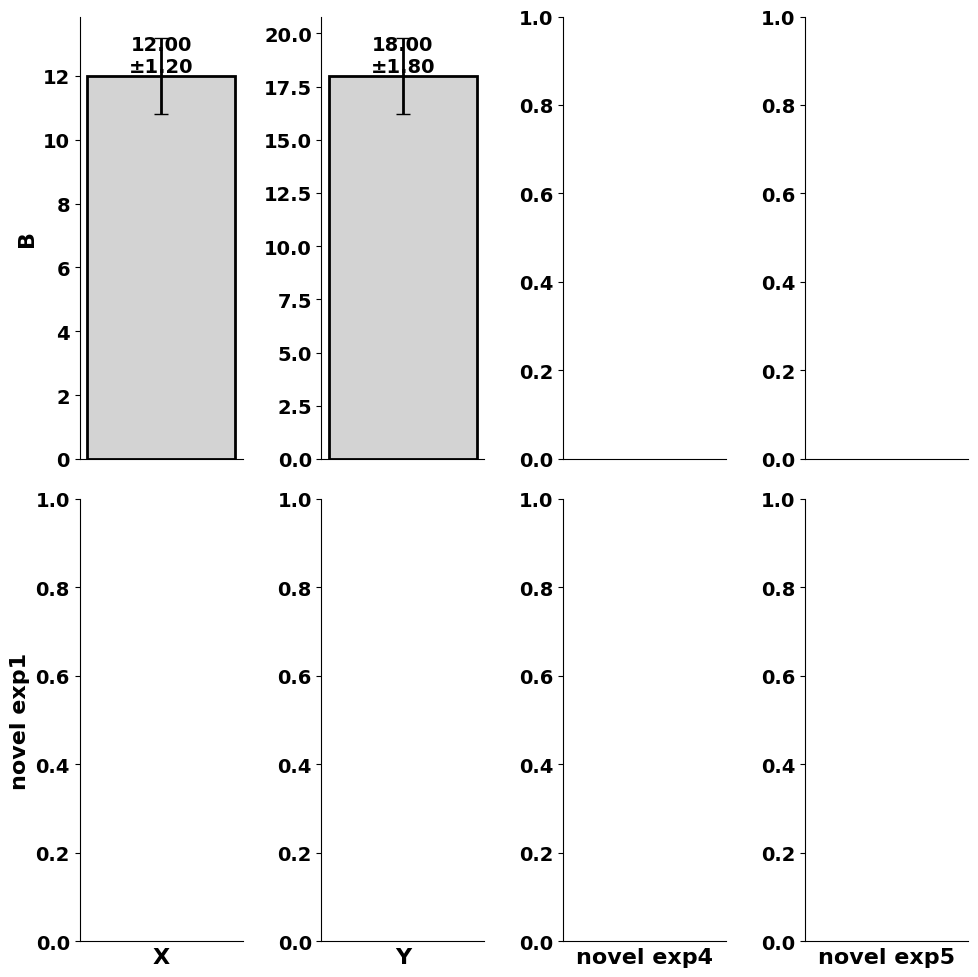

In [184]:
def plot_paired_bar_matrix(pairs, means, sems, figsize=(10,10)):
    """
    Create a matrix of bar plots where each cell shows mean ± SEM for a pair of conditions
    
    Parameters:
    pairs: List of lists, where each sublist contains [row_name, col_name]
    means: Dictionary with (row_name, col_name) tuples as keys and mean values
    sems: Dictionary with (row_name, col_name) tuples as keys and SEM values
    figsize: Tuple for figure size (width, height)
    """
    # Get unique row and column names
    row_names = sorted(list(set([pair[0] for pair in pairs])))
    col_names = sorted(list(set([pair[1] for pair in pairs])))
    
    # Create figure with subplot grid
    fig, axs = plt.subplots(len(row_names), len(col_names), 
                           figsize=figsize, 
                           squeeze=False)
    
    # Iterate through each subplot position
    for i, row in enumerate(row_names):
        for j, col in enumerate(col_names):
            ax = axs[i,j]
            
            # Check if this pair exists in our data
            if (row, col) in means:
                mean = means[(row, col)]
                sem = sems[(row, col)]
                
                # Create bar plot
                ax.bar([0], [mean], yerr=[sem], 
                      capsize=5, color='lightgray', 
                      edgecolor='black')
                
                # Add text for mean ± SEM
                ax.text(0, mean, f'{mean:.2f}\n±{sem:.2f}', 
                       ha='center', va='bottom')
                
                # Remove spines
                ax.spines['right'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
            # Set labels and limits
            if i == len(row_names)-1:  # Bottom row
                ax.set_xlabel(col)
            if j == 0:  # First column
                ax.set_ylabel(row)
                
            # Remove ticks
            ax.set_xticks([])
    
    plt.tight_layout()
    return fig, axs

# Example usage:
pairs = [['novel exp1 sniff', 'novel exp4'], ['novel exp1', 'novel exp5'], ['B', 'X'], ['B', 'Y']]
means = {
    ('A', 'X'): 10, ('A', 'Y'): 15,
    ('B', 'X'): 12, ('B', 'Y'): 18
}
sems = {
    ('A', 'X'): 1, ('A', 'Y'): 1.5,
    ('B', 'X'): 1.2, ('B', 'Y'): 1.8
}

fig, axs = plot_paired_bar_matrix(pairs, means, sems)
plt.show()

In [187]:
def plot_comparison_heatmap(matrix, title, color, diagonal_color, vmin):
    # Create comparison matrix
    # Create figure
    
    # if matrix.index.dtype == 'object':
    #     matrix = matrix.set_index(matrix.columns[0])
    
    # Make sure all data columns are numeric
    matrix = matrix.astype(float)
    plt.figure(figsize=(10, 10))
    n_bins = 100  # Number of color gradients
    cmap = LinearSegmentedColormap.from_list('custom', color, N=n_bins)
    # Create heatmap
    
    sns.heatmap(matrix, 
                annot=True, 
                cmap=cmap,
                fmt='.0f',
                square=True,
                cbar_kws={'label': 'AU Distance', 'shrink': 0.8},
                vmin = vmin)
    if diagonal_color is not None:
        for i in range(len(matrix)):
            plt.plot(i + 0.5, i + 0.5, 'o', color=diagonal_color, markersize=25, zorder =100)
    
    plt.title(title, fontsize = 16)
    plt.tight_layout()
    return plt

<module 'matplotlib.pyplot' from 'c:\\Users\\megha\\anaconda3\\envs\\ephys_env\\lib\\site-packages\\matplotlib\\pyplot.py'>

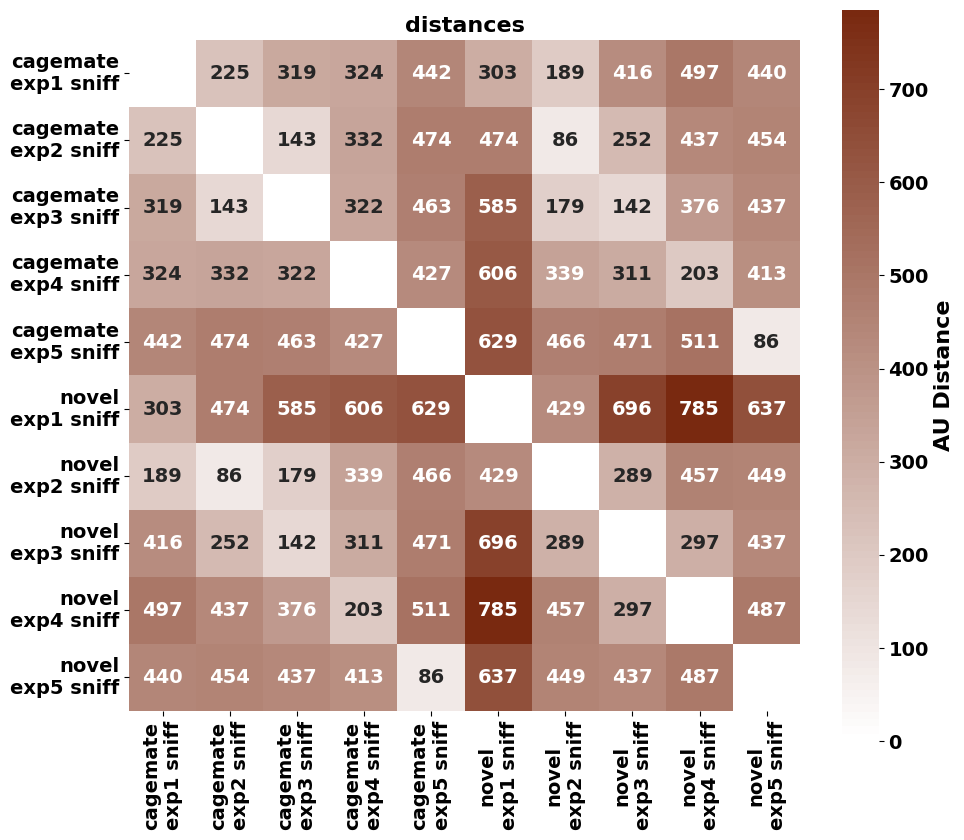

In [195]:
plot_comparison_heatmap(pairwise_distances, title = 'distances', color = ['white', '#792910'], diagonal_color='white', vmin = 0)

<module 'matplotlib.pyplot' from 'c:\\Users\\megha\\anaconda3\\envs\\ephys_env\\lib\\site-packages\\matplotlib\\pyplot.py'>

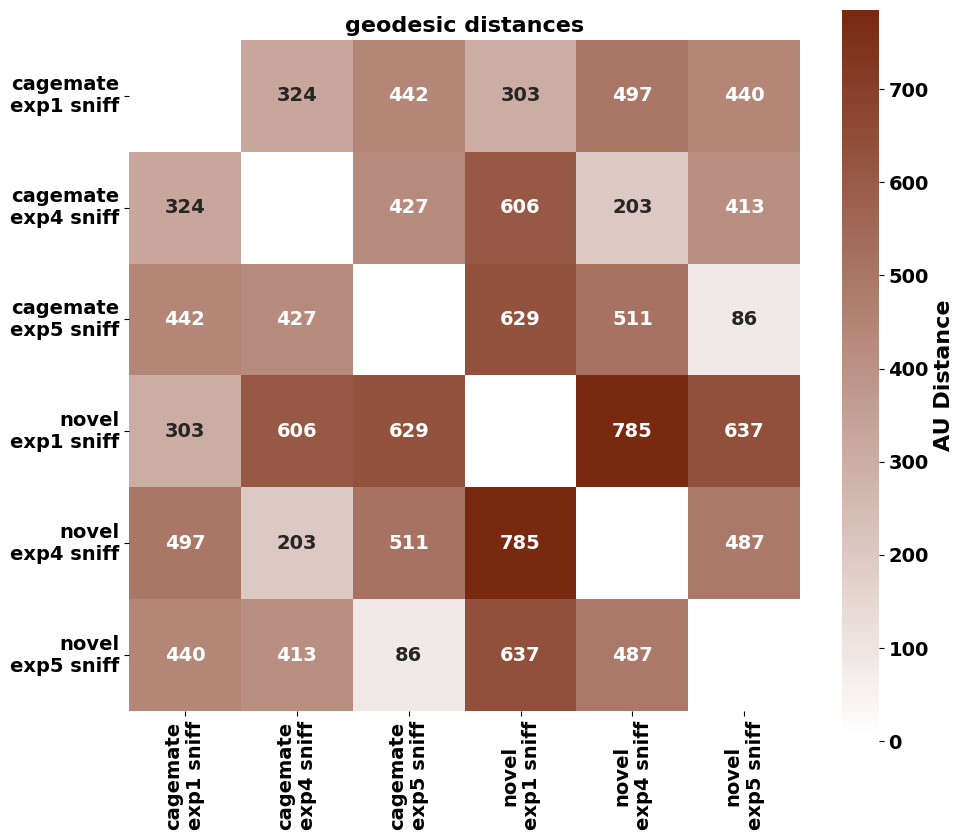

In [189]:
exp_filter = ['exp1', 'exp4', 'exp5']
mask = pairwise_distances.index.str.contains('|'.join(exp_filter))

# Apply mask to both rows and columns
filtered_df = pairwise_distances.loc[mask, mask]
#trimmed_pairwise = pairwise_distances[pairwise_distances[]]
filtered_df
plot_comparison_heatmap(filtered_df, title = 'geodesic distances', color = ['white', '#792910'], diagonal_color='white', vmin = 0)

<module 'matplotlib.pyplot' from 'c:\\Users\\megha\\anaconda3\\envs\\ephys_env\\lib\\site-packages\\matplotlib\\pyplot.py'>

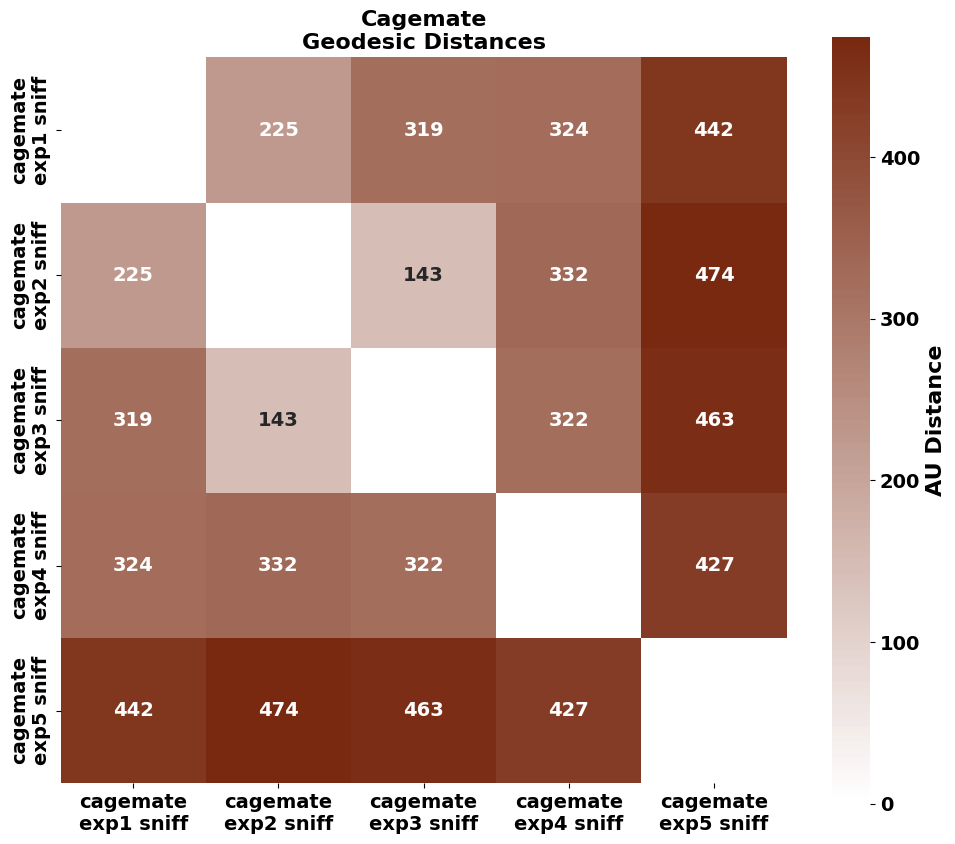

In [190]:
exp_filter = 'cagemate'
cage_mask = pairwise_distances.index.str.contains(exp_filter)

# Apply mask to both rows and columns
cagemate_df = pairwise_distances.loc[cage_mask, cage_mask]
plot_comparison_heatmap(cagemate_df, title = 'Cagemate\nGeodesic Distances', color = ['white', '#792910'], diagonal_color='white', vmin = 0)

<module 'matplotlib.pyplot' from 'c:\\Users\\megha\\anaconda3\\envs\\ephys_env\\lib\\site-packages\\matplotlib\\pyplot.py'>

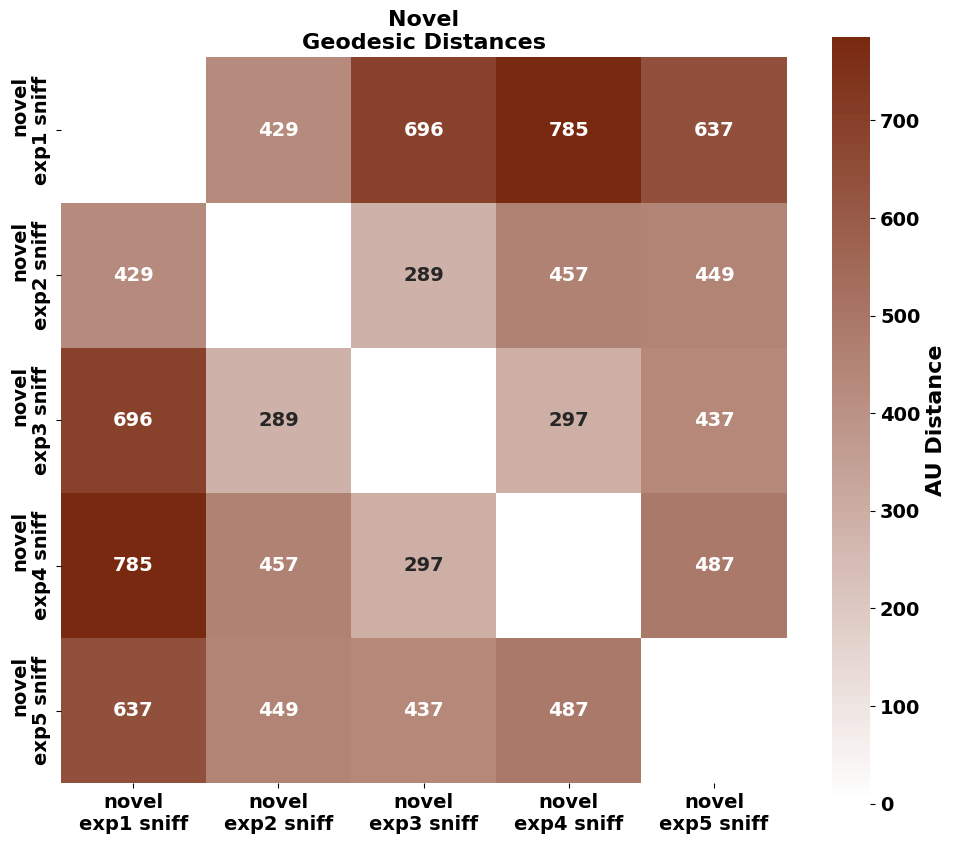

In [191]:
exp_filter = 'novel'
novel_mask = pairwise_distances.index.str.contains(exp_filter)

# Apply mask to both rows and columns
novel_df = pairwise_distances.loc[novel_mask, novel_mask]
plot_comparison_heatmap(novel_df, title = 'Novel\nGeodesic Distances', color = ['white', '#792910'], diagonal_color='white', vmin = 0)

,novel\nexp1 sniff,novel\nexp2 sniff,novel\nexp3 sniff,novel\nexp4 sniff,novel\nexp5 sniff
cagemate\nexp1 sniff,303.157977,188.556393,416.390918,496.651457,439.953392
cagemate\nexp2 sniff,473.808457,85.829837,252.470291,437.188644,453.852629
cagemate\nexp3 sniff,584.543197,178.975696,141.861905,375.707074,436.502699
cagemate\nexp4 sniff,605.98661,338.652167,311.320126,202.952203,412.964327
cagemate\nexp5 sniff,629.063562,466.455216,471.394203,511.45358,85.834069


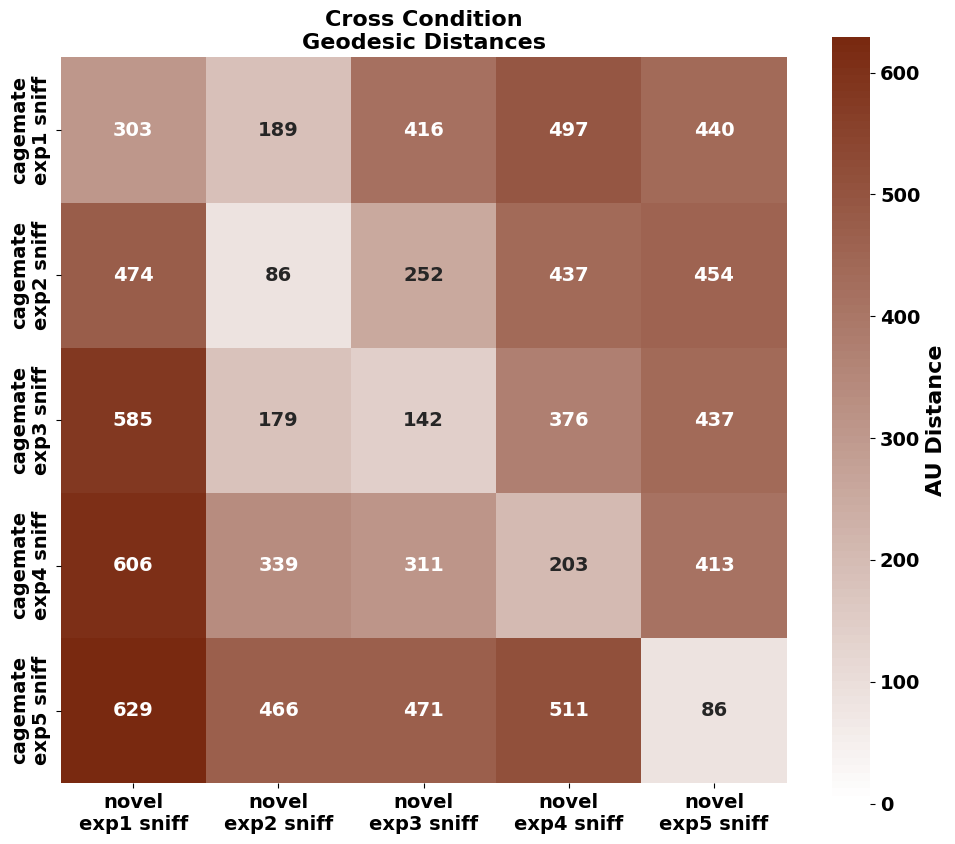

In [192]:


# Apply mask to both rows and columns
cross_df = pairwise_distances.loc[cage_mask, novel_mask]

plot_comparison_heatmap(cross_df, title = 'Cross Condition\nGeodesic Distances', color = ['white', '#792910'], diagonal_color=None, vmin = 0)
cross_df

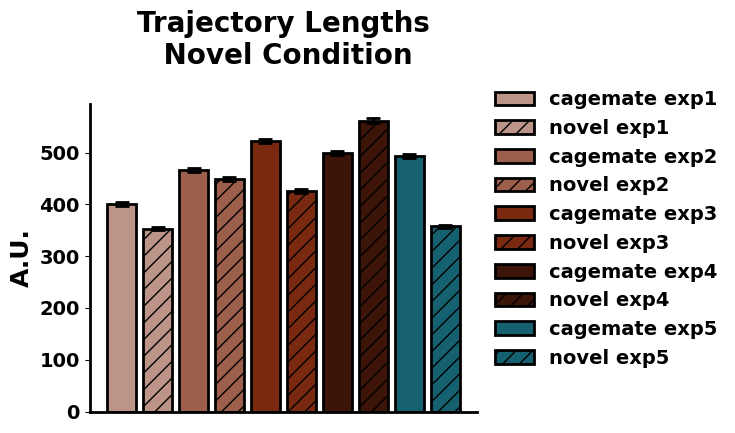

,Comparison,t_statistic,p_value,p_adjusted,significant
0,exp1,9.171809,1.326181e-08,3.978543e-08,True
1,exp2,2.742809,1.254314e-02,1.254314e-02,True
2,exp3,15.600228,1.164727e-12,4.658908e-12,True
3,exp4,-8.419824,5.242286e-08,1.048457e-07,True
4,exp5,23.207652,6.201752e-16,3.100876e-15,True


In [194]:
means = np.mean(trajectory_lengths, axis = 0)
sems = sem(trajectory_lengths, axis = 0)
means_for_plotting = means[[0,5,1,6,2,7,3,8,4,9]]
sems_for_plotting = sems[[0,5,1,6,2,7,3,8,4,9]]

t_exp1, p_exp1 = stats.ttest_rel(trajectory_lengths[:,0], trajectory_lengths[:,5])
t_exp4, p_exp4 = stats.ttest_rel(trajectory_lengths[:,3], trajectory_lengths[:,8])
t_exp5, p_exp5 = stats.ttest_rel(trajectory_lengths[:,4], trajectory_lengths[:,9])
t_exp2, p_exp2 = stats.ttest_rel(trajectory_lengths[:,1], trajectory_lengths[:,6])
t_exp3, p_exp3 = stats.ttest_rel(trajectory_lengths[:,2], trajectory_lengths[:,7])
p_values = [p_exp1, p_exp2, p_exp3, p_exp4, p_exp5]
reject, p_adjusted, _, _ = multipletests(p_values, method='holm')
stats_df = pd.DataFrame({
   'Comparison': ['exp1', 'exp2', 'exp3', 'exp4', 'exp5'],
   't_statistic': [t_exp1, t_exp2, t_exp3, t_exp4, t_exp5],
   'p_value': p_values,
   'p_adjusted': p_adjusted,
   'significant': reject
})

#Adjust p-values using Holm-Bonferroni

color_id_dict = {'cagemate exp1': hex_2_rgb('#bc9488'), 
                 'novel exp1': hex_2_rgb('#bc9488'), 
                 'cagemate exp2' :hex_2_rgb('#9b5f4c'),
                 'novel exp2' :hex_2_rgb('#9b5f4c'),
                 'cagemate exp3': hex_2_rgb('#792910'),
                 'novel exp3': hex_2_rgb('#792910'),
                'cagemate exp4': hex_2_rgb('#3c1508'),
                 'novel exp4': hex_2_rgb('#3c1508'),
                  'cagemate exp5':  hex_2_rgb('#15616F'),
                  'novel exp5':  hex_2_rgb('#15616F')}
  # Ensures bars don't overlap but aren't too thin
                                # Max width of 0.4 (your original), gets smaller with more bars

# Create evenly spaced x positions based on the number of data points
x = np.arange(len(means_for_plotting))
width = 8 / len(x)
hatches = ['','//']*5
plt.figure(figsize= (.5*len(x),4))           
plt.bar(x, means_for_plotting, yerr = sems_for_plotting,
            color = color_id_dict.values(),
            edgecolor = 'black',
            hatch = hatches,
            capsize = 5, linewidth = 2,
            error_kw={'elinewidth': 2, 'capthick': 2}, 
            width = width)
plt.xticks([],rotation=45)
legend_handles = [Patch(facecolor=color, label=label, hatch=hatch) 
                 for (label, color), hatch in zip(color_id_dict.items(), hatches)]
plt.legend(handles=legend_handles,
           bbox_to_anchor=(1,1.1),
           frameon= False, fontsize = 14)
plt.ylabel('A.U.', fontsize = 18)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(100))
#plt.ylim(100,300)
plt.gca().spines['bottom'].set_linewidth(2)  # X-axis
plt.gca().spines['left'].set_linewidth(2) 
plt.title('Trajectory Lengths\n Novel Condition', fontsize = 20, y = 1.1)
plt.show()

stats_df

In [ ]:
condition_dict

In [234]:
from importlib import reload
import spike.spike_analysis.decoders as decoders
reload(population_analysis)
reload(decoders)
events = ['exp1 sniff', 'exp4 sniff', 'exp5 sniff']
#events = ['novel', 'not_novel']
event_length=5
pre_window = 5
post_window=0
min_neurons=5
plot= True
num_fold = 2

decoder_data, num_pcs = decoders.trial_PCA(whole_collection,
                                     events = events,
                                     event_length=event_length,
                                     pre_window=pre_window,
                                     post_window=post_window,
                                     min_neurons= min_neurons,
                                     condition_dict=condition_dict)

decoder_data.keys()


keys_wanted = ['cagemate exp1 sniff', 'novel exp1 sniff']
exp1_data = {k: decoder_data[k] for k in keys_wanted}

exp1_results = decoders.trial_decoder(whole_collection,
                                      num_fold = 5,
                                     events = keys_wanted,
                                     event_length=event_length,
                                     pre_window=pre_window,
                                     post_window=post_window,
                                     min_neurons= min_neurons, 
                                     decoder_data = exp1_data,
                                     classifier_type='linear')

Excluding 31_cage_p1_merged.rec with 1 neurons
Excluding 33_cage_p1_merged.rec with 2 neurons
Excluding 33_nov_p1_merged.rec with 1 neurons


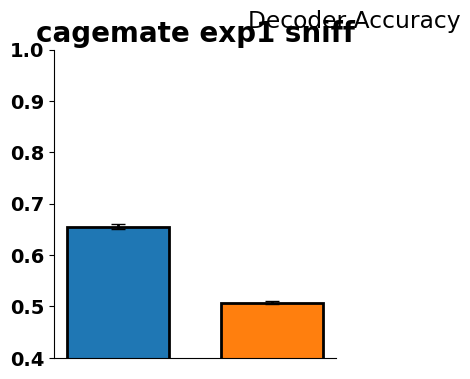

In [235]:
exp1_results.plot_average()

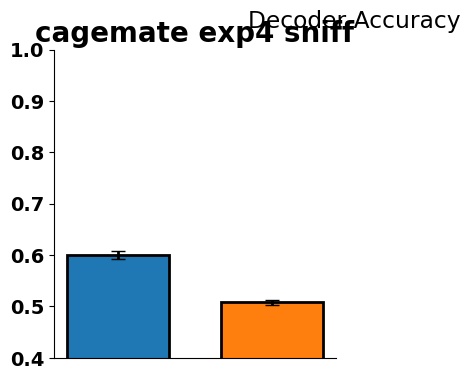

In [237]:
keys_wanted = ['cagemate exp4 sniff', 'novel exp4 sniff']
exp4_data = {k: decoder_data[k] for k in keys_wanted}

exp4_results = decoders.trial_decoder(whole_collection,
                                      num_fold = 5,
                                     events = keys_wanted,
                                     event_length=event_length,
                                     pre_window=pre_window,
                                     post_window=post_window,
                                     min_neurons= min_neurons, 
                                     decoder_data = exp4_data,
                                     classifier_type='linear')
exp4_results.plot_average()

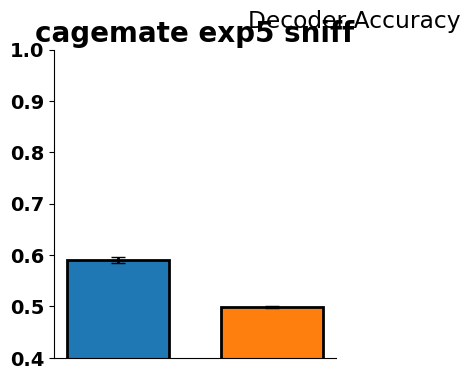

In [238]:
keys_wanted = ['cagemate exp5 sniff', 'novel exp5 sniff']
exp5_data = {k: decoder_data[k] for k in keys_wanted}

exp5_results = decoders.trial_decoder(whole_collection,
                                      num_fold = 5,
                                     events = keys_wanted,
                                     event_length=event_length,
                                     pre_window=pre_window,
                                     post_window=post_window,
                                     min_neurons= min_neurons, 
                                     decoder_data = exp5_data,
                                     classifier_type='linear')
exp5_results.plot_average()